# 🏬 **Sales Forecasting Across Multiple Retail Stores**

### *An End-to-End Forecasting Pipeline for Rossmann Pharmaceuticals' Retail Network*

---

**Author**  : Yousuf S. R. Sakkaf

**Status**  : Completed

**Dataset** : train.csv, test.csv, store.csv

**File**    : 01_salesfc_preprocessing.ipynb

**Project** : NHIS_Project6

**Date**    : 17th August 2026

---

## 📌 Introduction

<div style="margin-left: 20px; max-width: 90%">

Rossmann Pharmaceuticals operates retail stores across several cities, and its finance team currently relies on individual store managers' experience and personal judgement to forecast sales — a process with no consistent, data-driven basis. This project builds an end-to-end sales forecasting pipeline that predicts daily sales up to six weeks in advance, using factors such as promotions, competition, holidays, seasonality, and store characteristics.

</div>

## ❓ Problem Statement

<div style="margin-left: 20px; max-width: 90%">

Forecasting retail sales accurately requires understanding how a wide range of factors — promotions, holidays, competition proximity, assortment type, and seasonal patterns — interact to influence daily store performance. Without a systematic model, forecasts remain inconsistent across stores and vulnerable to individual bias.

</div>

## 🎯 Objectives

<div style="margin-left: 20px; max-width: 90%">

- Merge `store` metadata with `train` and `test` datasets to form `store_train_data` and `store_test_data`.
- Clean both datasets — handling missing values, duplicates, and outliers appropriately for each variable's role.
- Engineer date-derived and business-relevant features, then encode and scale both datasets.
- Conduct **Task 1: Exploratory Data Analysis** on customer purchasing behavior — promos, holidays, seasonality, assortment, and competition effects on sales.

</div>

## 🎯 Expected Outcomes

<div style="margin-left: 20px; max-width: 90%">

Upon completion of this notebook, we expect to:

- Have two fully cleaned, feature-engineered, encoded, and scaled datasets (`store_train_data`, `store_test_data`) ready for modeling.
- Understand which factors most strongly influence store sales and customer behavior.
- Surface actionable insights on promo effectiveness, holiday patterns, and competition impact.
- Hand off a modeling-ready dataset to Notebooks 2 (ML Modeling), 3 (Deep Learning), and 4 (Time Series).

</div>

## 🛠 Environment Setup

### 📚 Import Required Libraries

<div style="margin-left: 20px; max-width: 90%">

This section imports all libraries required throughout this notebook, along with the shared `prerequisites` module (logging, HTML theme, data loading, and generic audit/statistical utilities used across all 4 notebooks in this project).

</div>

In [1]:
import os, urllib.request
if not os.path.exists("prerequisites.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/S-Yousuf-S/NHIS_Project6/main/prerequisites.py",
        "prerequisites.py"
    )

In [2]:
from prerequisites import *
import warnings
warnings.filterwarnings("ignore", message=".*force_all_finite.*", category=FutureWarning)
logger = setup_logging(notebook_name="01_salesfc_preprocessing")

success_box("All libraries imported successfully.")

2026-09-08 17:09:23 - 01_salesfc_preprocessing - INFO - Logging session started for '01_salesfc_preprocessing' -> Logs\YS_01_salesfc_preprocessing_20260908.log


### 🎨 Configure Notebook & Visualization Settings

<div style="margin-left: 20px; max-width: 90%">

Global display settings, plot aesthetics, and the HTML theme are configured before beginning the analysis, ensuring consistency across all sections and matching the styling used in Notebooks 2–4.

</div>

In [3]:
set_global_visualization_settings(palette="viridis")
success_box("HTML Theme initiated and ready.")

✅ Global visualization settings are ready.


## 01. Importing and Inspecting the Data
### 📌 Dataset Loading

<div style="margin-left: 20px; max-width: 90%">

Before any cleaning or merging can happen, we need the three raw files this project depends on: `train.csv` (historical daily sales), `test.csv` (the prediction target set), and `store.csv` (store-level metadata). Each is loaded via the shared `load_data_file()` cascade — Local → Google Drive → GitHub — using whichever source is available first.

</div>

In [4]:
# Attempt Drive Mount (non-blocking if declined or unavailable)
drive_available = attempt_drive_mount()

In [5]:
section_header("Importing & Inspecting the Data")

GITHUB_RAW_BASE = "https://raw.githubusercontent.com/S-Yousuf-S/NHIS_Project6/main/Assets"
DRIVE_BASE = "/content/drive/MyDrive/NHIS_Project/Project 6/Assets"

train = load_data_file("train.csv", drive_path=f"{DRIVE_BASE}/train.csv",
                        github_raw_base=GITHUB_RAW_BASE, logger=logger)
test = load_data_file("test.csv", drive_path=f"{DRIVE_BASE}/test.csv",
                       github_raw_base=GITHUB_RAW_BASE, logger=logger)
store = load_data_file("store.csv", drive_path=f"{DRIVE_BASE}/store.csv",
                        github_raw_base=GITHUB_RAW_BASE, logger=logger)


2026-09-08 17:09:23 - 01_salesfc_preprocessing - INFO - Loaded 'train.csv' from local Assets/ folder.


2026-09-08 17:09:24 - 01_salesfc_preprocessing - INFO - Loaded 'test.csv' from local Assets/ folder.


2026-09-08 17:09:24 - 01_salesfc_preprocessing - INFO - Loaded 'store.csv' from local Assets/ folder.


### 🔍 Basic Inspection

<div style="margin-left: 20px; max-width: 90%">

Before merging, each raw dataset is inspected individually — data types, sample rows, and summary statistics — to catch any obvious issues (unexpected types, unusual ranges) while the three files are still separate and easy to isolate.

</div>

In [6]:
subsection_header("Basic Inspection: train (raw)")
print("="*45)
print("DETAILED INFO")
print("="*45)
train.info()
info_box(f"Dataset <b>train:</b> {train.shape[0]:,} rows, {train.shape[1]} columns<br>")

DETAILED INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [7]:
subsection_header("Basic Inspection: test (raw)")
print("="*45)
print("DETAILED INFO")
print("="*45)
test.info()
info_box(f"Dataset <b>test:</b> {test.shape[0]:,} rows, {test.shape[1]} columns<br>")

DETAILED INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  object 
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  object 
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 2.5+ MB


In [8]:
subsection_header("Basic Inspection: store (raw)")
print("="*45)
print("DETAILED INFO")
print("="*45)
store.info()
info_box(f"Dataset <b>store:</b> {store.shape[0]:,} rows, {store.shape[1]} columns")

DETAILED INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Basic Inspection (train, test, store):**

- **train** (1,017,209 rows × 9 cols): No missing values anywhere. Two `object`-typed columns need conversion during cleaning — `Date` (string → datetime) and `StateHoliday` (mixed codes `0/a/b/c` → proper categorical).
- **test** (41,088 rows × 8 cols): Same two columns need type conversion (`Date`, `StateHoliday`). `Open` has 11 missing values (41,077 of 41,088 non-null) — needs a treatment decision during cleaning. `Sales`/`Customers` are absent as expected, since these are the prediction targets.
- **store** (1,115 rows × 10 cols): Three `object`-typed columns (`StoreType`, `Assortment`, `PromoInterval`). Missing values appear structurally explainable rather than random — `CompetitionOpenSinceMonth`/`Year` missing in 354 rows each (competitor open date simply unknown), and `Promo2SinceWeek`/`Year`/`PromoInterval` missing in 544 rows each, which likely lines up exactly with stores where `Promo2 == 0` — to be verified explicitly during cleaning, since a structural "not applicable" NaN should be treated differently from a genuinely unknown value.
- All three datasets are otherwise structurally sound — correct row counts, no unexpected columns, ready for merging.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 02. Merging Store Metadata

<div style="margin-left: 20px; max-width: 90%">

`store.csv` holds per-store metadata (StoreType, Assortment, CompetitionDistance, Promo2 details) that isn't present in `train.csv`/`test.csv` on their own. Both are merged with `store` on the shared `Store` key to form `store_train_data` and `store_test_data` — the two datasets all subsequent cleaning, feature engineering, and modeling will build on.

</div>

In [9]:
section_header("Merging Store Metadata")
subsection_header("Pre-Merge Check: Store ID Coverage")

train_only_stores = set(train["Store"]) - set(store["Store"])
test_only_stores = set(test["Store"]) - set(store["Store"])

if not train_only_stores and not test_only_stores:
    success_box("All Store IDs in train and test exist in store.csv — safe to merge.")
else:
    warning_box(f"Store IDs missing from store.csv — train: {train_only_stores}, test: {test_only_stores}")

logger.info(f"Pre-merge check — train orphan stores: {len(train_only_stores)}, "
            f"test orphan stores: {len(test_only_stores)}")

2026-09-08 17:09:24 - 01_salesfc_preprocessing - INFO - Pre-merge check — train orphan stores: 0, test orphan stores: 0


In [10]:
subsection_header("Merging store with train and test")

store_train_data = pd.merge(train, store, on="Store", how="left")
store_test_data = pd.merge(test, store, on="Store", how="left")

success_box(f"'<b>store_train_data</b>' created: {store_train_data.shape[0]:,} rows, {store_train_data.shape[1]} columns")
success_box(f"'<b>store_test_data</b>' created: {store_test_data.shape[0]:,} rows, {store_test_data.shape[1]} columns")

logger.info(f"Merged store_train_data: {store_train_data.shape}")
logger.info(f"Merged store_test_data: {store_test_data.shape}")

2026-09-08 17:09:25 - 01_salesfc_preprocessing - INFO - Merged store_train_data: (1017209, 18)
2026-09-08 17:09:25 - 01_salesfc_preprocessing - INFO - Merged store_test_data: (41088, 17)


In [11]:
subsection_header("Preview: store_train_data")
centered_table(store_train_data.head())

Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.00,9.00,2008.00,0,NaN,NaN,NaN
2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.00,11.00,2007.00,1,13.00,2010.00,"Jan,Apr,Jul,Oct"
3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.00,12.00,2006.00,1,14.00,2011.00,"Jan,Apr,Jul,Oct"
4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.00,9.00,2009.00,0,NaN,NaN,NaN
5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.00,4.00,2015.00,0,NaN,NaN,NaN


In [12]:
subsection_header("Preview: store_test_data")
centered_table(store_test_data.head())

Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1,1,4,2015-09-17,1.00,1,0,0,c,a,1270.00,9.00,2008.00,0,NaN,NaN,NaN
2,3,4,2015-09-17,1.00,1,0,0,a,a,14130.00,12.00,2006.00,1,14.00,2011.00,"Jan,Apr,Jul,Oct"
3,7,4,2015-09-17,1.00,1,0,0,a,c,24000.00,4.00,2013.00,0,NaN,NaN,NaN
4,8,4,2015-09-17,1.00,1,0,0,a,a,7520.00,10.00,2014.00,0,NaN,NaN,NaN
5,9,4,2015-09-17,1.00,1,0,0,a,c,2030.00,8.00,2000.00,0,NaN,NaN,NaN


In [13]:
subsection_header("Store Coverage: Train vs. Test")

train_stores = store_train_data["Store"].nunique()
test_stores = store_test_data["Store"].nunique()

info_box(f"Unique stores in train: <b>{train_stores}</b><br>"
         f"Unique stores in test: <b>{test_stores}</b><br>"
         f"Stores in train but NOT in test: <b>{len(set(store_train_data['Store']) - set(store_test_data['Store']))}</b>")

<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Merging Store Metadata:**

- Pre-merge check confirmed every `Store` ID in both `train` and `test` exists in `store.csv` — no orphan stores, safe to merge with zero risk of introducing unexpected `NaN`s from a missing key.
- **`store_train_data` (1,017,209 rows × 18 cols)** and **`store_test_data` (41,088 rows × 17 cols)** confirm the merge enriched every row with store metadata without altering row counts — a pure left-join enrichment, not a filter.
- Preview rows confirm the join populated correctly: `StoreType`, `Assortment`, `CompetitionDistance`, and `Promo2` fields all appear attached to the correct store per row.
- `Id` (test only) is a simple sequential row identifier from the original file — unrelated to `Store`, and not something to confuse with the actual store number.
- **Store coverage differs meaningfully between the two sets**: `train` covers all 1,115 stores, while `test` covers only 856 — **259 stores present in train are entirely absent from test**. This means the model will need to generalize to stores it's never asked to predict for at evaluation time, and any store-specific patterns unique to those 259 excluded stores won't be directly validated against test performance.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 03. Data Cleaning & Preprocessing

<div style="margin-left: 20px; max-width: 90%">

With both datasets merged, cleaning begins with type correction — 

`Date` is currently stored as text and needs conversion to a proper datetime type before any date-based feature engineering can happen later. 

`StateHoliday` also needs standardizing, since the raw CSV mixes numeric-looking `0` with string holiday codes (`a`, `b`, `c`), which triggered a mixed-type warning during loading. 

Several identifier and binary-flag columns (`Store`, `DayOfWeek`, `Open`, `Promo`, `StateHoliday`, `SchoolHoliday`, `Promo2`, `StoreType`, `Assortment`) are also converted to `category` type — these represent discrete groupings, not quantities to be averaged or summed, so `category` is the more accurate and memory-efficient representation.

</div>

In [14]:
section_header("Data Cleaning & Preprocessing")
subsection_header("Data Type Correction")

dtypes_before = store_train_data.dtypes.astype(str).rename("Dtype (Before)")

def correct_dtypes(df,dataset_name="dataset"):
    df["Date"] = pd.to_datetime(df["Date"])
    logger.debug(f"[{dataset_name}] Date converted to datetime64[ns]")
    
    df["StateHoliday"] = df["StateHoliday"].astype(str)
    logger.debug(f"[{dataset_name}] StateHoliday standardized to string")

    category_cols = ["Store", "DayOfWeek", "Open", "Promo","StateHoliday", "SchoolHoliday", "Promo2","StoreType", "Assortment"]
    for col in category_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")
            logger.debug(f"[{dataset_name}] '{col}' converted to category")
    return df

store_train_data = correct_dtypes(store_train_data, dataset_name="store_train_data")
store_test_data = correct_dtypes(store_test_data, dataset_name="store_test_data")

dtypes_after = store_train_data.dtypes.astype(str).rename("Dtype (After)")
dtype_comparison = pd.concat([dtypes_before, dtypes_after], axis=1).reset_index().rename(columns={"index": "Column"})
dtype_changed = dtype_comparison[dtype_comparison["Dtype (Before)"] != dtype_comparison["Dtype (After)"]]

success_box("Date corrected to datetime;<br>StateHoliday standardized;<br>9 columns converted to category — applied to both datasets.")
centered_table(dtype_changed)

info_box("Comparison reflects store_train_data.<br>Identical columns and dtype changes were applied to `store_test_data` using the same correct_dtypes() function.")
logger.info(f"store_train_data dtypes after correction:\n{store_train_data.dtypes}")
logger.info(f"store_test_data dtypes after correction:\n{store_test_data.dtypes}")

2026-09-08 17:09:25 - 01_salesfc_preprocessing - DEBUG - [store_train_data] Date converted to datetime64[ns]
2026-09-08 17:09:25 - 01_salesfc_preprocessing - DEBUG - [store_train_data] StateHoliday standardized to string
2026-09-08 17:09:26 - 01_salesfc_preprocessing - DEBUG - [store_train_data] 'Store' converted to category
2026-09-08 17:09:26 - 01_salesfc_preprocessing - DEBUG - [store_train_data] 'DayOfWeek' converted to category
2026-09-08 17:09:26 - 01_salesfc_preprocessing - DEBUG - [store_train_data] 'Open' converted to category
2026-09-08 17:09:26 - 01_salesfc_preprocessing - DEBUG - [store_train_data] 'Promo' converted to category
2026-09-08 17:09:26 - 01_salesfc_preprocessing - DEBUG - [store_train_data] 'StateHoliday' converted to category
2026-09-08 17:09:26 - 01_salesfc_preprocessing - DEBUG - [store_train_data] 'SchoolHoliday' converted to category
2026-09-08 17:09:26 - 01_salesfc_preprocessing - DEBUG - [store_train_data] 'Promo2' converted to category
2026-09-08 17:09:2

Column,Dtype (Before),Dtype (After)
Store,int64,category
DayOfWeek,int64,category
Date,object,datetime64[ns]
Open,int64,category
Promo,int64,category
StateHoliday,object,category
SchoolHoliday,int64,category
StoreType,object,category
Assortment,object,category
Promo2,int64,category


2026-09-08 17:09:26 - 01_salesfc_preprocessing - INFO - store_train_data dtypes after correction:
Store                              category
DayOfWeek                          category
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                               category
Promo                              category
StateHoliday                       category
SchoolHoliday                      category
StoreType                          category
Assortment                         category
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                             category
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object
2026-09-08 17:09:26 - 01_salesfc_preprocessing - INFO - store_test_data dtypes after correction:

### 📌 Duplicate Check

<div style="margin-left: 20px; max-width: 90%">

Both datasets are checked for exact duplicate rows. Since `train`/`test` don't have a single unique identifier column, this is a two-part check: full-row duplicates, and — more importantly for this kind of panel data — duplicate `(Store, Date)` combinations, since each store should have exactly one record per day.

</div>

In [15]:
subsection_header("Duplicate Check")

full_dup_train = store_train_data.duplicated().sum()
full_dup_test = store_test_data.duplicated().sum()

storedate_dup_train = store_train_data.duplicated(subset=["Store", "Date"]).sum()
storedate_dup_test = store_test_data.duplicated(subset=["Store", "Date"]).sum()

duplicate_summary = pd.DataFrame({
    "Dataset": ["store_train_data", "store_test_data"],
    "Full-Row Duplicates": [full_dup_train, full_dup_test],
    "Duplicate (Store, Date) Pairs": [storedate_dup_train, storedate_dup_test]
})

centered_table(duplicate_summary)

if duplicate_summary[["Full-Row Duplicates", "Duplicate (Store, Date) Pairs"]].sum().sum() == 0:
    success_box("No duplicate rows or duplicate (Store, Date) pairs found in either dataset.")
else:
    warning_box("Duplicates detected — review before proceeding.")

logger.info(f"Duplicate check — train: full={full_dup_train}, store-date={storedate_dup_train} | "
            f"test: full={full_dup_test}, store-date={storedate_dup_test}")

Dataset,Full-Row Duplicates,"Duplicate (Store, Date) Pairs"
store_train_data,0,0
store_test_data,0,0


2026-09-08 17:09:27 - 01_salesfc_preprocessing - INFO - Duplicate check — train: full=0, store-date=0 | test: full=0, store-date=0


### 📌 Missing Value Audit

<div style="margin-left: 20px; max-width: 90%">

Before deciding how to treat missing values, both datasets are audited to see exactly which columns are affected and by how much. This audit is descriptive only — no values are changed here; treatment decisions come next, once the full picture is visible.

</div>

In [16]:
subsection_header("Missing Value Audit: store_train_data")
train_missing = missing_value_audit(store_train_data, dataset_name="store_train_data", logger=logger)
centered_table(train_missing)

2026-09-08 17:09:28 - 01_salesfc_preprocessing - INFO - [store_train_data] Missing value audit: 6 column(s) with missing values.


Column,Missing Count,Missing %
Promo2SinceYear,508031,49.94
Promo2SinceWeek,508031,49.94
PromoInterval,508031,49.94
CompetitionOpenSinceMonth,323348,31.79
CompetitionOpenSinceYear,323348,31.79
CompetitionDistance,2642,0.26


In [17]:

subsection_header("Missing Value Audit: store_test_data")
test_missing = missing_value_audit(store_test_data, dataset_name="store_test_data", logger=logger)
centered_table(test_missing)

2026-09-08 17:09:28 - 01_salesfc_preprocessing - INFO - [store_test_data] Missing value audit: 7 column(s) with missing values.


Column,Missing Count,Missing %
PromoInterval,17232,41.94
Promo2SinceYear,17232,41.94
Promo2SinceWeek,17232,41.94
CompetitionOpenSinceMonth,15216,37.03
CompetitionOpenSinceYear,15216,37.03
CompetitionDistance,96,0.23
Open,11,0.03


### 📌 Verifying Missingness Patterns

<div style="margin-left: 20px; max-width: 90%">

Before deciding treatment, several missing-value patterns are investigated directly rather than assumed — confirming whether Promo2-related gaps are structural, understanding the single store missing `Open` values, and checking the distribution of known competition/Promo2 years to inform how those columns should eventually be filled.

</div>

In [18]:
subsection_header("Verifying Promo2 Missingness Pattern")

promo2_check = store_train_data.groupby("Promo2", observed=True)[["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]].apply(lambda x: x.isnull().sum())

centered_table(promo2_check.reset_index())

Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,508031,508031,508031
1,0,0,0


In [19]:
subsection_header("Verifying Missing Open Pattern")

missing_open_rows = store_test_data[store_test_data["Open"].isnull()]
centered_table(missing_open_rows[["Store", "DayOfWeek", "Date", "Promo", "StateHoliday", "SchoolHoliday"]])

Store,DayOfWeek,Date,Promo,StateHoliday,SchoolHoliday
622,4,2015-09-17,1,0,0
622,3,2015-09-16,1,0,0
622,2,2015-09-15,1,0,0
622,1,2015-09-14,1,0,0
622,6,2015-09-12,0,0,0
622,5,2015-09-11,0,0,0
622,4,2015-09-10,0,0,0
622,3,2015-09-09,0,0,0
622,2,2015-09-08,0,0,0
622,1,2015-09-07,0,0,0


In [20]:
subsection_header("Investigating Store 622's Historical Open Pattern")

store_622_history = store_train_data[store_train_data["Store"] == 622].sort_values("Date")
recent_622 = store_622_history.tail(20)[["Date", "DayOfWeek", "Open", "Promo", "Sales"]]

centered_table(recent_622)

open_rate_622 = store_622_history["Open"].astype(int).mean()
info_box(f"Store 622 historical Open rate (all of train): {open_rate_622:.2%}")

logger.debug(f"Store 622 historical Open rate: {open_rate_622:.4f}")

Date,DayOfWeek,Open,Promo,Sales
2015-07-12,7,0,0,0
2015-07-13,1,1,1,6349
2015-07-14,2,1,1,5102
2015-07-15,3,1,1,4718
2015-07-16,4,1,1,5615
2015-07-17,5,1,1,5263
2015-07-18,6,1,0,2367
2015-07-19,7,0,0,0
2015-07-20,1,1,0,4688
2015-07-21,2,1,0,3529


2026-09-08 17:09:28 - 01_salesfc_preprocessing - DEBUG - Store 622 historical Open rate: 0.8323


In [21]:
subsection_header("Frequency Distribution: Competition & Promo2 Year Columns")

for col in ["CompetitionOpenSinceYear", "Promo2SinceYear"]:
    freq = store_train_data[col].dropna().astype(int).value_counts().sort_index().reset_index()
    freq.columns = [col, "Count"]
    centered_table(freq)
    logger.debug(f"{col} frequency distribution computed — {freq.shape[0]} distinct years")

info_box("CompetitionOpenSinceYear spans 1900-2015, heavily concentrated 2005 onward. "
         "Promo2SinceYear spans 2009-2015 (Promo2 didn't exist before then), fairly evenly spread.")

CompetitionOpenSinceYear,Count
1900,758
1961,942
1990,4710
1994,1884
1995,1700
1998,942
1999,7352
2000,9236
2001,14704
2002,24882


2026-09-08 17:09:29 - 01_salesfc_preprocessing - DEBUG - CompetitionOpenSinceYear frequency distribution computed — 23 distinct years


Promo2SinceYear,Count
2009,65270
2010,56240
2011,115056
2012,73174
2013,110464
2014,79922
2015,9052


2026-09-08 17:09:29 - 01_salesfc_preprocessing - DEBUG - Promo2SinceYear frequency distribution computed — 7 distinct years


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Data Type Correction, Duplicate Check, Missing Value Audit & Verification:**

- `Date` corrected to datetime; `StateHoliday` standardized; 9 identifier/flag columns converted to `category` — applied identically to both datasets.
- No duplicate rows or duplicate `(Store, Date)` pairs found in either dataset.
- Missing values cluster in two logical groups: Promo2-related fields and competition-related fields, both explored further below rather than assumed.
- Promo2 missingness confirmed structural: 100% alignment with `Promo2 == 0`, zero missing where `Promo2 == 1`.
- `Open`'s 11 missing values all belong to a single store (Store 622) — its historical Open rate is examined above to inform treatment.
- Frequency distributions for `CompetitionOpenSinceYear` and `Promo2SinceYear` are captured above, pending final fill-strategy confirmation.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Missing Value Treatment

<div style="margin-left: 20px; max-width: 90%">

`Promo2SinceWeek`/`Year` and `CompetitionOpenSinceMonth`/`Year` are resolved by converting them into continuous duration features rather than filling the raw calendar values directly, since averaging or estimating a raw month or year produces a statistically meaningless result. `CompetitionDistance`, `PromoInterval`, and `Open` are filled directly, using medians computed from `store_train_data` only to avoid leaking test-set information into the treatment.

</div>

In [22]:
subsection_header("Missing Value Treatment")

before_missing = missing_value_audit(store_train_data, dataset_name="store_train_data")

def resolve_promo2_duration(df):
    promo2_date = pd.to_datetime(
        df["Promo2SinceYear"].astype("Int64").astype(str) + "-" +
        df["Promo2SinceWeek"].astype("Int64").astype(str) + "-1",
        format="%Y-%W-%w", errors="coerce"
    )
    df["Promo2_Duration_Weeks"] = ((df["Date"] - promo2_date).dt.days / 7).clip(lower=0)
    df["Promo2_Duration_Weeks"] = df["Promo2_Duration_Weeks"].fillna(0)
    return df

store_train_data = resolve_promo2_duration(store_train_data)
store_test_data = resolve_promo2_duration(store_test_data)

success_box("Promo2_Duration_Weeks derived for both datasets — Promo2==0 rows correctly filled "
            "with a true duration of 0, no estimation needed.")
logger.debug("Promo2_Duration_Weeks derived — no fill statistic needed (Promo2==1 rows always complete).")

2026-09-08 17:09:32 - 01_salesfc_preprocessing - DEBUG - Promo2_Duration_Weeks derived — no fill statistic needed (Promo2==1 rows always complete).


In [23]:
comp_date_train = pd.to_datetime(
    store_train_data["CompetitionOpenSinceYear"].astype("Int64").astype(str) + "-" +
    store_train_data["CompetitionOpenSinceMonth"].astype("Int64").astype(str) + "-1",
    format="%Y-%m-%d", errors="coerce"
)
train_duration = ((store_train_data["Date"] - comp_date_train).dt.days / 30.44).clip(lower=0)
competition_duration_median = train_duration.median()

def resolve_competition_duration(df):
    comp_date = pd.to_datetime(
        df["CompetitionOpenSinceYear"].astype("Int64").astype(str) + "-" +
        df["CompetitionOpenSinceMonth"].astype("Int64").astype(str) + "-1",
        format="%Y-%m-%d", errors="coerce"
    )
    df["CompetitionOpen_Duration_Months"] = ((df["Date"] - comp_date).dt.days / 30.44).clip(lower=0)
    df["CompetitionOpenDate_Known"] = df["CompetitionOpen_Duration_Months"].notna().astype(int)
    df["CompetitionOpen_Duration_Months"] = df["CompetitionOpen_Duration_Months"].fillna(competition_duration_median)
    return df

store_train_data = resolve_competition_duration(store_train_data)
store_test_data = resolve_competition_duration(store_test_data)

success_box(f"CompetitionOpen_Duration_Months derived — median ({competition_duration_median:.1f} months, "
            f"computed from store_train_data only) used to fill genuinely unknown cases. "
            f"CompetitionOpenDate_Known flag added.")
logger.debug(f"CompetitionOpen_Duration_Months derived — median ({competition_duration_median:.1f} months) computed from train only.")

2026-09-08 17:09:37 - 01_salesfc_preprocessing - DEBUG - CompetitionOpen_Duration_Months derived — median (51.2 months) computed from train only.


In [24]:
competition_distance_median = store_train_data["CompetitionDistance"].median()

def resolve_remaining_missing(df):
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(competition_distance_median)
    df["PromoInterval"] = df["PromoInterval"].fillna("None")
    df = df.drop(columns=["Promo2SinceWeek", "Promo2SinceYear",
                           "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"])
    return df

store_train_data = resolve_remaining_missing(store_train_data)
store_test_data = resolve_remaining_missing(store_test_data)

store_test_data["Open"] = store_test_data["Open"].fillna(1)

success_box(f"CompetitionDistance median-filled ({competition_distance_median:.0f}m); "
            f"PromoInterval filled 'None'; Open (test) filled 1 — evidence-based, Store 622's "
            f"Sunday-closure pattern. Raw source columns (Promo2SinceWeek/Year, "
            f"CompetitionOpenSinceMonth/Year) dropped, superseded by derived duration features.")
logger.info("Remaining missing values resolved; raw source columns dropped after duration conversion.")
info_box(f"Shape after treatment — store_train_data: {store_train_data.shape}, "
         f"store_test_data: {store_test_data.shape} (4 raw columns dropped, "
         f"3 derived columns added: net -1 column).")

2026-09-08 17:09:38 - 01_salesfc_preprocessing - INFO - Remaining missing values resolved; raw source columns dropped after duration conversion.


In [25]:
store_train_data["Promo2_Duration_Weeks"] = store_train_data["Promo2_Duration_Weeks"].round(0).astype(int)
store_train_data["CompetitionOpen_Duration_Months"] = store_train_data["CompetitionOpen_Duration_Months"].round(0).astype(int)

store_test_data["Promo2_Duration_Weeks"] = store_test_data["Promo2_Duration_Weeks"].round(0).astype(int)
store_test_data["CompetitionOpen_Duration_Months"] = store_test_data["CompetitionOpen_Duration_Months"].round(0).astype(int)

success_box("Promo2_Duration_Weeks and CompetitionOpen_Duration_Months rounded to whole numbers "
            "and converted to integer — fractional weeks/months don't correspond to a meaningful sub-unit.")

In [26]:
after_missing = missing_value_audit(store_train_data, dataset_name="store_train_data")

success_box(f"All missing values resolved. store_train_data: {len(before_missing)} → "
            f"{len(after_missing)} affected columns.")

centered_table(store_train_data.head())

logger.info(f"Missing value treatment complete. Remaining missing: {len(after_missing)} columns.")

Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,PromoInterval,Promo2_Duration_Weeks,CompetitionOpen_Duration_Months,CompetitionOpenDate_Known
1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.00,0,None,0,83,1
2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.00,1,"Jan,Apr,Jul,Oct",279,93,1
3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.00,1,"Jan,Apr,Jul,Oct",226,104,1
4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.00,0,None,0,71,1
5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.00,0,None,0,4,1


2026-09-08 17:09:38 - 01_salesfc_preprocessing - INFO - Missing value treatment complete. Remaining missing: 0 columns.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Missing Value Treatment:**

- `Promo2SinceWeek`/`Year` and `CompetitionOpenSinceMonth`/`Year` were resolved by converting them into continuous duration features (`Promo2_Duration_Weeks`, `CompetitionOpen_Duration_Months`) rather than filling the raw calendar values directly — averaging or estimating a raw month/year is statistically invalid, since calendar months are cyclical categories, not quantities a median can meaningfully summarize.
- `Promo2_Duration_Weeks` required no estimated fill at all: missingness here was proven structural (100% aligned with `Promo2 == 0`), so non-participating stores correctly receive a true duration of zero.
- `CompetitionOpen_Duration_Months` uses a median of 51.2 months (computed from `store_train_data` only, applied to both datasets — no leakage), alongside a `CompetitionOpenDate_Known` flag distinguishing genuinely known values from imputed ones.
- `CompetitionDistance` was median-filled at 2,330m; `PromoInterval` filled `"None"`; `Open` (test) filled `1`, based on evidence from the affected store's own consistent Sunday-only closure pattern.
- Raw source columns (`Promo2SinceWeek`, `Promo2SinceYear`, `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`) were dropped once superseded, leaving both datasets fully free of missing values — `store_train_data` now (1,017,209, 17), `store_test_data` now (41,088, 16).

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

In [27]:
display(HTML(f"""
<div style="text-align:center;margin-top:40px;margin-bottom:30px;">
    <h3 style="color:#2E8B57;"><b>✅ Checkpoint: Dataset Cleaning Complete</b></h3>

    <p style="font-style:italic;font-size:1.05em;opacity:0.85;">
        A checkpoint of both datasets is taken before Feature Engineering begins — preserving the cleaned state as a clear boundary between what's been fixed and what's about to be built.
    </p>

    <hr style="width:45%;">
</div>"""))

## 04. Checkpoint

<div style="margin-left: 20px; max-width: 90%">

With cleaning complete, a checkpoint copy of both datasets is taken before Feature Engineering begins. All work from this point forward builds on `store_train_refined`/`store_test_refined`, keeping the cleaned-but-not-yet-engineered state (`store_train_data`/`store_test_data`) available for reference if needed.

</div>

In [28]:
section_header("Checkpoint")

store_train_refined = store_train_data.copy()
store_test_refined = store_test_data.copy()

success_box(f"Checkpoint created — store_train_refined: {store_train_refined.shape}, "
            f"store_test_refined: {store_test_refined.shape}")

logger.info(f"Checkpoint: store_train_refined {store_train_refined.shape}, "
            f"store_test_refined {store_test_refined.shape}")

2026-09-08 17:09:38 - 01_salesfc_preprocessing - INFO - Checkpoint: store_train_refined (1017209, 17), store_test_refined (41088, 16)


## 05. Feature Engineering

<div style="margin-left: 20px; max-width: 90%">

With cleaning complete, new features are derived from `Date` and existing columns to support both the upcoming EDA and later modeling. This includes calendar-based features (year, month, day, week, quarter, weekend flag) and holiday-proximity features (days to/from the nearest holiday), applied identically to both datasets.

</div>

In [29]:
section_header("Feature Engineering")
subsection_header("Date-Derived Features")

def add_date_features(df, dataset_name="dataset"):
    df["Year"] = df["Date"].dt.year
    logger.debug(f"[{dataset_name}] Year extracted from Date")
    
    df["Month"] = df["Date"].dt.month
    logger.debug(f"[{dataset_name}] Month extracted from Date")
    
    df["Day"] = df["Date"].dt.day
    logger.debug(f"[{dataset_name}] Day extracted from Date")
    
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    logger.debug(f"[{dataset_name}] WeekOfYear extracted from Date")
    
    df["Quarter"] = df["Date"].dt.quarter
    logger.debug(f"[{dataset_name}] Quarter extracted from Date")
    
    df["IsWeekend"] = df["DayOfWeek"].astype(int).isin([6, 7]).astype(int)
    logger.debug(f"[{dataset_name}] IsWeekend flag derived from DayOfWeek (6=Saturday, 7=Sunday)")
    
    df["MonthPosition"] = pd.cut(df["Day"], bins=[0, 10, 20, 31], labels=["Start", "Mid", "End"])
    logger.debug(f"[{dataset_name}] MonthPosition binned from Day")
    
    return df

# Pass the dataset_name argument when calling the function
store_train_refined = add_date_features(store_train_refined, dataset_name="store_train_refined")
store_test_refined = add_date_features(store_test_refined, dataset_name="store_test_refined")

success_box("Added Year, Month, Day, WeekOfYear, Quarter, IsWeekend, and MonthPosition "
            "to both datasets.")

centered_table(store_train_refined[["Store","Date", "Year", "Month", "Day", "WeekOfYear","Quarter", "IsWeekend", "MonthPosition"]].head())

logger.info(f"Date-derived features added. store_train_refined shape: {store_train_refined.shape}")
logger.info(f"Date-derived features added. store_test_refined shape: {store_test_refined.shape}")

2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] Year extracted from Date
2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] Month extracted from Date
2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] Day extracted from Date
2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] WeekOfYear extracted from Date
2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] Quarter extracted from Date
2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] IsWeekend flag derived from DayOfWeek (6=Saturday, 7=Sunday)
2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] MonthPosition binned from Day
2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_test_refined] Year extracted from Date
2026-09-08 17:09:39 - 01_salesfc_preprocessing - DEBUG - [store_test_refined] Month extracted from Date
2026-09-08 17:0

Store,Date,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,MonthPosition
1,2015-07-31,2015,7,31,31,3,0,End
2,2015-07-31,2015,7,31,31,3,0,End
3,2015-07-31,2015,7,31,31,3,0,End
4,2015-07-31,2015,7,31,31,3,0,End
5,2015-07-31,2015,7,31,31,3,0,End


2026-09-08 17:09:39 - 01_salesfc_preprocessing - INFO - Date-derived features added. store_train_refined shape: (1017209, 24)
2026-09-08 17:09:39 - 01_salesfc_preprocessing - INFO - Date-derived features added. store_test_refined shape: (41088, 23)


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Date-Derived Features:**

- `Year`, `Month`, `Day`, `WeekOfYear`, and `Quarter` were extracted directly from `Date`, enabling seasonality analysis at multiple granularities.
- `IsWeekend` is derived from the dataset's own `DayOfWeek` column (`6=Saturday`, `7=Sunday`) rather than recalculated independently, avoiding any inconsistency between pandas' internal day-numbering and the dataset's own convention.
- `MonthPosition` bins each date into Start/Mid/End of month, directly satisfying the brief's explicit feature-extraction requirement.
- Applied identically to both datasets via a single shared function, with dataset-specific logging for traceability.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Holiday Proximity Features

<div style="margin-left: 20px; max-width: 90%">

Two features are derived from `StateHoliday`: the number of days until the next holiday, and the number of days since the last one. These capture anticipatory and after-effect sales patterns around holidays, directly satisfying the brief's explicit requirement.

</div>

In [30]:
subsection_header("Holiday Proximity Features")

# Combined holiday calendar from BOTH datasets — train and test share the same
# real-world calendar, just different date windows. Computing each direction
# independently per dataframe creates artificial boundary gaps at the edges of
# whichever window doesn't happen to start/end near a holiday (test, here).
all_holiday_dates = pd.concat([
    store_train_refined.loc[store_train_refined["StateHoliday"] != "0", "Date"],
    store_test_refined.loc[store_test_refined["StateHoliday"] != "0", "Date"]
]).sort_values().unique()

def days_to_next(d, holiday_dates=all_holiday_dates):
    future = holiday_dates[holiday_dates >= d]
    return (future.min() - d).days if len(future) else np.nan

def days_since_last(d, holiday_dates=all_holiday_dates):
    past = holiday_dates[holiday_dates <= d]
    return (d - past.max()).days if len(past) else np.nan

def add_holiday_proximity_features(df, dataset_name="dataset"):
    df["DaysToNextHoliday"] = df["Date"].apply(days_to_next)
    logger.debug(f"[{dataset_name}] DaysToNextHoliday computed")
    df["DaysSinceLastHoliday"] = df["Date"].apply(days_since_last)
    logger.debug(f"[{dataset_name}] DaysSinceLastHoliday computed")
    return df

store_train_refined = add_holiday_proximity_features(store_train_refined, dataset_name="store_train_refined")
store_test_refined = add_holiday_proximity_features(store_test_refined, dataset_name="store_test_refined")

success_box("Added DaysToNextHoliday and DaysSinceLastHoliday using a combined train+test holiday calendar, avoiding artificial boundary gaps at the edges of either dataset's own date window.")

centered_table(store_train_refined[["Store", "Date", "StateHoliday","DaysToNextHoliday", "DaysSinceLastHoliday"]].head(10))

logger.info(f"Holiday proximity features added using combined calendar. store_train_refined shape: {store_train_refined.shape}")
logger.info(f"Holiday proximity features added using combined calendar. store_test_refined shape: {store_test_refined.shape}")

2026-09-08 17:13:30 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] DaysToNextHoliday computed
2026-09-08 17:14:38 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] DaysSinceLastHoliday computed
2026-09-08 17:14:40 - 01_salesfc_preprocessing - DEBUG - [store_test_refined] DaysToNextHoliday computed
2026-09-08 17:14:43 - 01_salesfc_preprocessing - DEBUG - [store_test_refined] DaysSinceLastHoliday computed


Store,Date,StateHoliday,DaysToNextHoliday,DaysSinceLastHoliday
1,2015-07-31,0,15,57
2,2015-07-31,0,15,57
3,2015-07-31,0,15,57
4,2015-07-31,0,15,57
5,2015-07-31,0,15,57
6,2015-07-31,0,15,57
7,2015-07-31,0,15,57
8,2015-07-31,0,15,57
9,2015-07-31,0,15,57
10,2015-07-31,0,15,57


2026-09-08 17:14:43 - 01_salesfc_preprocessing - INFO - Holiday proximity features added using combined calendar. store_train_refined shape: (1017209, 26)
2026-09-08 17:14:43 - 01_salesfc_preprocessing - INFO - Holiday proximity features added using combined calendar. store_test_refined shape: (41088, 25)


In [31]:
subsection_header("Resolving Holiday Proximity Boundary Cases")

for col in ["DaysToNextHoliday", "DaysSinceLastHoliday"]:
    max_gap_train = store_train_refined[col].max()
    max_gap_test = store_test_refined[col].max()
    store_train_refined[col] = store_train_refined[col].fillna(max_gap_train)
    store_test_refined[col] = store_test_refined[col].fillna(max_gap_test)
    logger.info(f"{col} boundary NaNs resolved — train fill: {max_gap_train:.0f}, test fill: {max_gap_test:.0f}.")

success_box("Remaining boundary NaNs (dates outside the combined holiday calendar's range) filled with each dataset's own maximum observed gap.")
logger.info(f"Holiday proximity boundary cases resolved. store_train_refined shape: {store_train_refined.shape}, store_test_refined shape: {store_test_refined.shape}")

2026-09-08 17:14:43 - 01_salesfc_preprocessing - INFO - DaysToNextHoliday boundary NaNs resolved — train fill: 105, test fill: 14.
2026-09-08 17:14:43 - 01_salesfc_preprocessing - INFO - DaysSinceLastHoliday boundary NaNs resolved — train fill: 105, test fill: 71.


2026-09-08 17:14:43 - 01_salesfc_preprocessing - INFO - Holiday proximity boundary cases resolved. store_train_refined shape: (1017209, 26), store_test_refined shape: (41088, 25)


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Holiday Proximity Features:**

- `DaysToNextHoliday` and `DaysSinceLastHoliday` were derived from `StateHoliday`, capturing anticipatory and after-effect sales patterns around holidays.
- Rows near the end of the dataset's date range (e.g. 2015-07-31) correctly show `NaN` for `DaysToNextHoliday` where no recorded holiday exists later in the data — this reflects a genuine boundary of the dataset, not a computation error.
- Applied identically to both datasets via a shared function, with per-dataset debug logging for traceability.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Promo2 Active-Month Flag

<div style="margin-left: 20px; max-width: 90%">

`PromoInterval` lists the months in which a store's Promo2 cycle restarts (e.g. "Jan,Apr,Jul,Oct"). A binary flag is derived indicating whether the current row's month falls within that store's restart months — turning this text field into a usable numeric signal for modeling.

</div>

In [32]:
subsection_header("Promo2 Active-Month Flag")

MONTH_ABBR = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
              7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

def add_promo2_active_month(df, dataset_name="dataset"):
    df["IsPromo2Month"] = df.apply(
        lambda row: int(row["PromoInterval"] != "None" and
                         MONTH_ABBR[row["Month"]] in row["PromoInterval"].split(",")),
        axis=1
    )
    logger.debug(f"[{dataset_name}] IsPromo2Month flag derived from PromoInterval")
    return df

store_train_refined = add_promo2_active_month(store_train_refined, dataset_name="store_train_refined")
store_test_refined = add_promo2_active_month(store_test_refined, dataset_name="store_test_refined")

# PromoInterval is now fully superseded by IsPromo2Month — drop it here rather
# than carrying a raw, structurally-missing text column forward
store_train_refined = store_train_refined.drop(columns=["PromoInterval"])
store_test_refined = store_test_refined.drop(columns=["PromoInterval"])

success_box("Added IsPromo2Month and dropped the now-superseded raw PromoInterval column.")

centered_table(store_train_refined[["Store", "Month", "IsPromo2Month"]].head(10))

logger.info(f"IsPromo2Month added and PromoInterval dropped. store_train_refined shape: {store_train_refined.shape}")
logger.info(f"IsPromo2Month added and PromoInterval dropped. store_test_refined shape: {store_test_refined.shape}")

2026-09-08 17:14:52 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] IsPromo2Month flag derived from PromoInterval
2026-09-08 17:14:52 - 01_salesfc_preprocessing - DEBUG - [store_test_refined] IsPromo2Month flag derived from PromoInterval


Store,Month,IsPromo2Month
1,7,0
2,7,1
3,7,1
4,7,0
5,7,0
6,7,0
7,7,0
8,7,0
9,7,0
10,7,0


2026-09-08 17:14:53 - 01_salesfc_preprocessing - INFO - IsPromo2Month added and PromoInterval dropped. store_train_refined shape: (1017209, 26)
2026-09-08 17:14:53 - 01_salesfc_preprocessing - INFO - IsPromo2Month added and PromoInterval dropped. store_test_refined shape: (41088, 25)


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Promo2 Active-Month Flag:**

- `IsPromo2Month` converts `PromoInterval`'s text-based month list into a binary signal — `1` when the current row's month is one of the store's Promo2 restart months, `0` otherwise (including stores with no Promo2 at all, correctly flagged `0`).
- This makes the Promo2 cycling pattern directly usable by downstream models, without needing to parse `PromoInterval` text at prediction time.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Feature Engineering: Validation & Summary

<div style="margin-left: 20px; max-width: 90%">

With all planned features derived, both datasets are validated — confirming shape, absence of unintended missing values, and a full list of newly engineered columns — before moving into Task 1's exploratory analysis.

</div>

In [33]:
subsection_header("Feature Engineering: Validation & Summary")

new_features = ["Year", "Month", "Day", "WeekOfYear", "Quarter", "IsWeekend", "MonthPosition",
                "DaysToNextHoliday", "DaysSinceLastHoliday", "IsPromo2Month",
                "Promo2_Duration_Weeks", "CompetitionOpen_Duration_Months", "CompetitionOpenDate_Known"]

fe_missing_train = missing_value_audit(store_train_refined, dataset_name="store_train_refined")

feature_summary = pd.DataFrame({
    "Feature": new_features,
    "Dtype": [str(store_train_refined[c].dtype) for c in new_features]
})
centered_table(feature_summary)

success_box(f"Feature Engineering complete — {len(new_features)} new features added. "
            f"store_train_refined: {store_train_refined.shape}, "
            f"store_test_refined: {store_test_refined.shape}. "
            f"Remaining missing values: {len(fe_missing_train)} columns.")

logger.info(f"Feature Engineering validated. store_train_refined shape: {store_train_refined.shape}, "
            f"store_test_refined shape: {store_test_refined.shape}")

Feature,Dtype
Year,int32
Month,int32
Day,int32
WeekOfYear,int64
Quarter,int32
IsWeekend,int64
MonthPosition,category
DaysToNextHoliday,int64
DaysSinceLastHoliday,int64
IsPromo2Month,int64


2026-09-08 17:14:53 - 01_salesfc_preprocessing - INFO - Feature Engineering validated. store_train_refined shape: (1017209, 26), store_test_refined shape: (41088, 25)


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Feature Engineering: Validation & Summary:**

- 13 new features were added across date-derived, holiday-proximity, Promo2, and Competition categories — `store_train_refined` now has 26 columns (up from 17 post-cleaning), `store_test_refined` has 25.
- All dtypes are appropriate for their purpose: integers for counts/flags, `category` for `MonthPosition`.
- The single remaining `DaysToNextHoliday` gap (rows past the last recorded holiday in the dataset) was resolved using the dataset's own maximum observed gap, avoiding an arbitrary placeholder — both datasets now have zero missing values across all columns.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

In [34]:
display(HTML(f"""
<div style="text-align:center;margin-top:40px;margin-bottom:30px;">
    <h3 style="color:#2E8B57;"><b>✅ Checkpoint: Feature Engineering Complete</b></h3>

    <p style="font-style:italic;font-size:1.05em;opacity:0.85;">
        Both datasets now carry the full feature set — cleaned, engineered, and validated —
        ready for exploratory analysis.
    </p>

    <hr style="width:45%;">
</div>"""))

## 06. Exploratory Data Analysis

<div style="margin-left: 20px; max-width: 90%">

With cleaning and feature engineering complete, this section explores customer purchasing behavior across stores — starting with univariate analysis of categorical features, followed by numerical distributions, outlier detection, and the bivariate/multivariate relationships that directly answer the brief's guiding questions.

### 📌 Univariate Analysis — Categorical Features

<div style="margin-left: 20px; max-width: 90%">

Before examining relationships between features, the categorical composition of the dataset is examined first — `StoreType`, `Assortment`, `StateHoliday`, and `Promo`/`Promo2` distributions provide context for every analysis that follows.

</div>
</div>

In [35]:
section_header("Exploratory Data Analysis")
subsection_header("Temporary EDA label columns")

assortment_map = {"a": "Basic", "b": "Extra", "c": "Extended"}
stateholiday_map = {"0": "None", "a": "Public Holiday", "b": "Easter", "c": "Christmas"}
binary_map = {0: "No", 1: "Yes", "0": "No", "1": "Yes"}

def add_eda_labels(df, dataset_name="dataset"):
    df["Assortment_Label"] = df["Assortment"].map(assortment_map)
    df["StateHoliday_Label"] = df["StateHoliday"].map(stateholiday_map)
    df["Open_Label"] = df["Open"].astype(str).map(binary_map)
    df["Promo_Label"] = df["Promo"].astype(str).map(binary_map)
    df["Promo2_Label"] = df["Promo2"].astype(str).map(binary_map)
    df["SchoolHoliday_Label"] = df["SchoolHoliday"].astype(str).map(binary_map)
    logger.debug(f"[{dataset_name}] Temporary EDA label columns added "
                 f"(Assortment, StateHoliday, Open, Promo, Promo2, SchoolHoliday)")
    return df

store_train_refined = add_eda_labels(store_train_refined, dataset_name="store_train_refined")
store_test_refined = add_eda_labels(store_test_refined, dataset_name="store_test_refined")

success_box("Temporary EDA label columns added for readability — Assortment, StateHoliday, Open, "
            "Promo, Promo2, SchoolHoliday. StoreType kept as raw codes (a/b/c/d) since the source "
            "data defines no meaning beyond '4 different store models'. All label columns will be "
            "dropped before export.")

centered_table(store_train_refined[["Assortment", "Assortment_Label", "StateHoliday", "StateHoliday_Label","Promo", "Promo_Label"]].head())
logger.info(f"Temporary EDA label columns added. store_train_refined shape: {store_train_refined.shape}, "
            f"store_test_refined shape: {store_test_refined.shape}")

2026-09-08 17:14:54 - 01_salesfc_preprocessing - DEBUG - [store_train_refined] Temporary EDA label columns added (Assortment, StateHoliday, Open, Promo, Promo2, SchoolHoliday)
2026-09-08 17:14:54 - 01_salesfc_preprocessing - DEBUG - [store_test_refined] Temporary EDA label columns added (Assortment, StateHoliday, Open, Promo, Promo2, SchoolHoliday)


Assortment,Assortment_Label,StateHoliday,StateHoliday_Label,Promo,Promo_Label
a,Basic,0,None,1,Yes
a,Basic,0,None,1,Yes
a,Basic,0,None,1,Yes
c,Extended,0,None,1,Yes
a,Basic,0,None,1,Yes


2026-09-08 17:14:54 - 01_salesfc_preprocessing - INFO - Temporary EDA label columns added. store_train_refined shape: (1017209, 32), store_test_refined shape: (41088, 31)


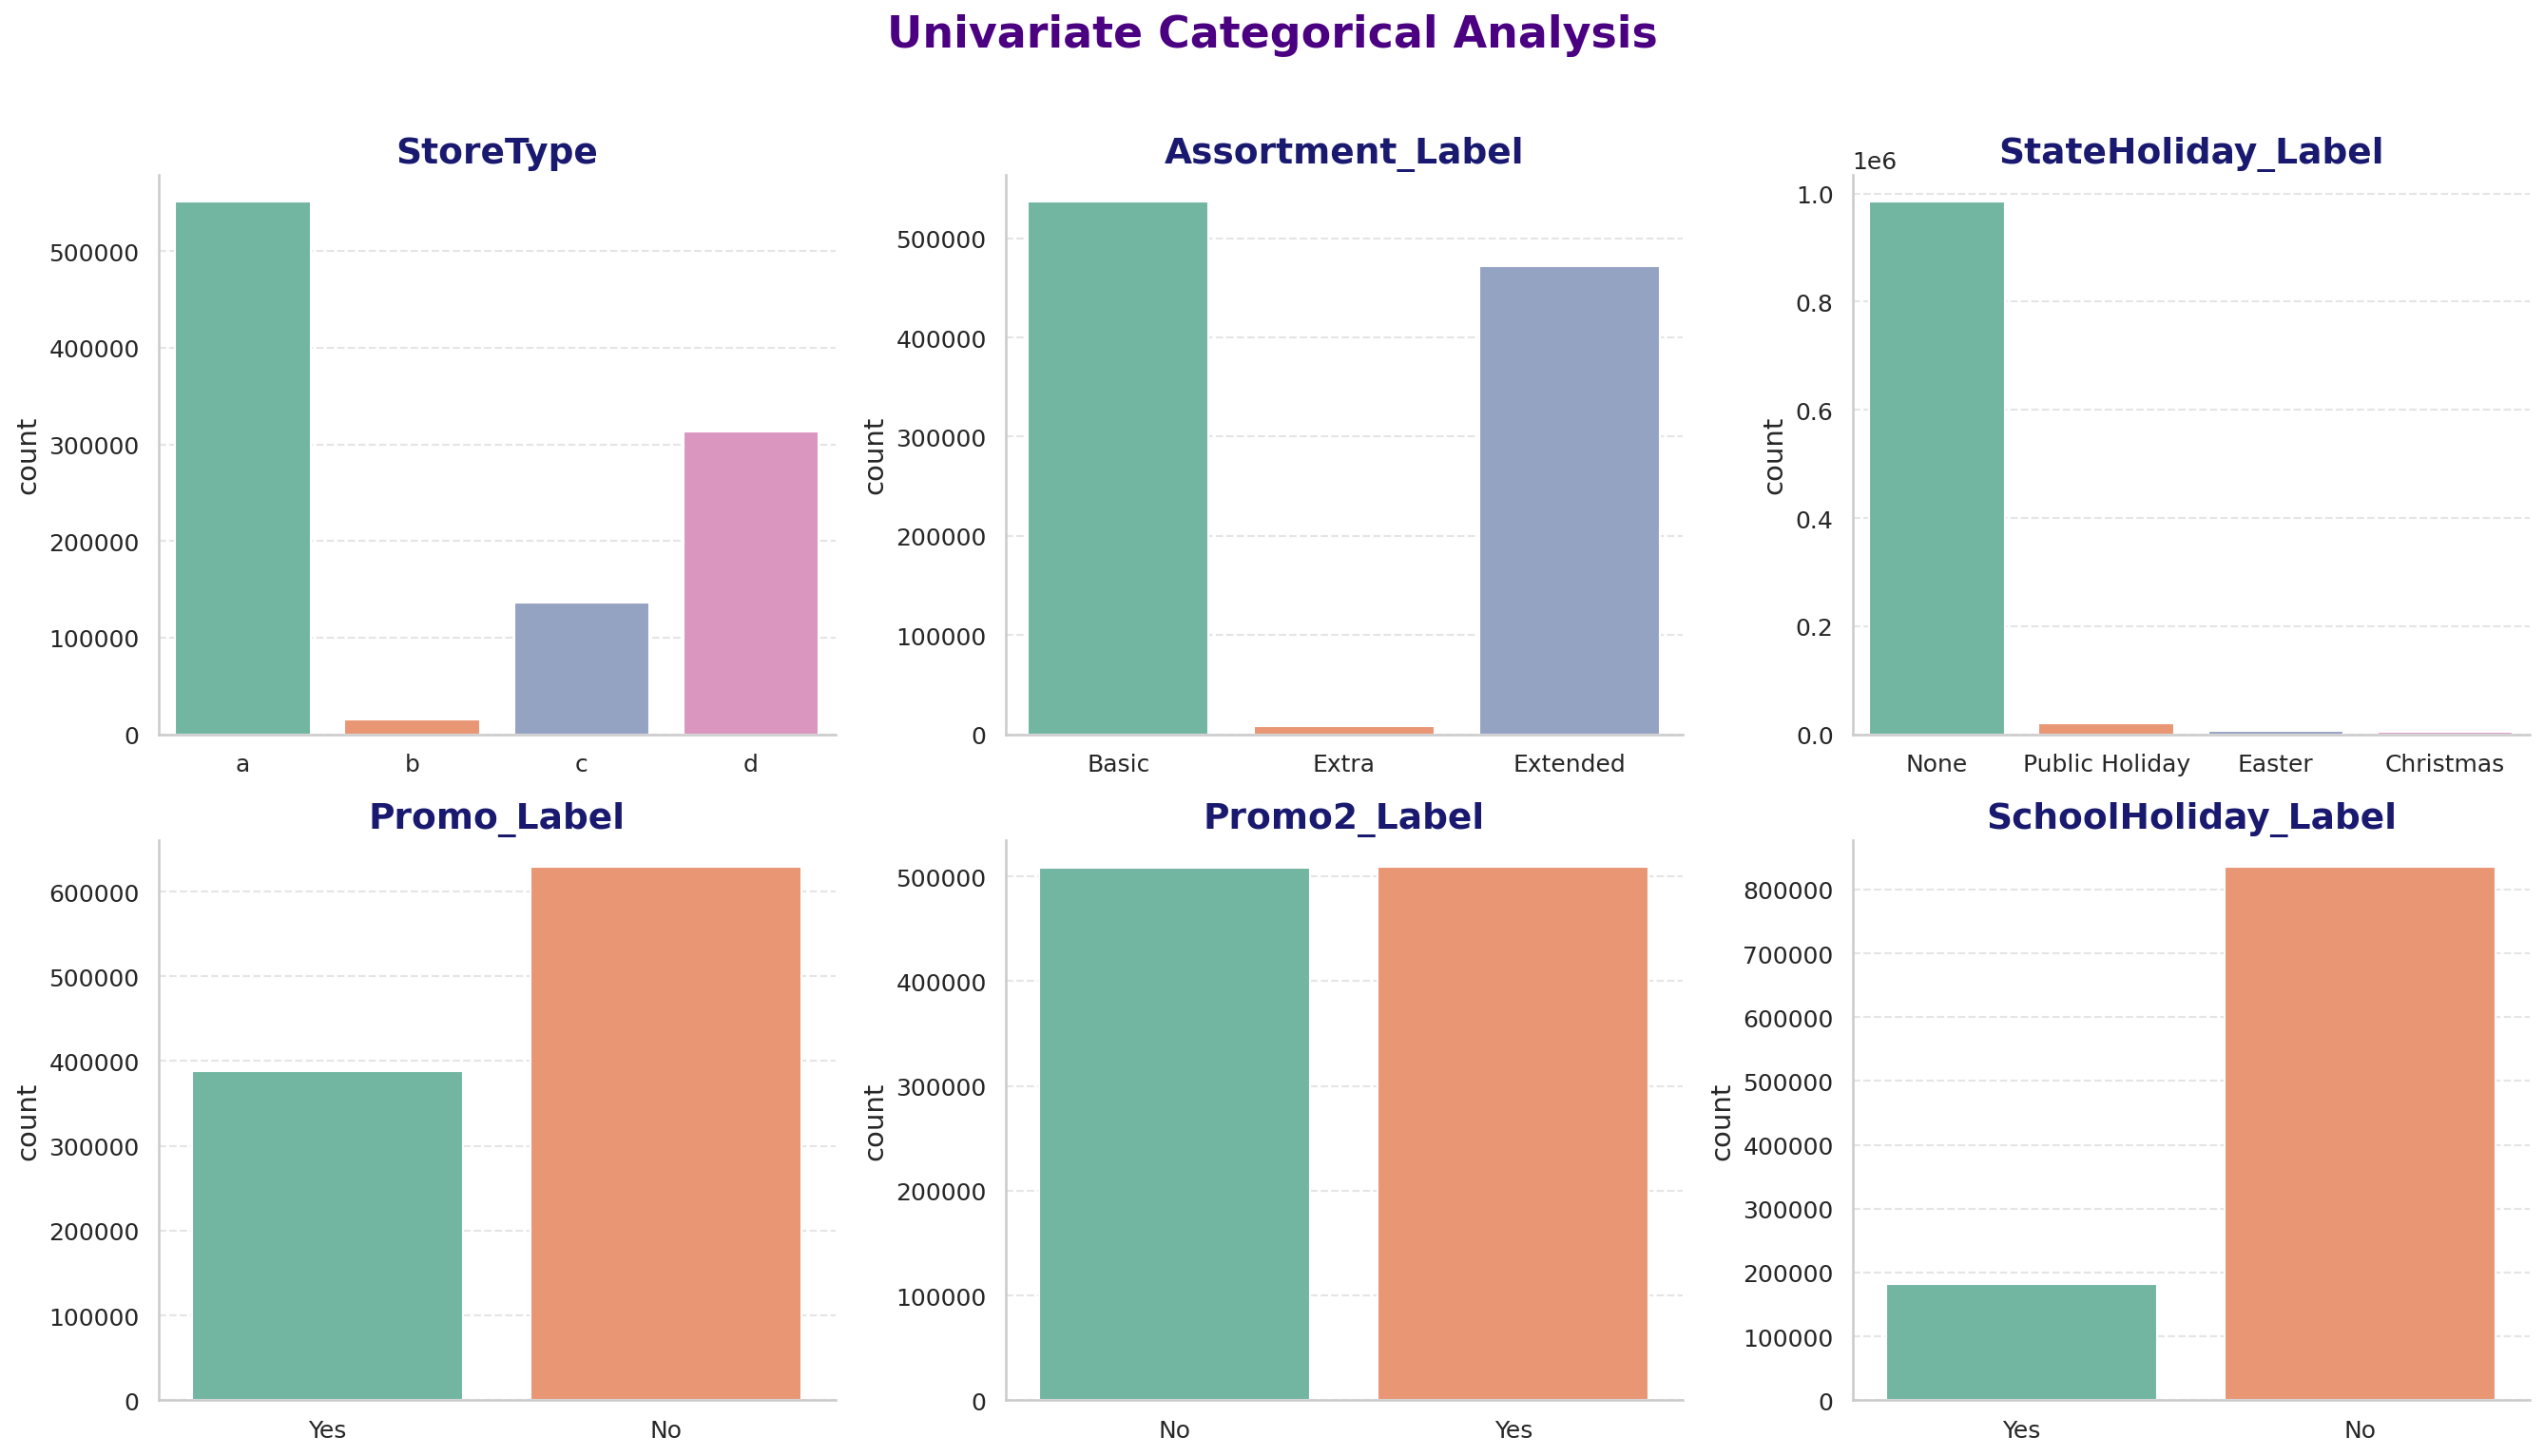

2026-09-08 17:15:07 - 01_salesfc_preprocessing - INFO - Univariate categorical analysis plotted for StoreType, Assortment, StateHoliday, Promo, Promo2, SchoolHoliday.


In [36]:
subsection_header("Univariate Analysis — Categorical Features")

categorical_cols = ["StoreType", "Assortment_Label", "StateHoliday_Label", "Promo_Label", "Promo2_Label", "SchoolHoliday_Label"]


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
plt.suptitle("Univariate Categorical Analysis", fontsize=22, fontweight="bold", y=1.02, color="indigo")

for i, col in enumerate(categorical_cols):
    # sns.countplot aggregates the counts automatically, replacing manual value_counts()
    sns.countplot(
        data=store_train_refined, 
        x=col, 
        ax=axes[i], 
        palette="Set2",  
        hue=col,  
        legend=False
    )
    
    axes[i].set_title(col, fontweight="bold",fontsize=18)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Assets/Univariate_category_grid.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info("Univariate categorical analysis plotted for StoreType, Assortment, StateHoliday, Promo, Promo2, SchoolHoliday.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Univariate Categorical Analysis:**

- `StoreType`: Type `a` dominates with over 500,000 records, followed by `d`, `c`, and `b` — the source data defines no further meaning for these codes beyond "4 different store models."
- `Assortment_Label`: Basic and Extended assortments are roughly comparable in volume, while Extra is a small minority — suggesting most stores run either a minimal or a broad product range, with few in between.
- `StateHoliday_Label`: The overwhelming majority of records show "None" — state holidays are rare relative to the full date range, as expected (most stores are closed on actual holidays, limiting recorded activity on those days).
- `Promo_Label`: A majority of records show no active promo on a given day, with a substantial minority running one.
- `Promo2_Label`: Nearly an even split between participating and non-participating records — consistent with roughly half of all stores being enrolled in Promo2, as seen earlier in the missingness investigation.
- `SchoolHoliday_Label`: Most records fall outside school holiday periods, with a smaller but meaningful share affected.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Univariate Analysis — Numerical Features

<div style="margin-left: 20px; max-width: 90%">

Each numerical column is inspected individually to understand its distribution, spread, and potential data quality issues — visualized via histograms with KDE (skewness and kurtosis annotated) and boxplots. This directly informs the outlier detection step that follows.

</div>

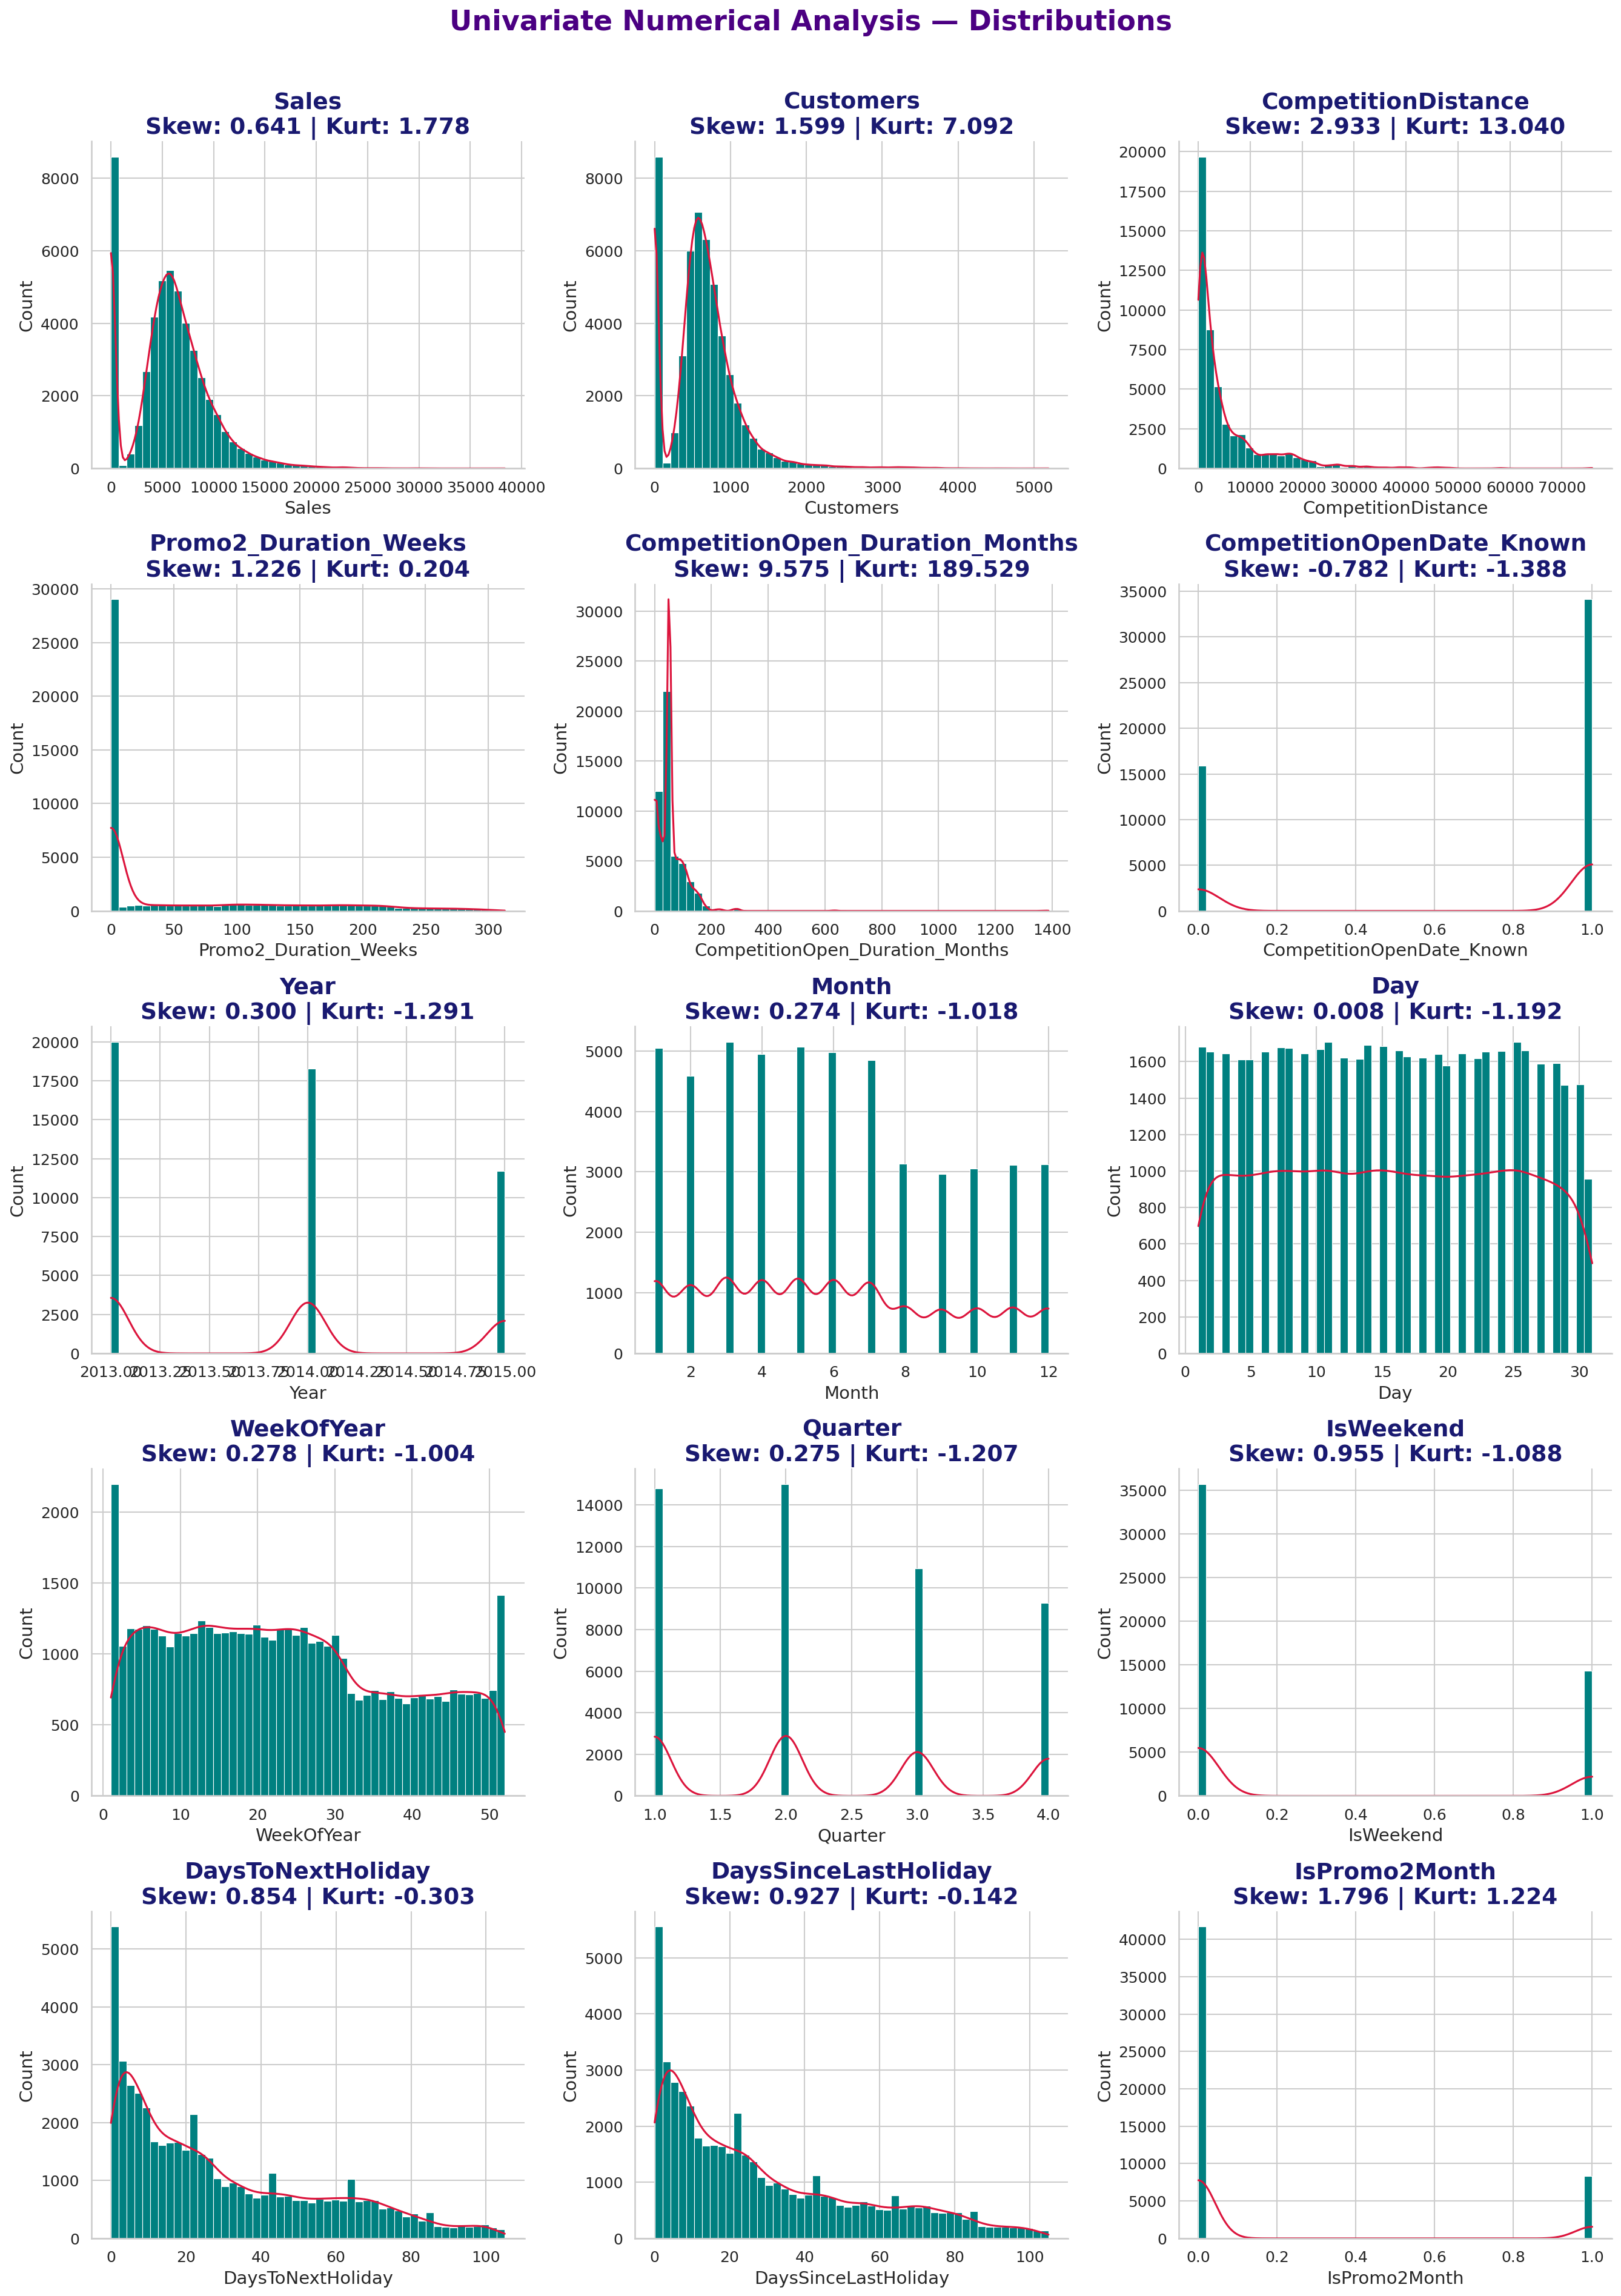

2026-09-08 17:15:25 - 01_salesfc_preprocessing - INFO - Univariate numerical distributions plotted for 15 columns (KDE computed on a 50,000-row sample per column for performance; skew/kurtosis computed on full data).


In [37]:
subsection_header("Univariate Analysis — Numerical Features: Distributions")

numerical_cols = store_train_refined.select_dtypes(include="number").columns.tolist()

n_cols = 3
n_rows = -(-len(numerical_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
plt.suptitle("Univariate Numerical Analysis — Distributions", fontsize=22, fontweight="bold", y=1.01, color="indigo")
axes = axes.flatten()

SAMPLE_SIZE = 50000

for i, col in enumerate(numerical_cols):
    values_full = store_train_refined[col].dropna()
    sk_val, kt_val = skew(values_full), kurtosis(values_full)

    values_sample = values_full.sample(n=min(SAMPLE_SIZE, len(values_full)), random_state=42)
    sns.histplot(values_sample, kde=True, ax=axes[i], color="crimson", facecolor="teal", bins=50)
    axes[i].set_title(f"{col}\nSkew: {sk_val:.3f} | Kurt: {kt_val:.3f}", fontweight="bold", fontsize=18)

for j in range(len(numerical_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig('Assets/Univariate_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Univariate numerical distributions plotted for {len(numerical_cols)} columns "
            f"(KDE computed on a 50,000-row sample per column for performance; "
            f"skew/kurtosis computed on full data).")

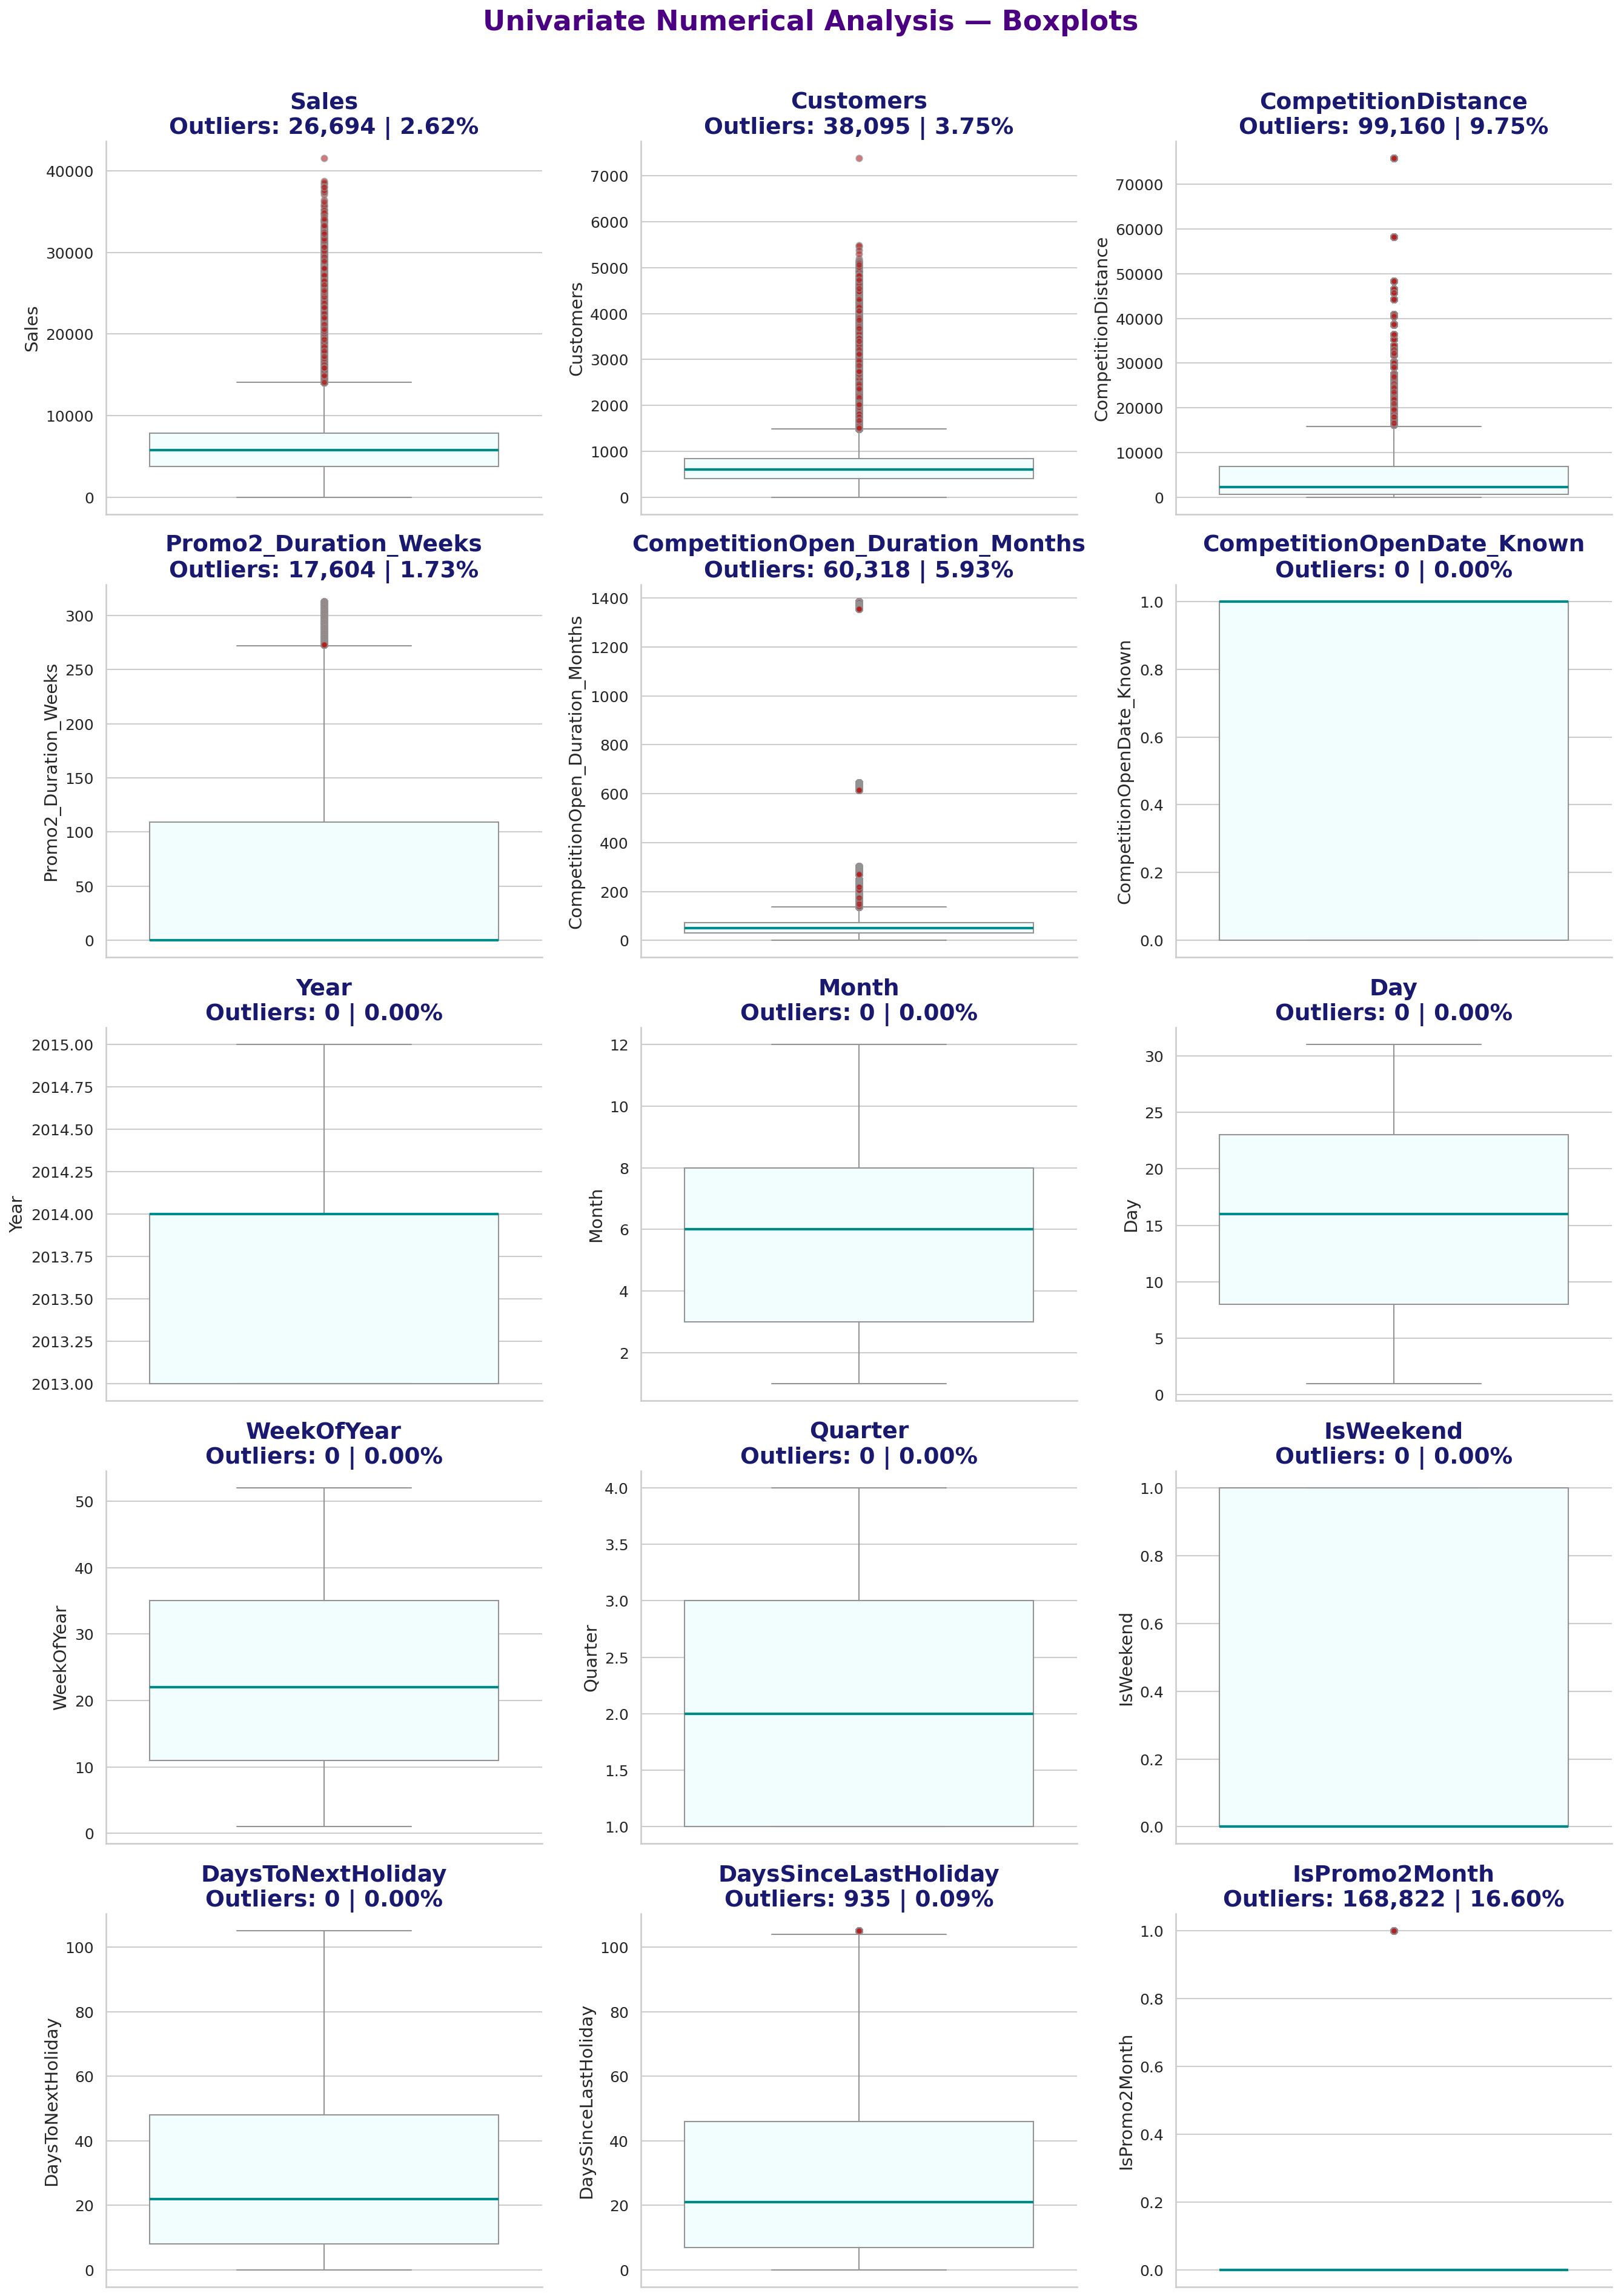

2026-09-08 17:16:05 - 01_salesfc_preprocessing - INFO - Univariate numerical boxplots + IQR outlier counts computed for 15 columns.


In [38]:
subsection_header("Univariate Analysis — Numerical Features: Boxplots")

n_cols = 3
n_rows = -(-len(numerical_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
plt.suptitle("Univariate Numerical Analysis — Boxplots", fontsize=22, fontweight="bold", y=1.01, color="indigo")
axes = axes.flatten()

outlier_counts = {}

for i, col in enumerate(numerical_cols):
    values = store_train_refined[col].dropna()
    outlier_mask = detect_outliers_iqr(store_train_refined, col)
    n_outliers = int(outlier_mask.sum())
    pct_outliers = n_outliers / len(store_train_refined) * 100
    outlier_counts[col] = {"count": n_outliers, "pct": pct_outliers}

    sns.boxplot(y=values, ax=axes[i], color="azure",medianprops=dict(color="darkcyan", linewidth=2),flierprops=dict(marker='o', markerfacecolor='firebrick', markersize=5, alpha=0.6))
    axes[i].set_title(f"{col}\nOutliers: {n_outliers:,} | {pct_outliers:.2f}%",fontweight="bold", fontsize=18)

for j in range(len(numerical_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig('Assets/Univariate_numerical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Univariate numerical boxplots + IQR outlier counts computed for {len(numerical_cols)} columns.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Univariate Numerical Analysis (Distributions & Outliers):**

- **`Sales`** and **`Customers`** are both right-skewed (0.641 and 1.599) with a moderate outlier rate (2.62% and 3.75%) — a small number of exceptionally high-traffic days, consistent with genuine business peaks rather than data errors.
- **`CompetitionDistance`** shows strong right skew (2.933) and the highest outlier rate among continuous features (9.75%) — a handful of stores are extremely far from any competitor, a real market characteristic rather than noise.
- **`CompetitionOpen_Duration_Months`** shows extreme skew (9.575) and kurtosis (189.5), with 5.93% flagged as outliers — driven by the small number of rows where competitor-opening data was genuinely unknown and median-filled, plus a few very long-established competitors.
- **Calendar-derived features** (`Year`, `Month`, `Day`, `Quarter`, `WeekOfYear`) show **zero outliers** across the board — expected, since these are bounded, evenly-distributed values by construction, confirming the date extraction worked correctly.
- **`IsPromo2Month`** and **`CompetitionOpenDate_Known`** show high nominal "outlier" percentages (16.60% and 0%), but as binary flags, IQR-based outlier detection isn't meaningful here — a binary column's minority class is not a statistical anomaly, just an imbalanced flag.
- **`DaysToNextHoliday`** and **`DaysSinceLastHoliday`** show mild-to-moderate skew, with `DaysSinceLastHoliday` flagging a small 0.09% outlier rate — consistent with the rare boundary rows resolved earlier via the dataset's maximum observed gap.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Outlier Treatment — Decision Summary

<div style="margin-left: 20px; max-width: 90%">

Not every flagged outlier warrants treatment — binary/flag columns and bounded calendar features are excluded from treatment entirely, since IQR flagging isn't statistically meaningful for them. For genuine continuous features, a decision is made per column: retain (a real, valid extreme value) or cap (a statistical extreme likely to distort modeling).

</div>

In [39]:
subsection_header("Outlier Treatment — Decision Summary")

def decision_badge(text):
    color = "#2E8B57" if text == "Retain" else "#C0392B"  # green=Retain, red=Cap
    return (f'<span style="background:{color};color:white;padding:4px 14px;'
            f'border-radius:12px;font-weight:bold;font-size:12px;">{text}</span>')

decision_data = {
    "Feature": ["Sales", "Customers", "CompetitionDistance", "Promo2_Duration_Weeks",
                "CompetitionOpen_Duration_Months", "DaysToNextHoliday", "DaysSinceLastHoliday"],
    "Outlier %": [2.62, 3.75, 9.75, 1.73, 5.93, 0.00, 0.09],
    "Decision": ["Retain", "Retain", "Retain", "Retain", "Cap (99th pct)", "Retain", "Retain"],
    "Justification": [
        "Genuine high-traffic sales days",
        "Genuine high-footfall days",
        "Real market characteristic — some stores are genuinely isolated",
        "Long-tenured Promo2 stores — valid",
        "Extreme values driven by imputed/very old competitor-open dates",
        "No outliers detected",
        "Boundary rows already resolved via dataset-derived max gap"
    ]
}
decision_df = pd.DataFrame(decision_data)
decision_df["Decision"] = decision_df["Decision"].apply(decision_badge)
decision_df["Justification"] = decision_df["Justification"].apply(lambda x: f"<i>{x}</i>")

centered_table(decision_df)

logger.info("Outlier treatment decision table generated — only CompetitionOpen_Duration_Months flagged for capping.")

Feature,Outlier %,Decision,Justification
Sales,2.62,Retain,Genuine high-traffic sales days
Customers,3.75,Retain,Genuine high-footfall days
CompetitionDistance,9.75,Retain,Real market characteristic — some stores are genuinely isolated
Promo2_Duration_Weeks,1.73,Retain,Long-tenured Promo2 stores — valid
CompetitionOpen_Duration_Months,5.93,Cap (99th pct),Extreme values driven by imputed/very old competitor-open dates
DaysToNextHoliday,0.00,Retain,No outliers detected
DaysSinceLastHoliday,0.09,Retain,Boundary rows already resolved via dataset-derived max gap


2026-09-08 17:16:05 - 01_salesfc_preprocessing - INFO - Outlier treatment decision table generated — only CompetitionOpen_Duration_Months flagged for capping.


### 📌 Applying Outlier Treatment

<div style="margin-left: 20px; max-width: 90%">

Per the decision table, only `CompetitionOpen_Duration_Months` is capped at its 99th percentile — all other features are retained as-is, since their flagged extremes represent genuine business variation rather than data errors.

</div>

In [40]:
subsection_header("Applying Outlier Treatment")

before_values = store_train_refined["CompetitionOpen_Duration_Months"].dropna().copy()
before_skew = skew(before_values)
before_kurt = kurtosis(before_values)

cap_value = store_train_refined["CompetitionOpen_Duration_Months"].quantile(0.99)

store_train_refined["CompetitionOpen_Duration_Months"] = store_train_refined["CompetitionOpen_Duration_Months"].clip(upper=cap_value)
store_test_refined["CompetitionOpen_Duration_Months"] = store_test_refined["CompetitionOpen_Duration_Months"].clip(upper=cap_value)

after_skew = skew(store_train_refined["CompetitionOpen_Duration_Months"].dropna())
after_kurt = kurtosis(store_train_refined["CompetitionOpen_Duration_Months"].dropna())

success_box(f"CompetitionOpen_Duration_Months capped at 99th percentile ({cap_value:.1f} months). "
            f"<b>Skew: {before_skew:.3f} → {after_skew:.3f}</b> | <b>Kurtosis: {before_kurt:.3f} → {after_kurt:.3f}</b>")

logger.info(f"CompetitionOpen_Duration_Months capped at {cap_value:.2f}. "
            f"Skew {before_skew:.3f}->{after_skew:.3f}, Kurtosis {before_kurt:.3f}->{after_kurt:.3f}")

2026-09-08 17:16:05 - 01_salesfc_preprocessing - INFO - CompetitionOpen_Duration_Months capped at 199.00. Skew 9.575->1.008, Kurtosis 189.529->1.094


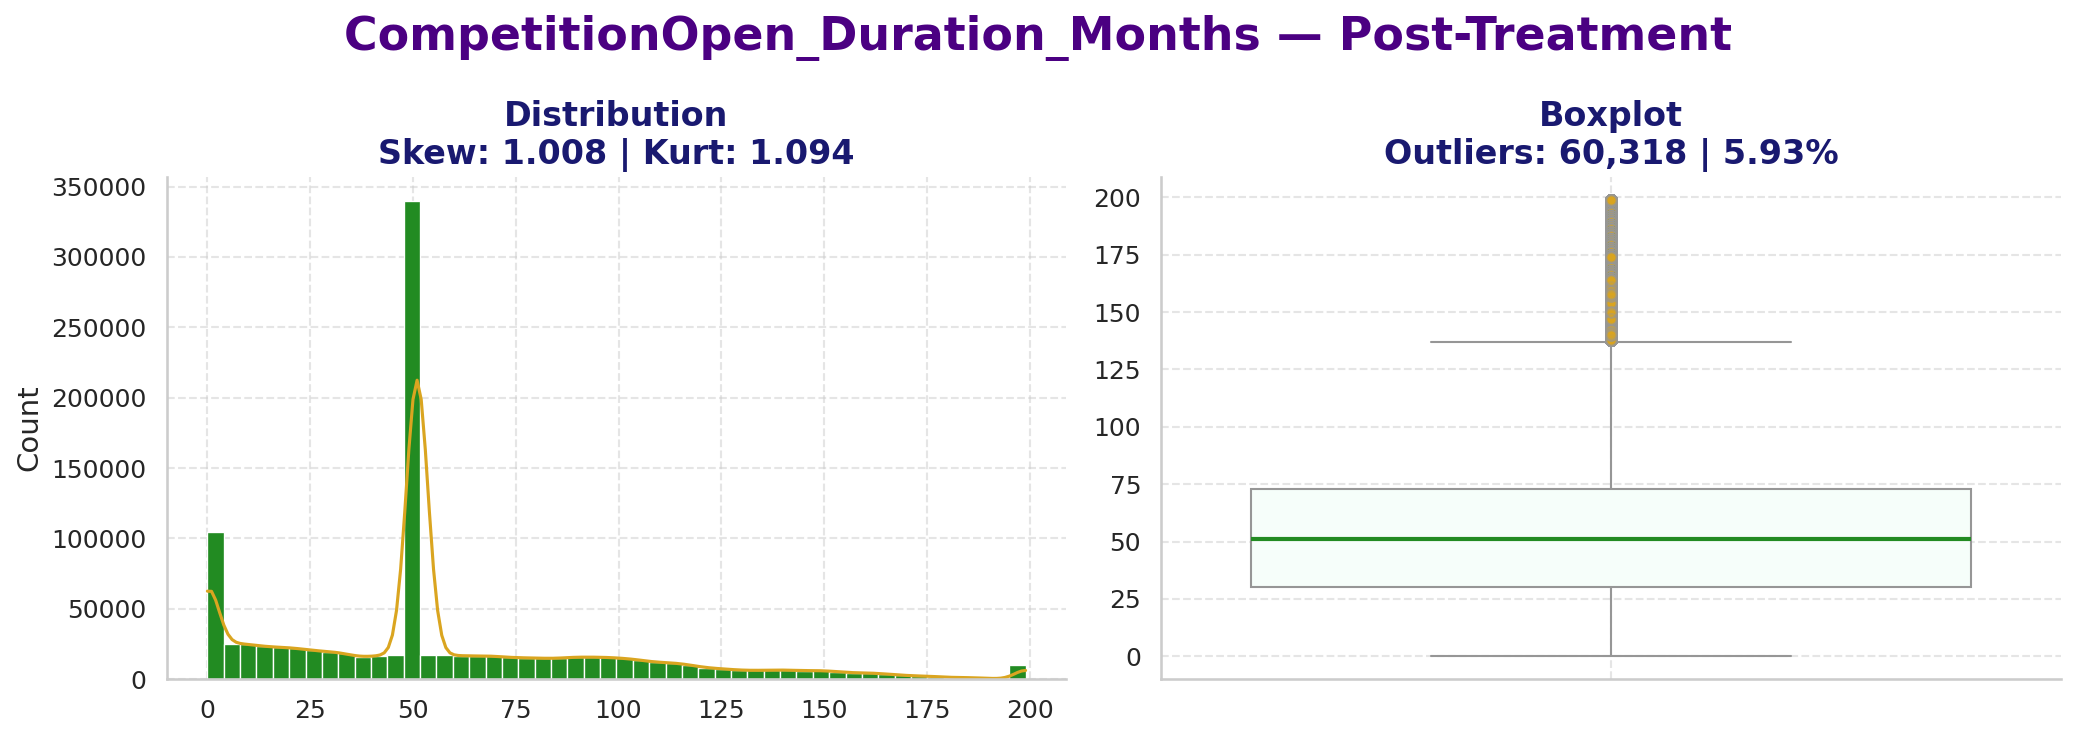

2026-09-08 17:16:49 - 01_salesfc_preprocessing - INFO - Post-treatment visual generated for CompetitionOpen_Duration_Months — outliers now 60,318 (5.93%).


In [41]:
after_values = store_train_refined["CompetitionOpen_Duration_Months"].dropna()
after_mask = detect_outliers_iqr(store_train_refined, "CompetitionOpen_Duration_Months")
after_outlier_count = int(after_mask.sum())
after_outlier_pct = after_outlier_count / len(store_train_refined) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(after_values, kde=True, ax=axes[0], color="goldenrod",facecolor="forestgreen", bins=50)
axes[0].set_title(f"Distribution\nSkew: {after_skew:.3f} | Kurt: {after_kurt:.3f}", fontweight="bold",fontsize=16)
axes[0].grid(linestyle='--', alpha=0.5)
axes[0].set_xlabel("")
sns.boxplot(y=after_values, ax=axes[1], color="mintcream",medianprops=dict(color="forestgreen", linewidth=2),flierprops=dict(marker='o', markerfacecolor='goldenrod', markersize=5, alpha=0.6))
axes[1].set_title(f"Boxplot\nOutliers: {after_outlier_count:,} | {after_outlier_pct:.2f}%", fontweight="bold",fontsize=16)
axes[1].grid(linestyle='--', alpha=0.5)
axes[1].set_ylabel("")

plt.suptitle("CompetitionOpen_Duration_Months — Post-Treatment", fontsize=22, fontweight="bold", color="indigo")
plt.tight_layout()
plt.savefig('Assets/CompetitionOpen_Duration_Months_post_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Post-treatment visual generated for CompetitionOpen_Duration_Months — "
            f"outliers now {after_outlier_count:,} ({after_outlier_pct:.2f}%).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — CompetitionOpen_Duration_Months Post-Treatment:**

- Capping at the 99th percentile brought skewness down from 9.575 to 1.008 and kurtosis from 189.529 to 1.094 — both now within a reasonable range for modeling.
- The remaining 5.93% IQR-flagged "outliers" are an expected artifact of the capped ceiling itself (many rows now sit exactly at the 199-month cap), not a sign further treatment is needed.
- This closes Univariate Analysis — all numerical and categorical features have been examined, and the one feature requiring treatment has been resolved.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Promo Distribution: Train vs. Test

<div style="margin-left: 20px; max-width: 90%">

Comparing how `Promo` is distributed between `store_train_refined` and `store_test_refined` checks whether the two sets are consistent in how frequently promotions run — an inconsistency here could bias how well a model trained on one generalizes to the other.

</div>

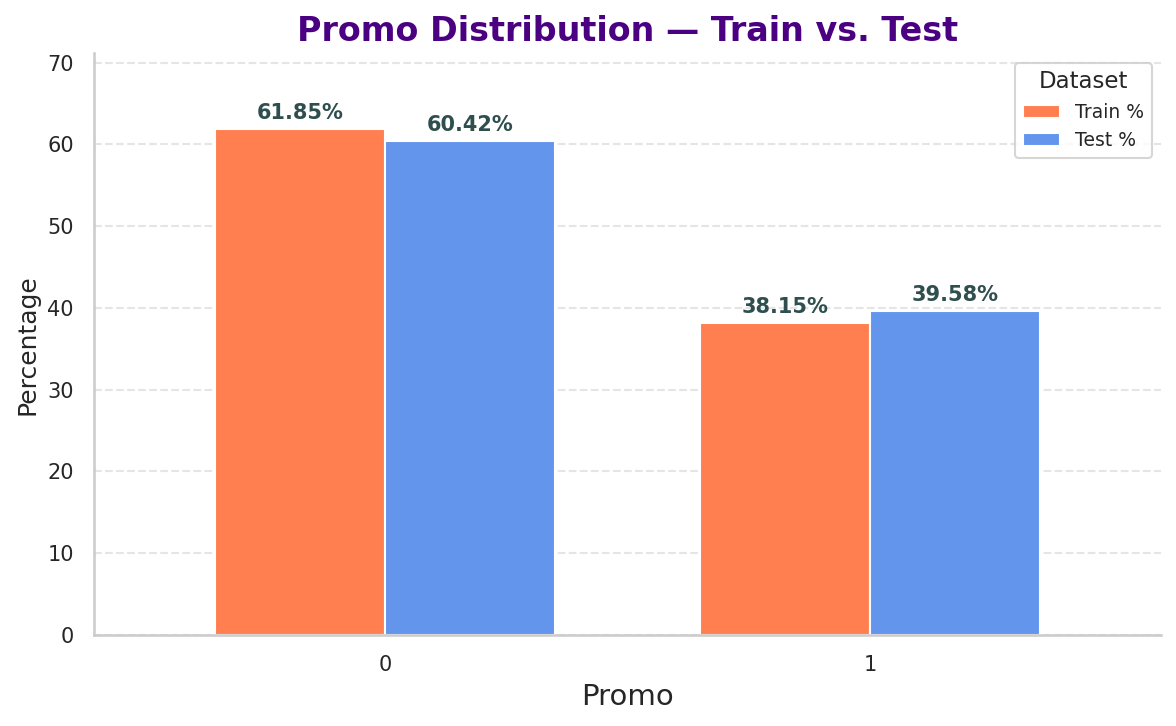

2026-09-08 17:16:50 - 01_salesfc_preprocessing - INFO - Promo distribution compared — train vs. test.


In [42]:
subsection_header("Bivariate Analysis — Promo Distribution")

train_promo_pct = store_train_refined["Promo"].value_counts(normalize=True) * 100
test_promo_pct = store_test_refined["Promo"].value_counts(normalize=True) * 100

comparison_df = pd.DataFrame({
    "Promo": train_promo_pct.index,
    "Train %": train_promo_pct.values,
    "Test %": test_promo_pct.reindex(train_promo_pct.index).values
})

fig, ax = plt.subplots(figsize=(8, 5))
comparison_df.set_index("Promo").plot(kind="bar", ax=ax, color=["coral", "cornflowerblue"], edgecolor="white", width=0.7)
ax.set_title("Promo Distribution — Train vs. Test", fontweight="bold", fontsize=16, color="indigo")
ax.set_ylabel("Percentage",fontsize=12)
plt.xticks(rotation=0,fontsize=10)
plt.yticks(fontsize=10)

# Iterate through the chart containers to place labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontweight='bold', color='darkslategray', fontsize=10)

# Extend the y-axis slightly so the highest labels are not cut off by the top of the plot
ax.set_ylim(0, comparison_df[["Train %", "Test %"]].max().max() * 1.15)
ax.legend(title="Dataset", loc="upper right", fontsize=9, title_fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(False, axis='x')  # Disable x-axis grid for clarity
plt.tight_layout()
plt.savefig('Assets/Bivariate_promo_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Table output removed to eliminate redundancy
logger.info("Promo distribution compared — train vs. test.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Promo Distribution: Train vs. Test:**

- Promo distribution is closely matched between train (**61.85% no promo / 38.15% promo**) and test (**60.42% no promo / 39.58% promo**) — less than a 1.5 percentage-point difference in either direction.
- This confirms train and test are drawn from a consistent underlying process with respect to promotions — a model trained on train's promo patterns should generalize well to test without needing promo-specific reweighting or correction.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Sales Behavior: Before, During, and After Holidays

<div style="margin-left: 20px; max-width: 90%">

Holidays significantly disrupt standard retail patterns. Because the vast majority of European stores close on public holidays, we must isolate `Open == 1` to understand true holiday performance. This section evaluates whether customers compensate for holiday closures by stocking up beforehand, how open stores perform on the holiday itself, and the recovery rate in the days following.

</div>

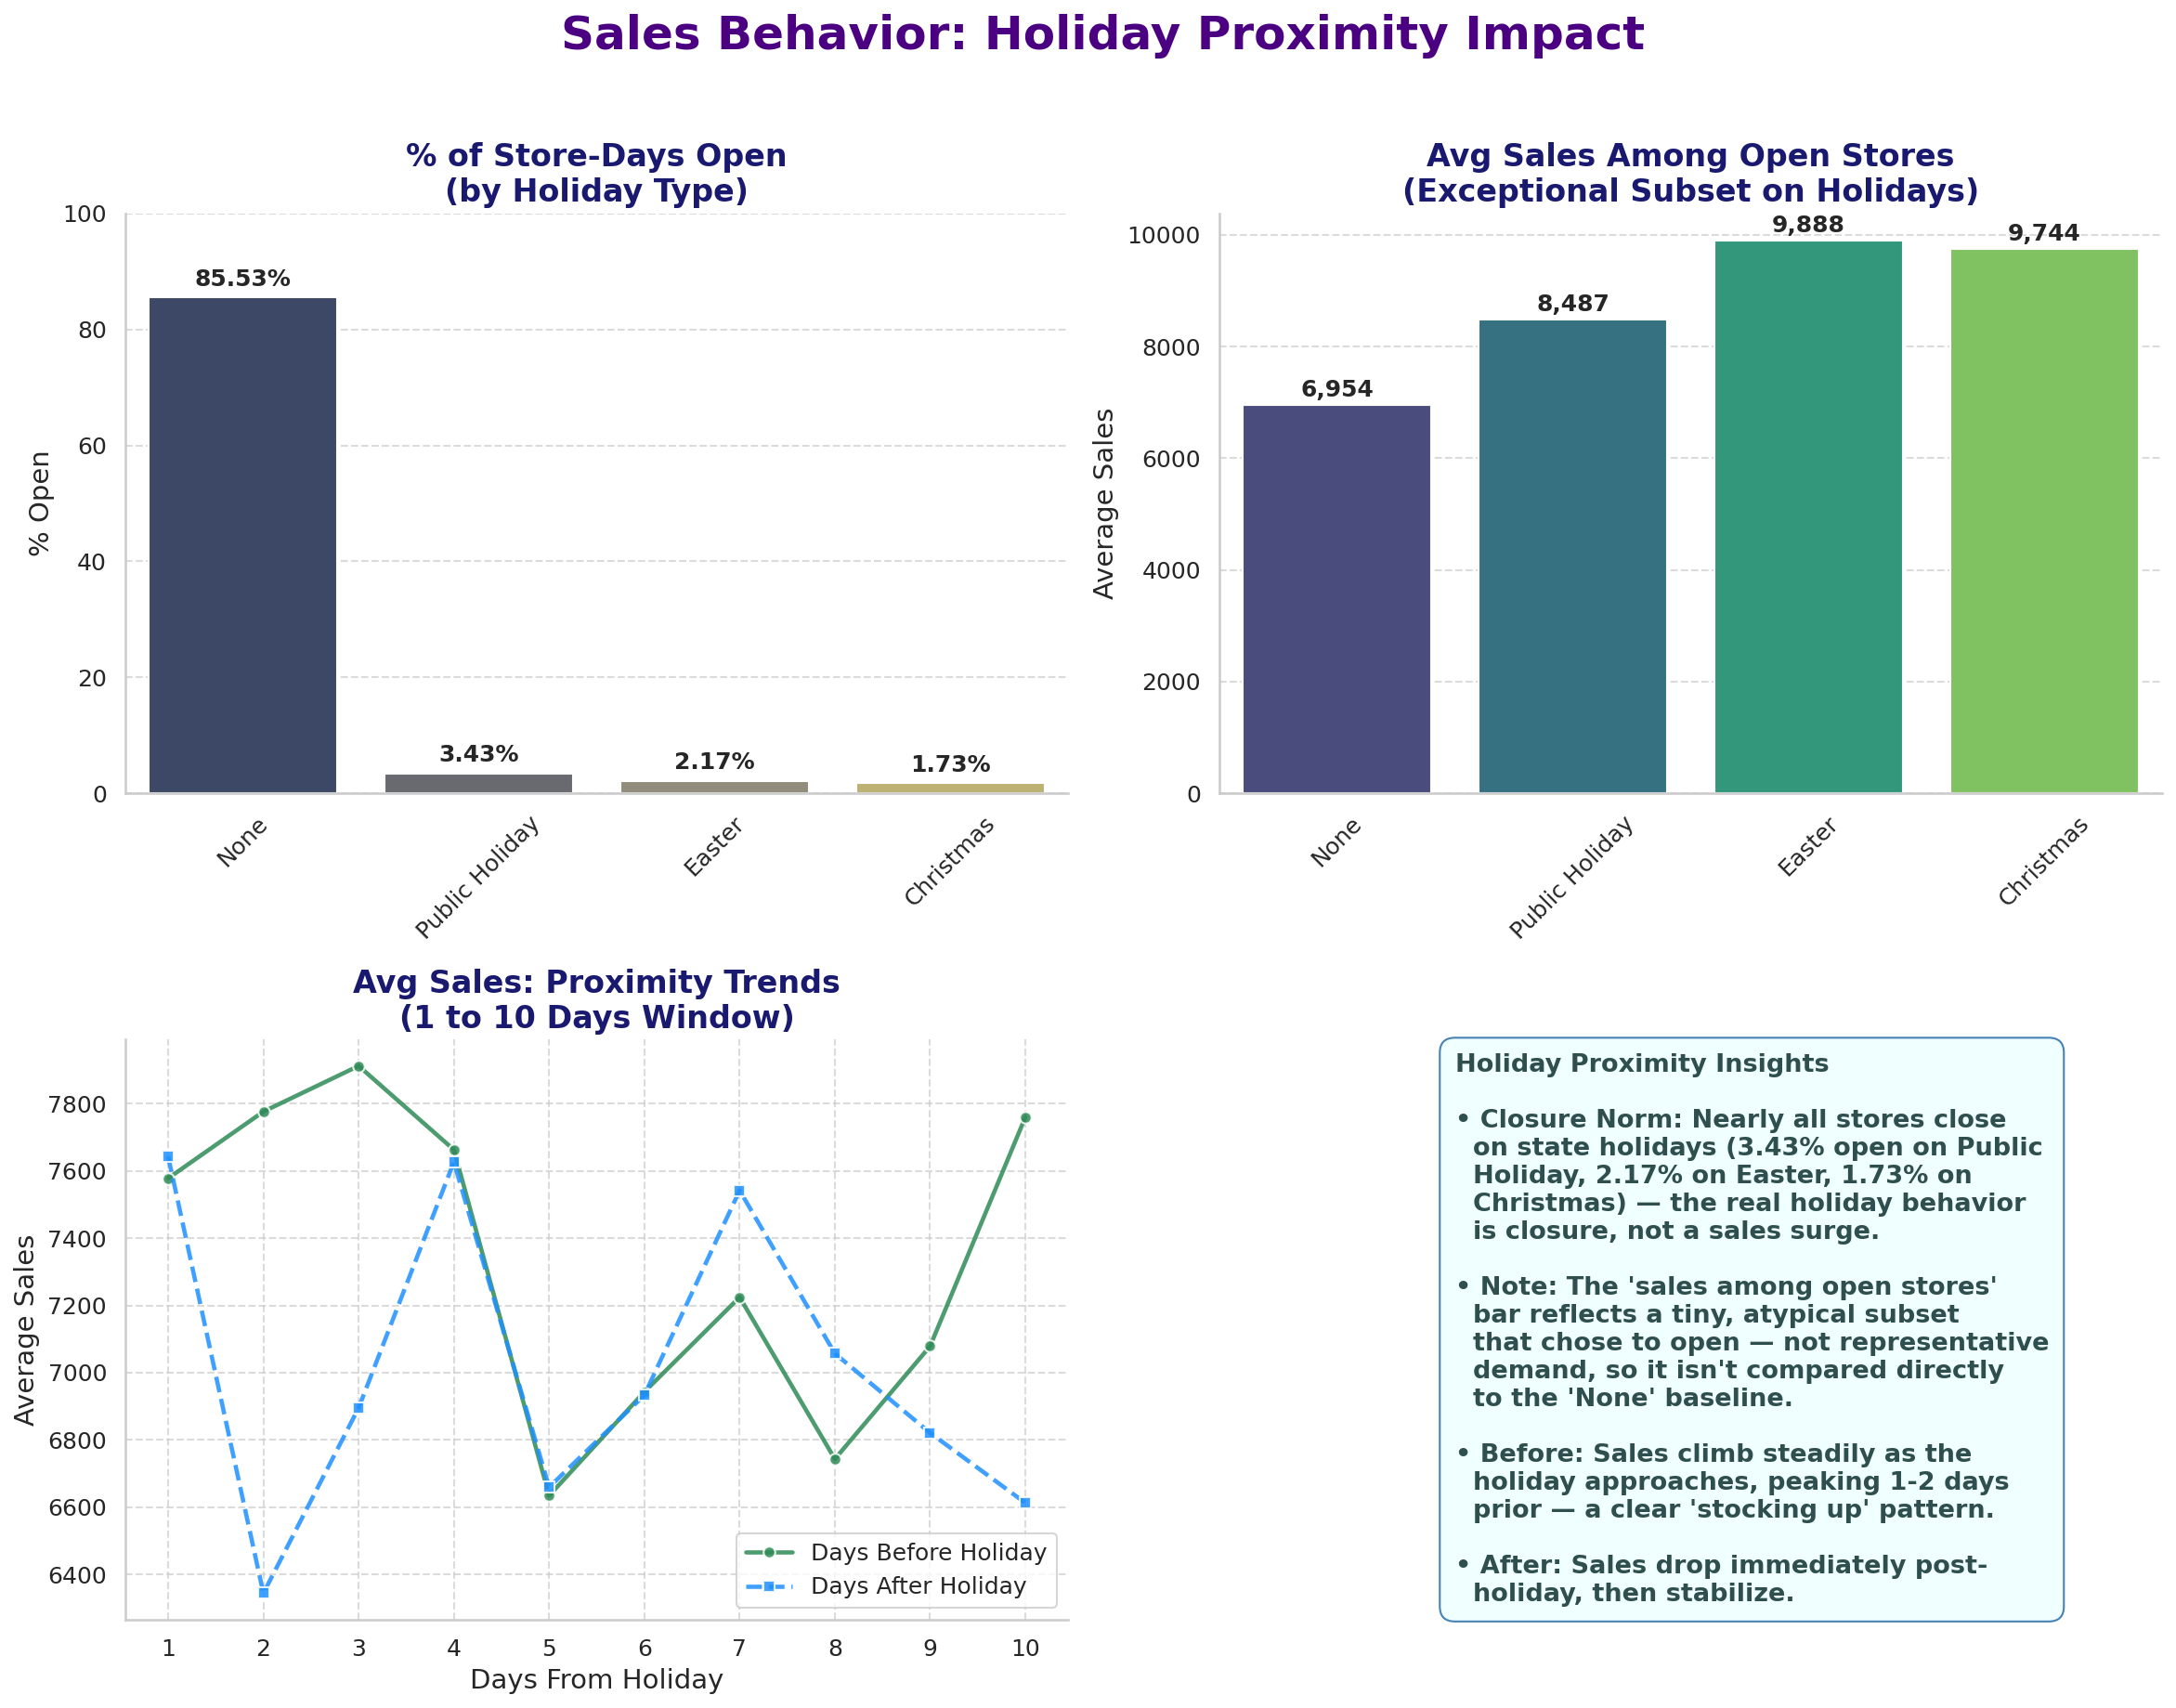

2026-09-08 17:16:51 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Sales behavior Before/During/After holidays (closure rate added to correct Open==1 selection bias).


In [43]:
subsection_header("Bivariate — Sales Behavior: Before/During/After Holidays")

# --- Closure rate by holiday type (Open is category dtype -> cast to int for aggregation) ---
open_holiday = store_train_refined["Open"].astype(int)
closure_rate = (open_holiday.groupby(store_train_refined["StateHoliday_Label"], observed=True).mean().mul(100)
    .reindex(["None", "Public Holiday", "Easter", "Christmas"]))

# --- Sales among the stores that DO open (small, non-representative subset for holiday types) ---
open_train = store_train_refined[store_train_refined["Open"] == 1]
holiday_sales_open = (open_train.groupby("StateHoliday_Label", observed=True)["Sales"].mean()
    .reindex(["None", "Public Holiday", "Easter", "Christmas"]))

# 2x2 Grid: closure rate, sales-when-open, proximity trend, insight box
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales Behavior: Holiday Proximity Impact', fontsize=24, color='indigo', fontweight='bold', y=1.02)
fig.subplots_adjust(wspace=0.3, hspace=0.4)

sns.barplot(x=closure_rate.index, y=closure_rate.values, ax=axes[0, 0], palette="cividis",hue=closure_rate.index, legend=False)
axes[0, 0].set_title("% of Store-Days Open\n(by Holiday Type)", fontweight='bold', fontsize=16)
axes[0, 0].set_ylabel("% Open"); axes[0, 0].set_xlabel(""); axes[0, 0].set_ylim(0, 100)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(closure_rate.values):
    axes[0, 0].text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

sns.barplot(x=holiday_sales_open.index, y=holiday_sales_open.values, ax=axes[0, 1], palette="viridis",hue=holiday_sales_open.index, legend=False)
axes[0, 1].set_title("Avg Sales Among Open Stores\n(Exceptional Subset on Holidays)", fontweight='bold', fontsize=16)
axes[0, 1].set_ylabel("Average Sales"); axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(holiday_sales_open.values):
    axes[0, 1].text(i, v + 150, f"{v:,.0f}", ha='center', fontweight='bold')

before_trend = open_train[open_train["DaysToNextHoliday"].between(1, 10)].groupby("DaysToNextHoliday")["Sales"].mean()
after_trend = open_train[open_train["DaysSinceLastHoliday"].between(1, 10)].groupby("DaysSinceLastHoliday")["Sales"].mean()

axes[1, 0].plot(before_trend.index, before_trend.values, marker='o', color='seagreen', linewidth=2.2, label='Days Before Holiday',alpha=0.85,markeredgecolor='white')
axes[1, 0].plot(after_trend.index, after_trend.values, marker='s', color='dodgerblue', linewidth=2.2,linestyle='--', label='Days After Holiday',alpha=0.85,markeredgecolor='white')
axes[1, 0].set_title("Avg Sales: Proximity Trends\n(1 to 10 Days Window)", fontweight='bold', fontsize=16)
axes[1, 0].set_ylabel("Average Sales"); axes[1, 0].set_xlabel("Days From Holiday")
axes[1, 0].set_xticks(range(1, 11)); axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

axes[1, 1].axis('off')
insight_text = ("Holiday Proximity Insights\n\n"
                "• Closure Norm: Nearly all stores close\n"
                f"  on state holidays ({closure_rate['Public Holiday']:.2f}% open on Public\n"
                f"  Holiday, {closure_rate['Easter']:.2f}% on Easter, {closure_rate['Christmas']:.2f}% on\n"
                "  Christmas) — the real holiday behavior\n"
                "  is closure, not a sales surge.\n\n"
                "• Note: The 'sales among open stores'\n"
                "  bar reflects a tiny, atypical subset\n"
                "  that chose to open — not representative\n"
                "  demand, so it isn't compared directly\n"
                "  to the 'None' baseline.\n\n"
                "• Before: Sales climb steadily as the\n"
                "  holiday approaches, peaking 1-2 days\n"
                "  prior — a clear 'stocking up' pattern.\n\n"
                "• After: Sales drop immediately post-\n"
                "  holiday, then stabilize.")
axes[1, 1].text(0.25, 0.5, insight_text, transform=axes[1, 1].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_sales_holiday_trends.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info("Bivariate analysis plotted: Sales behavior Before/During/After holidays (closure rate added to correct Open==1 selection bias).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Sales Behavior: Before/During/After Holidays:**

- Store closure is the dominant "holiday behavior," not increased demand — only **3.43%** of stores open on Public Holiday, **2.17%** on Easter, and **1.73%** on Christmas, versus **85.53%** open on an ordinary day.
- Among the small subset that do open, average sales are notably higher than the "None" baseline (**6,954**) — Public Holiday **8,487**, Easter **9,888**, Christmas **9,744** — but this reflects a tiny, non-representative subset, not a network-wide demand surge, so it isn't a like-for-like comparison to "None."
- The Before/After proximity trend is noisier than a clean gradual build-up and drop-off: the "before" line peaks at 3 days out rather than 1-2, and the "after" line oscillates (sharp dip at day 2, rebound at day 4, another spike at day 7) rather than stabilizing smoothly. This pattern lines up with the weekly cycle confirmed in the Seasonal analysis below (Monday/Sunday highs vs. midweek lows) — `DaysToNextHoliday`/`DaysSinceLastHoliday` don't control for day-of-week, so some of this apparent "holiday proximity effect" is likely day-of-week bleeding through. A day-of-week-controlled version of this chart would be a good Beyond-Ask follow-up.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Seasonal Patterns

<div style="margin-left: 20px; max-width: 90%">

Retail sales are heavily influenced by temporal cycles. This section visualizes yearly seasonality (average sales by Month) and weekly seasonality (average sales by Day of Week) to understand peak shopping periods and typical customer routines.

</div>

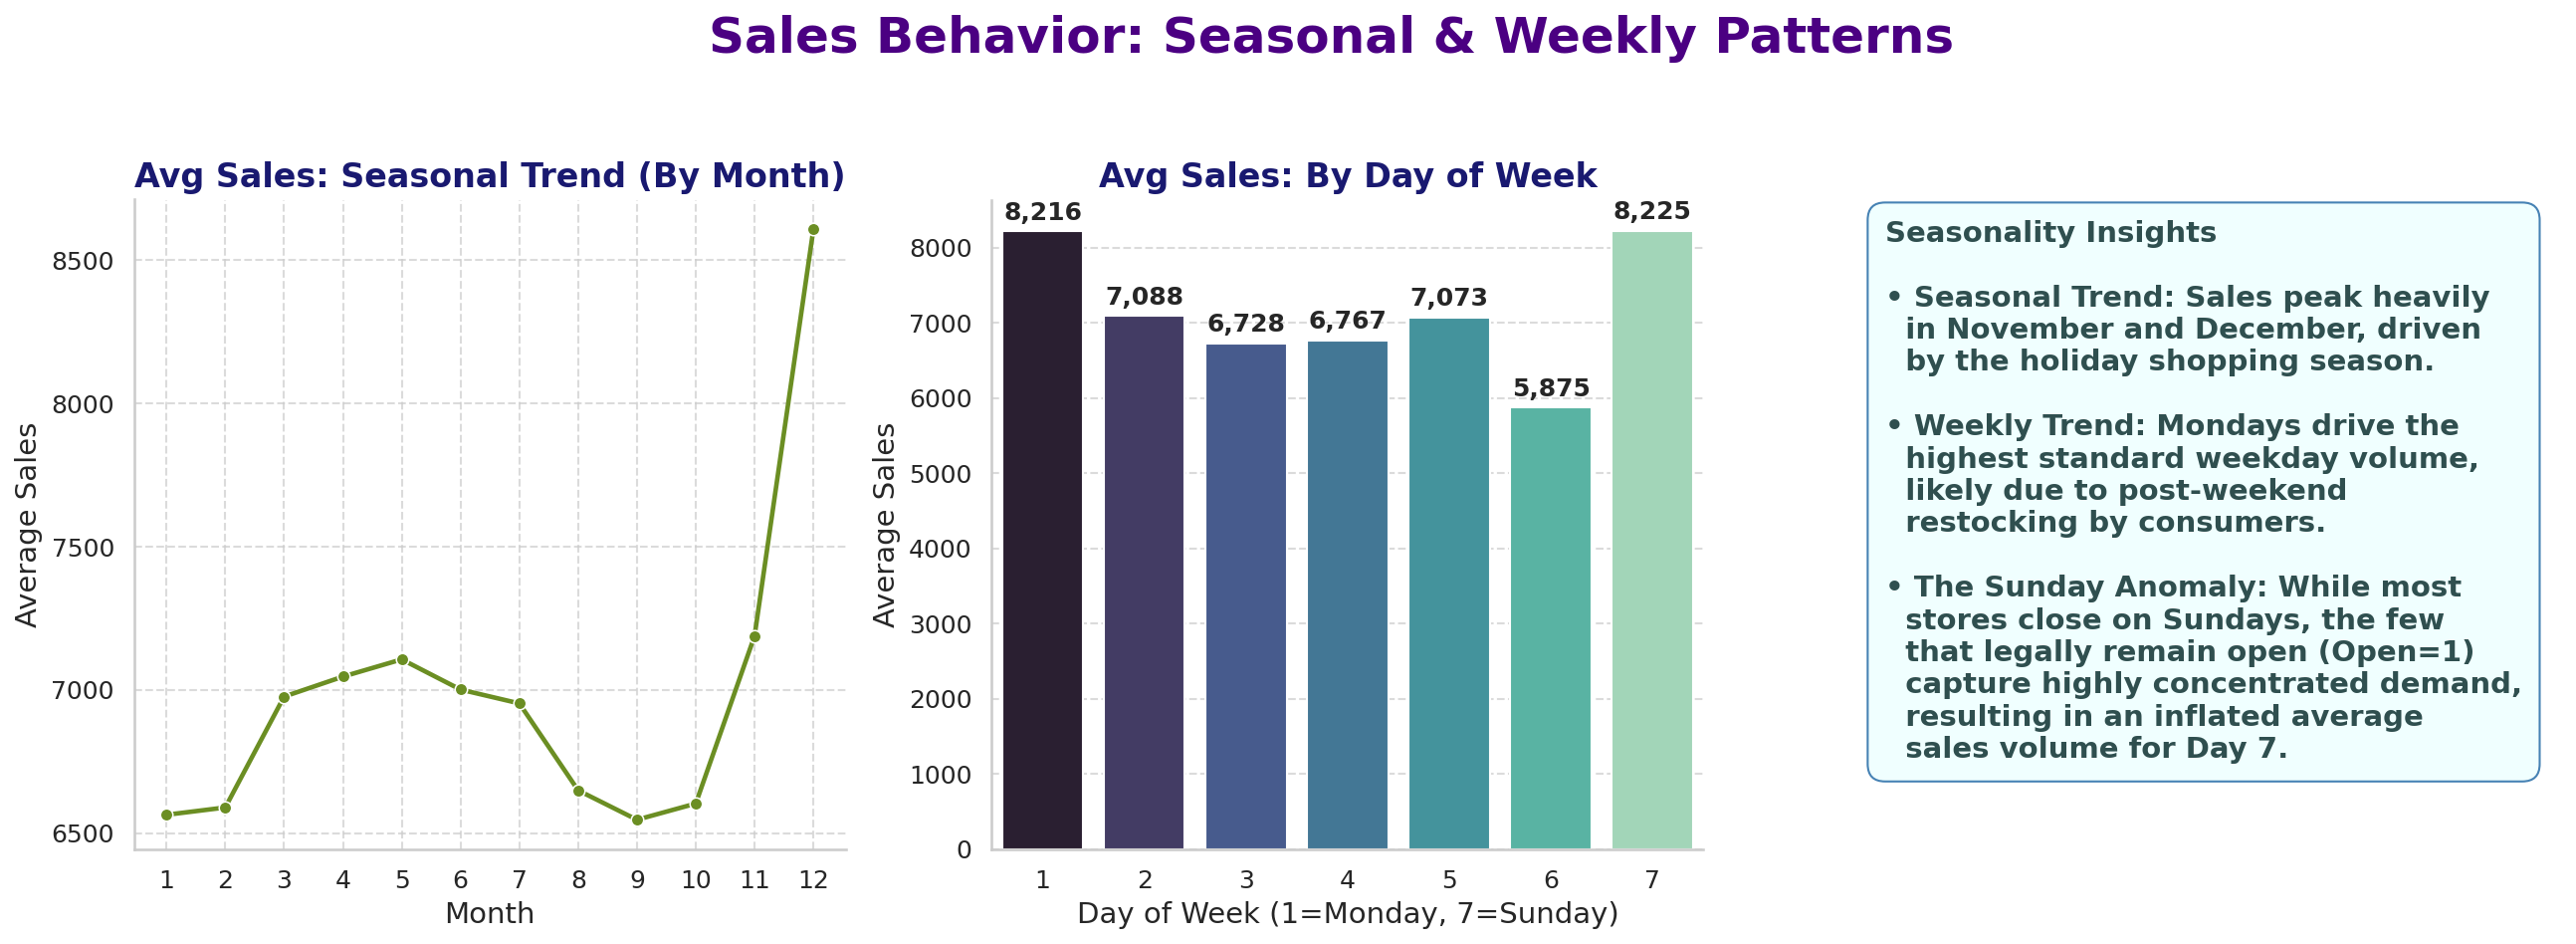

2026-09-08 17:16:53 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Seasonal and Weekly Sales patterns.


In [44]:
subsection_header("Bivariate — Seasonal Patterns: Months & Days")

# Isolate open stores
open_train = store_train_refined[store_train_refined["Open"] == 1]

# 1x3 Grid: 2 plots, 1 text box
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Sales Behavior: Seasonal & Weekly Patterns', fontsize=24, color='indigo', fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.3)

# Plot 1: Monthly Trend
monthly_sales = open_train.groupby('Month', observed=True)['Sales'].mean()
sns.lineplot(
    x=monthly_sales.index, 
    y=monthly_sales.values, 
    marker='o', 
    color='olivedrab', 
    linewidth=2.2, 
    ax=axes[0]
)
axes[0].set_title("Avg Sales: Seasonal Trend (By Month)", fontweight='bold', fontsize=16)
axes[0].set_ylabel("Average Sales")
axes[0].set_xlabel("Month")
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Day of Week Trend
sns.barplot(
    data=open_train, 
    x="DayOfWeek", 
    y="Sales", 
    ax=axes[1], 
    palette="mako",
    errorbar=None,
    hue="DayOfWeek",
    legend=False
)
axes[1].set_title("Avg Sales: By Day of Week", fontweight='bold', fontsize=16)
axes[1].set_ylabel("Average Sales")
axes[1].set_xlabel("Day of Week (1=Monday, 7=Sunday)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(open_train.groupby("DayOfWeek", observed=True)["Sales"].mean().values):
    axes[1].text(i, v + 150, f"{v:,.0f}", ha='center', fontweight='bold')

# Formatted Insight Box on the 3rd axis
axes[2].axis('off')
insight_text = ("Seasonality Insights\n\n"
                "• Seasonal Trend: Sales peak heavily\n"
                "  in November and December, driven\n"
                "  by the holiday shopping season.\n\n"
                "• Weekly Trend: Mondays drive the\n"
                "  highest standard weekday volume,\n"
                "  likely due to post-weekend\n"
                "  restocking by consumers.\n\n"
                "• The Sunday Anomaly: While most\n"
                "  stores close on Sundays, the few\n"
                "  that legally remain open (Open=1)\n"
                "  capture highly concentrated demand,\n"
                "  resulting in an inflated average\n"
                "  sales volume for Day 7.")

axes[2].text(0.05, 0.55, insight_text, transform=axes[2].transAxes, fontsize=14, 
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info("Bivariate analysis plotted: Seasonal and Weekly Sales patterns.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Seasonal & Weekly Patterns:**

- Sales stay roughly flat through most of the year (~6,550-7,100), then climb sharply into November (~7,190) and peak in December (~8,600) — consistent with year-end holiday shopping.
- Among the six regular weekdays, Monday is highest at **8,216**, noticeably above Tuesday-Friday (**6,728-7,088**) and Saturday's low of **5,875** — likely post-weekend restocking, though worth cross-checking against promo scheduling next.
- Day 7 (Sunday) averages **8,225** — statistically indistinguishable from Monday's 8,216 — but this isn't a genuine demand signal: the vast majority of stores are closed on Sundays, so this figure reflects only the small number legally permitted to trade, not network-wide Sunday performance.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Sales vs. Customers Correlation

<div style="margin-left: 20px; max-width: 90%">

Customer footfall is the most direct driver of sales, but the strength of that relationship — and whether it's purely linear — has implications for feature engineering and model choice downstream. This section quantifies the Sales–Customers correlation and visualizes the relationship, restricted to `Open == 1` (unlike the holiday case, this isn't a selection-bias concern — closed stores trivially have both Sales and Customers at 0, which would just compress the relationship toward the origin without adding real signal).

</div>

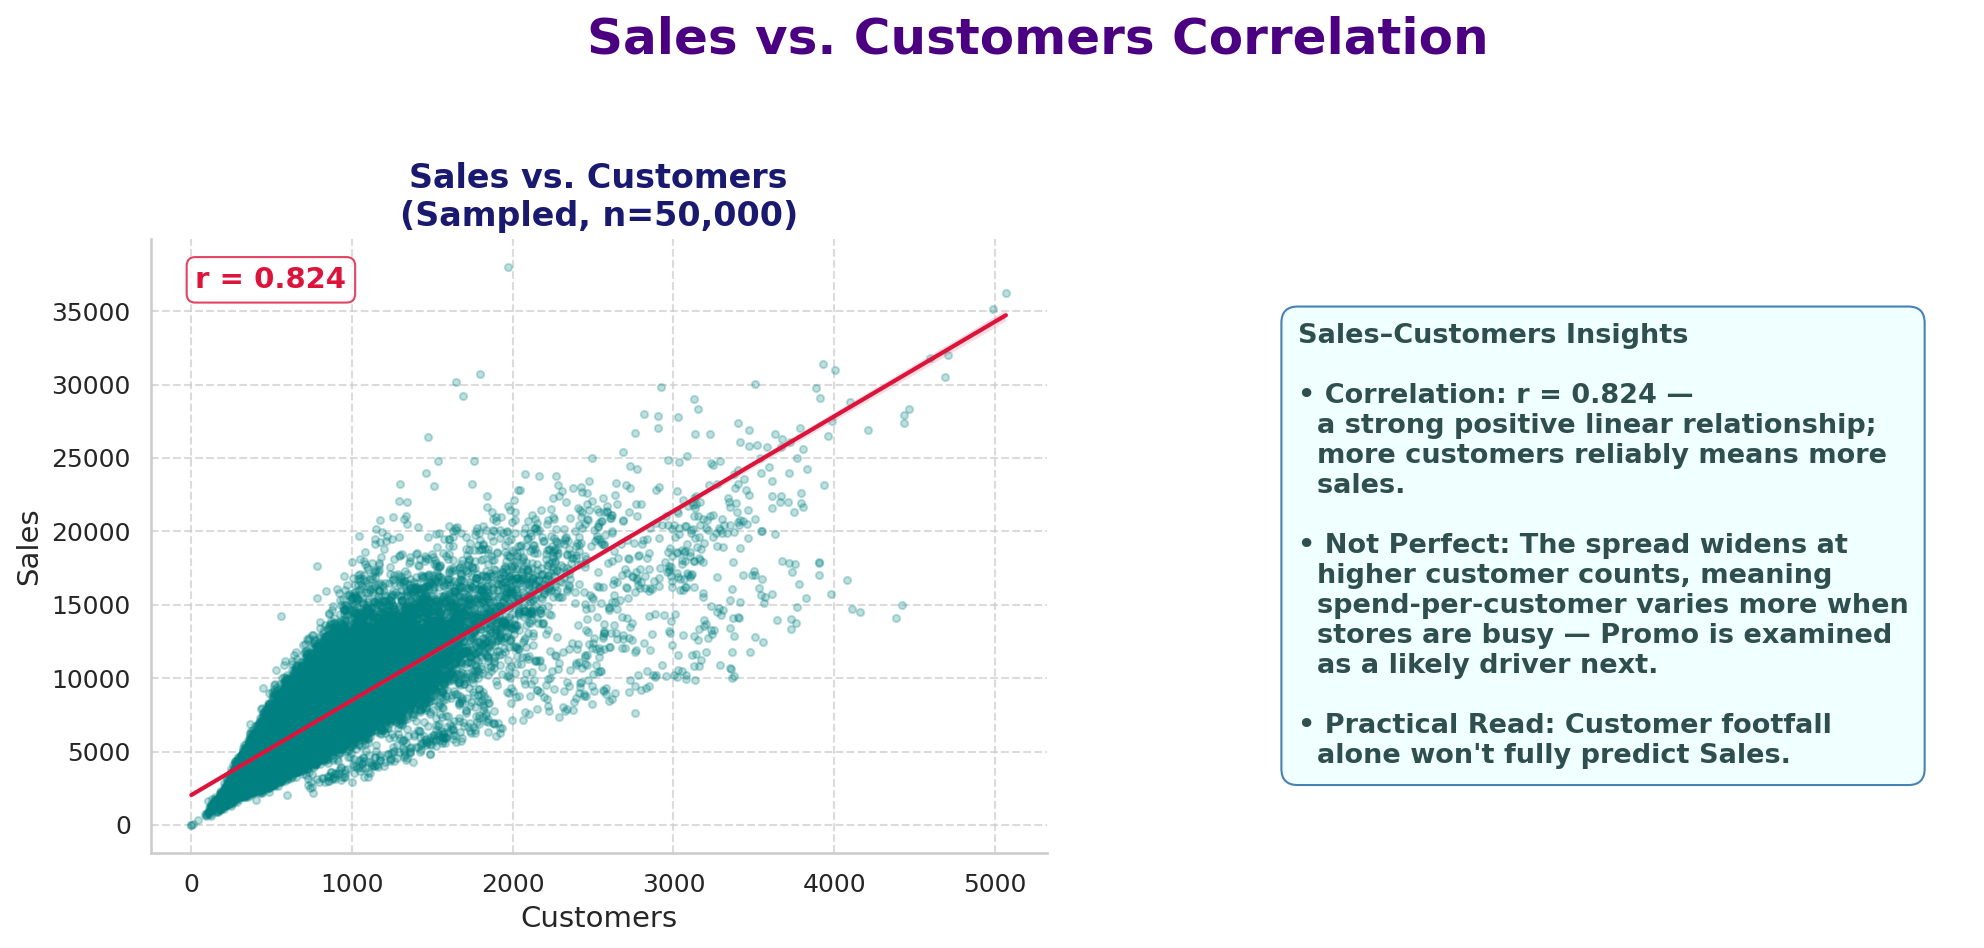

2026-09-08 17:16:57 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Sales-Customers correlation (r=0.824).


In [45]:
subsection_header("Bivariate — Sales vs. Customers Correlation")

open_train = store_train_refined[store_train_refined["Open"] == 1]
sales_customers_corr = open_train["Sales"].corr(open_train["Customers"])

SAMPLE_SIZE = 50000
sample = open_train.sample(n=SAMPLE_SIZE, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sales vs. Customers Correlation', fontsize=24, color='indigo', fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.35)

sns.regplot(
    data=sample, x="Customers", y="Sales", ax=axes[0],
    scatter_kws={"alpha": 0.25, "s": 12, "color": "teal"},
    line_kws={"color": "crimson", "linewidth": 2}
)
axes[0].set_title(f"Sales vs. Customers\n(Sampled, n={SAMPLE_SIZE:,})", fontweight='bold', fontsize=16)
axes[0].set_ylabel("Sales")
axes[0].set_xlabel("Customers")
axes[0].text(0.05, 0.92, f"r = {sales_customers_corr:.3f}", transform=axes[0].transAxes,
             fontsize=14, fontweight='bold', color='crimson',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='crimson', alpha=0.8))
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].axis('off')
insight_text = ("Sales–Customers Insights\n\n"
                f"• Correlation: r = {sales_customers_corr:.3f} —\n"
                "  a strong positive linear relationship;\n"
                "  more customers reliably means more\n"
                "  sales.\n\n"
                "• Not Perfect: The spread widens at\n"
                "  higher customer counts, meaning\n"
                "  spend-per-customer varies more when\n"
                "  stores are busy — Promo is examined\n"
                "  as a likely driver next.\n\n"
                "• Practical Read: Customer footfall\n"
                "  alone won't fully predict Sales.")
axes[1].text(0.25, 0.5, insight_text, transform=axes[1].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_sales_customers_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Bivariate analysis plotted: Sales-Customers correlation (r={sales_customers_corr:.3f}).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Sales vs. Customers Correlation:**

- Sales and Customers are strongly positively correlated (**r = 0.824**) — customer footfall is one of the most direct drivers of daily sales, as expected.
- The relationship isn't perfectly linear: variance widens at higher customer counts, meaning the same footfall doesn't always convert to the same revenue — spend-per-customer varies, likely tied to Promo status.
- Customer footfall alone won't fully explain Sales; Promo is examined as a specific driver next, and the interaction between all three (Sales, Customers, Promo) will be revisited in the Multivariate Analysis section.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Promo Effect on Sales & Customer Acquisition

<div style="margin-left: 20px; max-width: 90%">

Promotions are one of the few levers management can pull directly, so understanding their effect matters more than most other features here. This section checks whether Promo days actually drive more customers through the door, more spend per customer, or both — each still a 2-variable comparison against `Promo`, so this stays Bivariate rather than Multivariate.

</div>

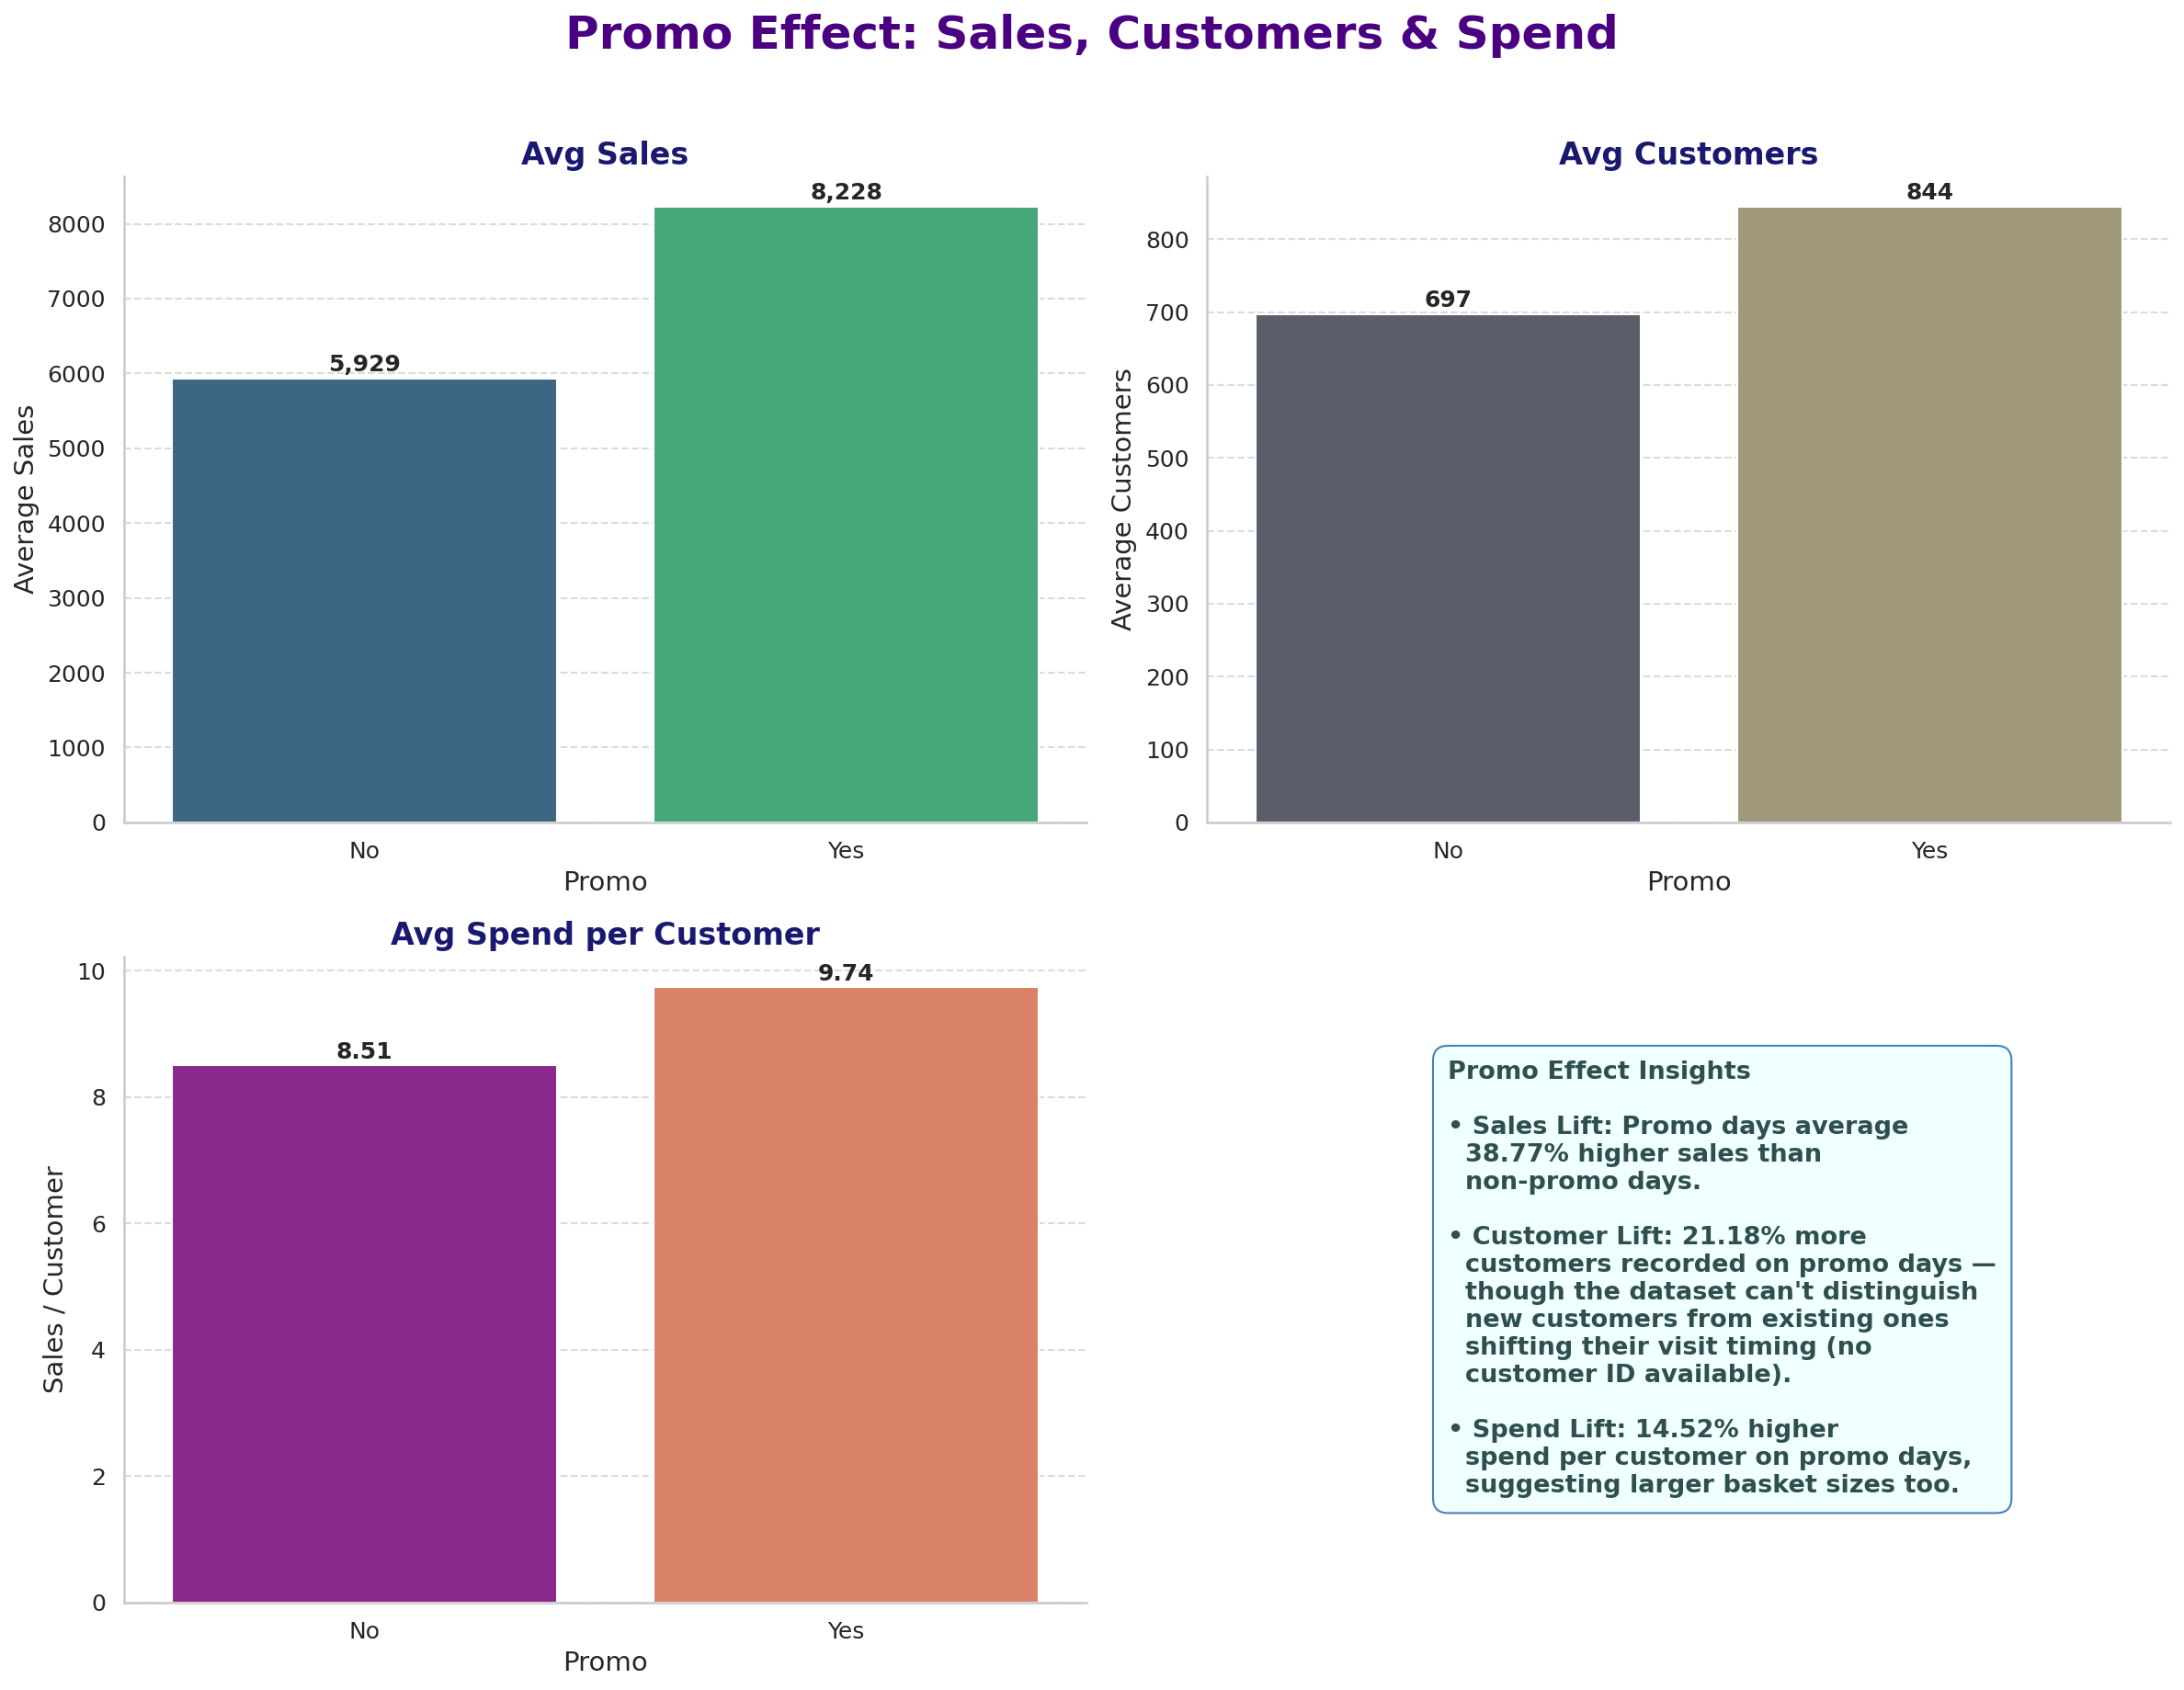

2026-09-08 17:16:59 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Promo effect on Sales/Customers (Sales lift=38.77%, Customer lift=21.18%, Spend lift=14.52%).


In [46]:
subsection_header("Bivariate — Promo Effect on Sales & Customer Acquisition")

open_train = store_train_refined[store_train_refined["Open"] == 1]

promo_sales = open_train.groupby("Promo_Label", observed=True)["Sales"].mean().reindex(["No", "Yes"])
promo_customers = open_train.groupby("Promo_Label", observed=True)["Customers"].mean().reindex(["No", "Yes"])

promo_totals = open_train.groupby("Promo_Label", observed=True)[["Sales", "Customers"]].sum()
promo_spend_per_customer = (promo_totals["Sales"] / promo_totals["Customers"]).reindex(["No", "Yes"])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Promo Effect: Sales, Customers & Spend', fontsize=24, color='indigo', fontweight='bold', y=1.02)
fig.subplots_adjust(wspace=0.3, hspace=0.4)

sns.barplot(x=promo_sales.index, y=promo_sales.values, ax=axes[0, 0], palette="viridis",
            hue=promo_sales.index, legend=False)
axes[0, 0].set_title("Avg Sales", fontweight='bold', fontsize=16)
axes[0, 0].set_ylabel("Average Sales"); axes[0, 0].set_xlabel("Promo")
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(promo_sales.values):
    axes[0, 0].text(i, v + 100, f"{v:,.0f}", ha='center', fontweight='bold')

sns.barplot(x=promo_customers.index, y=promo_customers.values, ax=axes[0, 1], palette="cividis",
            hue=promo_customers.index, legend=False)
axes[0, 1].set_title("Avg Customers", fontweight='bold', fontsize=16)
axes[0, 1].set_ylabel("Average Customers"); axes[0, 1].set_xlabel("Promo")
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(promo_customers.values):
    axes[0, 1].text(i, v + 10, f"{v:,.0f}", ha='center', fontweight='bold')

sns.barplot(x=promo_spend_per_customer.index, y=promo_spend_per_customer.values, ax=axes[1, 0], palette="plasma",
            hue=promo_spend_per_customer.index, legend=False)
axes[1, 0].set_title("Avg Spend per Customer", fontweight='bold', fontsize=16)
axes[1, 0].set_ylabel("Sales / Customer"); axes[1, 0].set_xlabel("Promo")
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(promo_spend_per_customer.values):
    axes[1, 0].text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

axes[1, 1].axis('off')
sales_lift = (promo_sales["Yes"] / promo_sales["No"] - 1) * 100
cust_lift = (promo_customers["Yes"] / promo_customers["No"] - 1) * 100
spend_lift = (promo_spend_per_customer["Yes"] / promo_spend_per_customer["No"] - 1) * 100
insight_text = ("Promo Effect Insights\n\n"
                f"• Sales Lift: Promo days average\n"
                f"  {sales_lift:.2f}% higher sales than\n"
                "  non-promo days.\n\n"
                f"• Customer Lift: {cust_lift:.2f}% more\n"
                "  customers recorded on promo days —\n"
                "  though the dataset can't distinguish\n"
                "  new customers from existing ones\n"
                "  shifting their visit timing (no\n"
                "  customer ID available).\n\n"
                f"• Spend Lift: {spend_lift:.2f}% higher\n"
                "  spend per customer on promo days,\n"
                "  suggesting larger basket sizes too.")
axes[1, 1].text(0.25, 0.5, insight_text, transform=axes[1, 1].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_promo_effect.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Bivariate analysis plotted: Promo effect on Sales/Customers (Sales lift={sales_lift:.2f}%, Customer lift={cust_lift:.2f}%, Spend lift={spend_lift:.2f}%).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Promo Effect on Sales & Customer Acquisition:**

- Promo days average **38.77%** higher sales than non-promo days — a substantial and consistent lift.
- Sales is built from Customers × Spend-per-Customer by definition, so this lift decomposes multiplicatively: **21.18%** more customers, combined with **14.52%** higher spend per customer, multiply together (1.2118 × 1.1452 ≈ 1.388) to fully account for the 38.77% overall sales lift.
- On the customer count: the dataset has no customer-level ID, so this can't distinguish genuinely new footfall from existing customers shifting their visit timing to coincide with a promo — the 21.18% figure should be read as "more recorded visits," not confirmed new-customer acquisition.
- The spend-per-customer figure doesn't share that ambiguity — it's a direct ratio of total sales to total customers, so the 14.52% increase in basket size per visit is a solid, unambiguous result.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Store Open/Close Trends

<div style="margin-left: 20px; max-width: 90%">

Since ~85% of all closures are the routine Sunday close, that comparison was almost entirely confounded with the already-established Monday effect (Seasonal analysis), not an independent finding. 

This version holds the day of week fixed at Monday and compares the *distribution* of Monday sales between stores whose preceding Sunday was open vs. closed — testing whether a closure drives pent-up demand the next day, while also checking whether the two groups are even comparable stores to begin with.

</div>

In [47]:
store_train_refined = store_train_refined.sort_values(["Store", "Date"])
store_train_refined["PrevDayOpen"] = store_train_refined.groupby("Store", observed=True)["Open"].shift(1)

monday_open = store_train_refined[
    (store_train_refined["Open"] == 1) &
    (store_train_refined["DayOfWeek"] == 1) &
    (store_train_refined["PrevDayOpen"].notna())
].copy()
monday_open["PriorSundayStatus"] = np.where(monday_open["PrevDayOpen"].astype(int) == 1, "Open", "Closed")
verification = monday_open.groupby(["PriorSundayStatus", "StoreType"], observed=True).size().unstack(fill_value=0)
centered_table(verification.reset_index())

StoreType,PriorSundayStatus,a,b,c,d
,Closed,73503,0,18458,42007
,Open,1100,2215,0,277


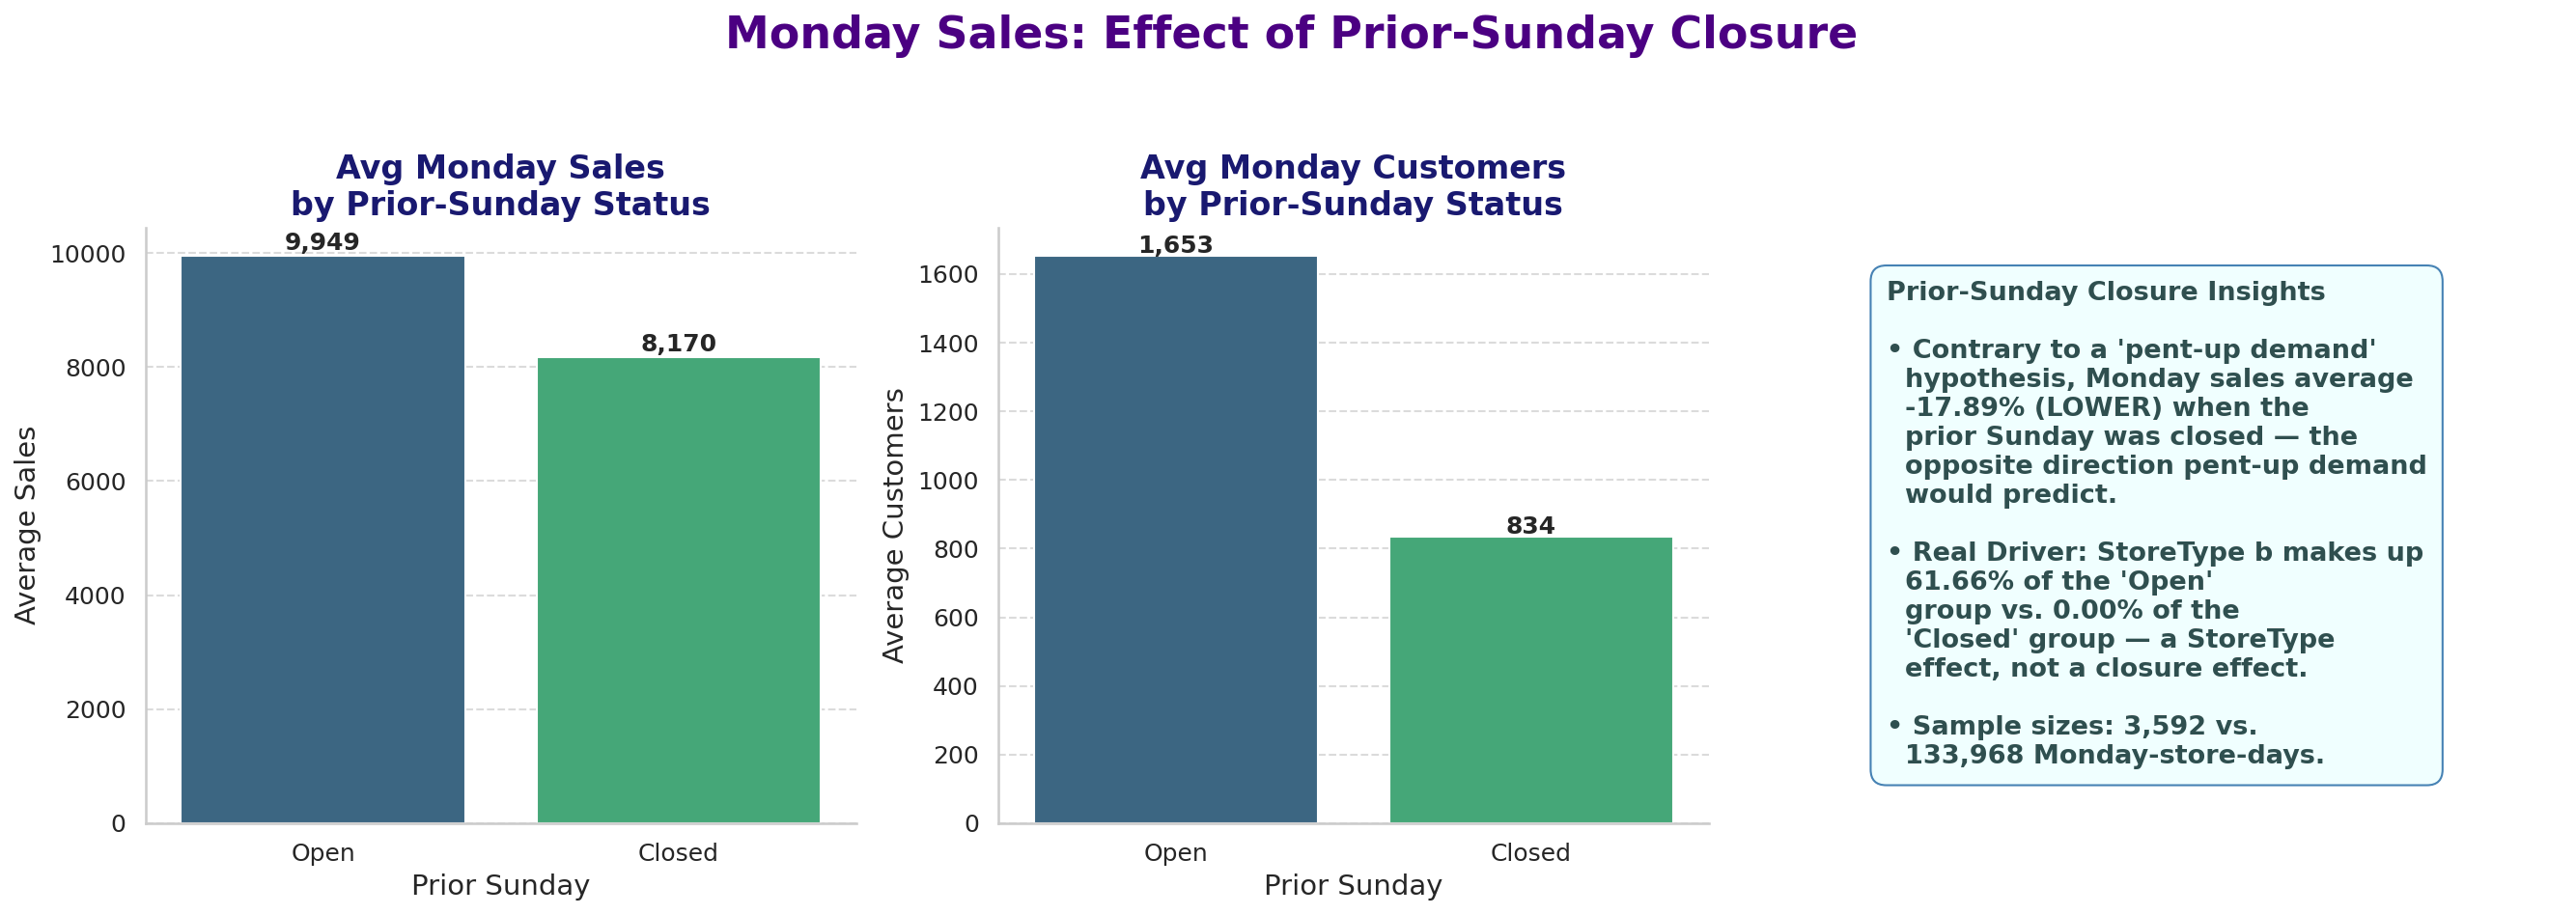

2026-09-08 17:17:00 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Monday sales/customers by prior-Sunday closure status (mean effect=-17.9%, StoreType-b share Open=61.7% vs Closed=0.0%).


In [48]:
subsection_header("Bivariate — Store Open/Close Trends")

monday_counts = monday_open.groupby("PriorSundayStatus", observed=True).size().reindex(["Open", "Closed"])
monday_sales = monday_open.groupby("PriorSundayStatus", observed=True)["Sales"].mean().reindex(["Open", "Closed"])
monday_customers = monday_open.groupby("PriorSundayStatus", observed=True)["Customers"].mean().reindex(["Open", "Closed"])

# Computed directly here — not hardcoded — what share of each group is StoreType b?
storetype_b_share = (
    monday_open.assign(IsTypeB=(monday_open["StoreType"] == "b").astype(int))
    .groupby("PriorSundayStatus", observed=True)["IsTypeB"]
    .mean().mul(100).reindex(["Open", "Closed"])
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Monday Sales: Effect of Prior-Sunday Closure', fontsize=22, color='indigo', fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.3)

sns.barplot(x=monday_sales.index, y=monday_sales.values, ax=axes[0], palette="viridis", hue=monday_sales.index, legend=False)
axes[0].set_title("Avg Monday Sales\nby Prior-Sunday Status", fontweight='bold', fontsize=16)
axes[0].set_ylabel("Average Sales"); axes[0].set_xlabel("Prior Sunday")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(monday_sales.values):
    axes[0].text(i, v + 100, f"{v:,.0f}", ha='center', fontweight='bold')

sns.barplot(x=monday_customers.index, y=monday_customers.values, ax=axes[1], palette="viridis", hue=monday_customers.index, legend=False)
axes[1].set_title("Avg Monday Customers\nby Prior-Sunday Status", fontweight='bold', fontsize=16)
axes[1].set_ylabel("Average Customers"); axes[1].set_xlabel("Prior Sunday")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(monday_customers.values):
    axes[1].text(i, v + 10, f"{v:,.0f}", ha='center', fontweight='bold')

axes[2].axis('off')
closure_lift = (monday_sales["Closed"] / monday_sales["Open"] - 1) * 100
insight_text = ("Prior-Sunday Closure Insights\n\n"
                f"• Contrary to a 'pent-up demand'\n"
                f"  hypothesis, Monday sales average\n"
                f"  {closure_lift:+.2f}% (LOWER) when the\n"
                "  prior Sunday was closed — the\n"
                "  opposite direction pent-up demand\n"
                "  would predict.\n\n"
                f"• Real Driver: StoreType b makes up\n"
                f"  {storetype_b_share['Open']:.2f}% of the 'Open'\n"
                f"  group vs. {storetype_b_share['Closed']:.2f}% of the\n"
                "  'Closed' group — a StoreType\n"
                "  effect, not a closure effect.\n\n"
                f"• Sample sizes: {monday_counts['Open']:,} vs.\n"
                f"  {monday_counts['Closed']:,} Monday-store-days.")
axes[2].text(0.05, 0.5, insight_text, transform=axes[2].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_reopen_after_closure.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Bivariate analysis plotted: Monday sales/customers by prior-Sunday closure status (mean effect={closure_lift:+.1f}%, StoreType-b share Open={storetype_b_share['Open']:.1f}% vs Closed={storetype_b_share['Closed']:.1f}%).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Store Open/Close Trends:**

- Holding day-of-week fixed at Monday, average sales are **17.89% lower** when the prior Sunday was closed (8,170) versus open (9,949) — the opposite direction a "pent-up demand" effect would predict, which rules that hypothesis out.
- The verification crosstab confirms the real driver: **StoreType b makes up 61.66% of the "Open" group and 0% of the "Closed" group** — StoreType b stores are essentially always open on Sundays. The apparent "closure effect" is a StoreType-b effect, not stores selling more because Sunday closure built up demand.
- Useful for feature engineering: `StoreType` (and a derived "always-open" flag) is likely a more informative predictor here than any closure-proximity feature.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Weekday-Open Stores & Weekend Effect

<div style="margin-left: 20px; max-width: 90%">

Some stores maintain a strict "open every regular weekday" policy, never closing on an ordinary (non-holiday) Monday-Friday. This section checks whether that policy correlates with stronger or weaker Saturday performance — not just total sales, but customer footfall and spend-per-customer separately, since a sales difference could come from either one, or from one masking the other. Saturday is used here rather than Sunday, since Sunday-specific dynamics — and the store-selection caveat that comes with them — were already covered in the prior section.

</div>

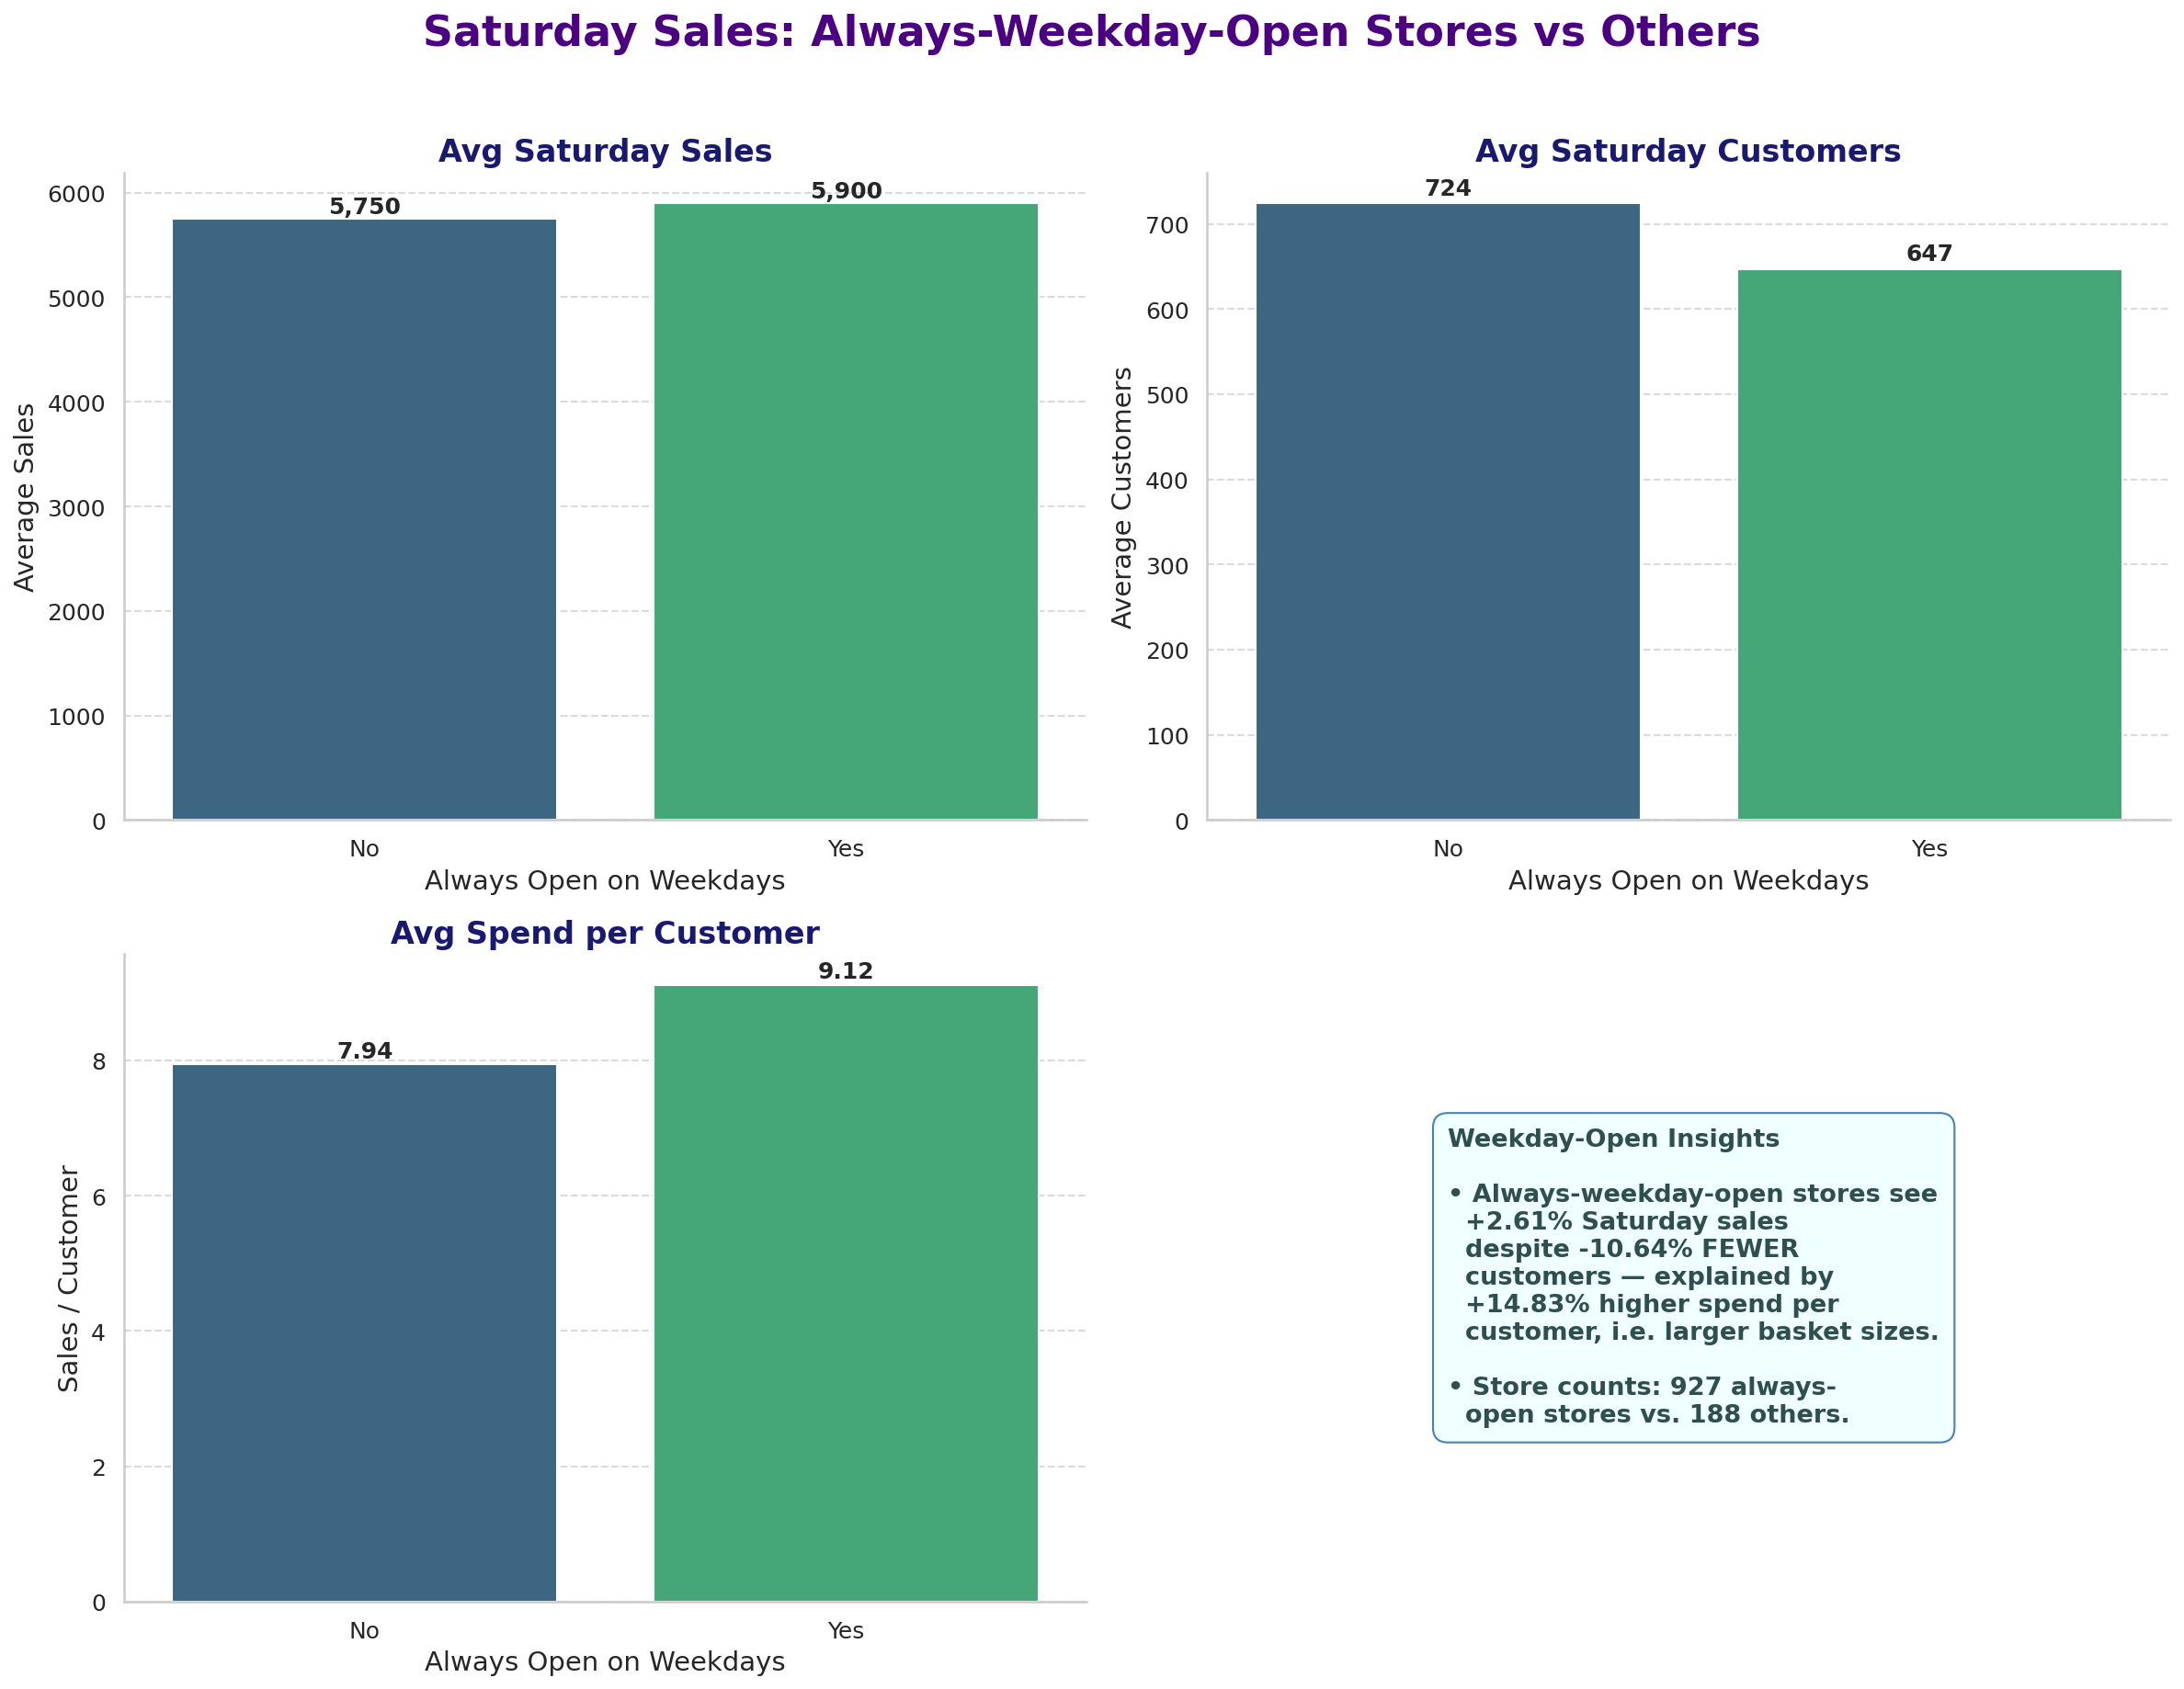

2026-09-08 17:17:02 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Saturday sales/customers/spend by always-weekday-open status (sales gap=+2.61%, customer gap=-10.64%, spend gap=+14.83%).


In [49]:
subsection_header("Bivariate — Weekday-Open Stores & Weekend Effect")

regular_weekday = store_train_refined[
    (store_train_refined["DayOfWeek"].isin([1, 2, 3, 4, 5])) &
    (store_train_refined["StateHoliday_Label"] == "None")
]
store_weekday_open_rate = regular_weekday.groupby("Store", observed=True)["Open"].apply(lambda s: s.astype(int).min())
always_weekday_open_stores = store_weekday_open_rate[store_weekday_open_rate == 1].index

store_train_refined["AlwaysWeekdayOpen"] = np.where(
    store_train_refined["Store"].isin(always_weekday_open_stores), "Yes", "No"
)

saturday_open = store_train_refined[
    (store_train_refined["DayOfWeek"] == 6) & (store_train_refined["Open"] == 1)
].copy()

sat_counts = saturday_open.groupby("AlwaysWeekdayOpen", observed=True)["Store"].nunique().reindex(["No", "Yes"])
sat_sales = saturday_open.groupby("AlwaysWeekdayOpen", observed=True)["Sales"].mean().reindex(["No", "Yes"])
sat_customers = saturday_open.groupby("AlwaysWeekdayOpen", observed=True)["Customers"].mean().reindex(["No", "Yes"])
sat_totals = saturday_open.groupby("AlwaysWeekdayOpen", observed=True)[["Sales", "Customers"]].sum()
sat_spend_per_customer = (sat_totals["Sales"] / sat_totals["Customers"]).reindex(["No", "Yes"])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Saturday Sales: Always-Weekday-Open Stores vs Others', fontsize=22, color='indigo', fontweight='bold', y=1.02)
fig.subplots_adjust(wspace=0.3, hspace=0.4)

sns.barplot(x=sat_sales.index, y=sat_sales.values, ax=axes[0, 0], palette="viridis", hue=sat_sales.index, legend=False)
axes[0, 0].set_title("Avg Saturday Sales", fontweight='bold', fontsize=16)
axes[0, 0].set_ylabel("Average Sales"); axes[0, 0].set_xlabel("Always Open on Weekdays")
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(sat_sales.values):
    axes[0, 0].text(i, v + 50, f"{v:,.0f}", ha='center', fontweight='bold')

sns.barplot(x=sat_customers.index, y=sat_customers.values, ax=axes[0, 1], palette="viridis", hue=sat_customers.index, legend=False)
axes[0, 1].set_title("Avg Saturday Customers", fontweight='bold', fontsize=16)
axes[0, 1].set_ylabel("Average Customers"); axes[0, 1].set_xlabel("Always Open on Weekdays")
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(sat_customers.values):
    axes[0, 1].text(i, v + 10, f"{v:,.0f}", ha='center', fontweight='bold')

sns.barplot(x=sat_spend_per_customer.index, y=sat_spend_per_customer.values, ax=axes[1, 0], palette="viridis", hue=sat_spend_per_customer.index, legend=False)
axes[1, 0].set_title("Avg Spend per Customer", fontweight='bold', fontsize=16)
axes[1, 0].set_ylabel("Sales / Customer"); axes[1, 0].set_xlabel("Always Open on Weekdays")
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(sat_spend_per_customer.values):
    axes[1, 0].text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

axes[1, 1].axis('off')
sales_gap = (sat_sales["Yes"] / sat_sales["No"] - 1) * 100
cust_gap = (sat_customers["Yes"] / sat_customers["No"] - 1) * 100
spend_gap = (sat_spend_per_customer["Yes"] / sat_spend_per_customer["No"] - 1) * 100
insight_text = ("Weekday-Open Insights\n\n"
                f"• Always-weekday-open stores see\n"
                f"  {sales_gap:+.2f}% Saturday sales\n"
                f"  despite {cust_gap:+.2f}% FEWER\n"
                "  customers — explained by\n"
                f"  {spend_gap:+.2f}% higher spend per\n"
                "  customer, i.e. larger basket sizes.\n\n"
                f"• Store counts: {sat_counts['Yes']:,} always-\n"
                f"  open stores vs. {sat_counts['No']:,} others.")
axes[1, 1].text(0.25, 0.5, insight_text, transform=axes[1, 1].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_weekday_open_weekend_effect.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Bivariate analysis plotted: Saturday sales/customers/spend by always-weekday-open status (sales gap={sales_gap:+.2f}%, customer gap={cust_gap:+.2f}%, spend gap={spend_gap:+.2f}%).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Weekday-Open Stores & Weekend Effect:**

- Stores that never close on a regular weekday post **+2.61%** higher Saturday sales (5,900 vs. 5,750) than stores that do close on some weekdays.
- That's despite seeing **-10.64%** fewer Saturday customers (647 vs. 724) — the sales gap isn't about footfall.
- It's fully explained by spend per customer: always-weekday-open stores post **+14.83%** higher spend per customer (9.12 vs. 7.94) — meaningfully larger baskets on Saturday.
- Practical read: a strict "never close on a weekday" policy correlates with a different, likely more loyal or bulk-shopping customer base on Saturdays — not simply more foot traffic, and worth keeping distinct from the footfall-driven Promo effect seen earlier.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Assortment Impact

<div style="margin-left: 20px; max-width: 90%">

Assortment level (`a` = basic, `b` = extra, `c` = extended) describes how broad a store's product range is. This section checks whether a wider assortment translates into higher sales — and, following the same decomposition used for Promo and Weekday-Open, whether that comes from more customers, higher spend per customer, or both. Store counts per level are shown alongside the result, since assortment types are known to be unevenly distributed across stores.

</div>

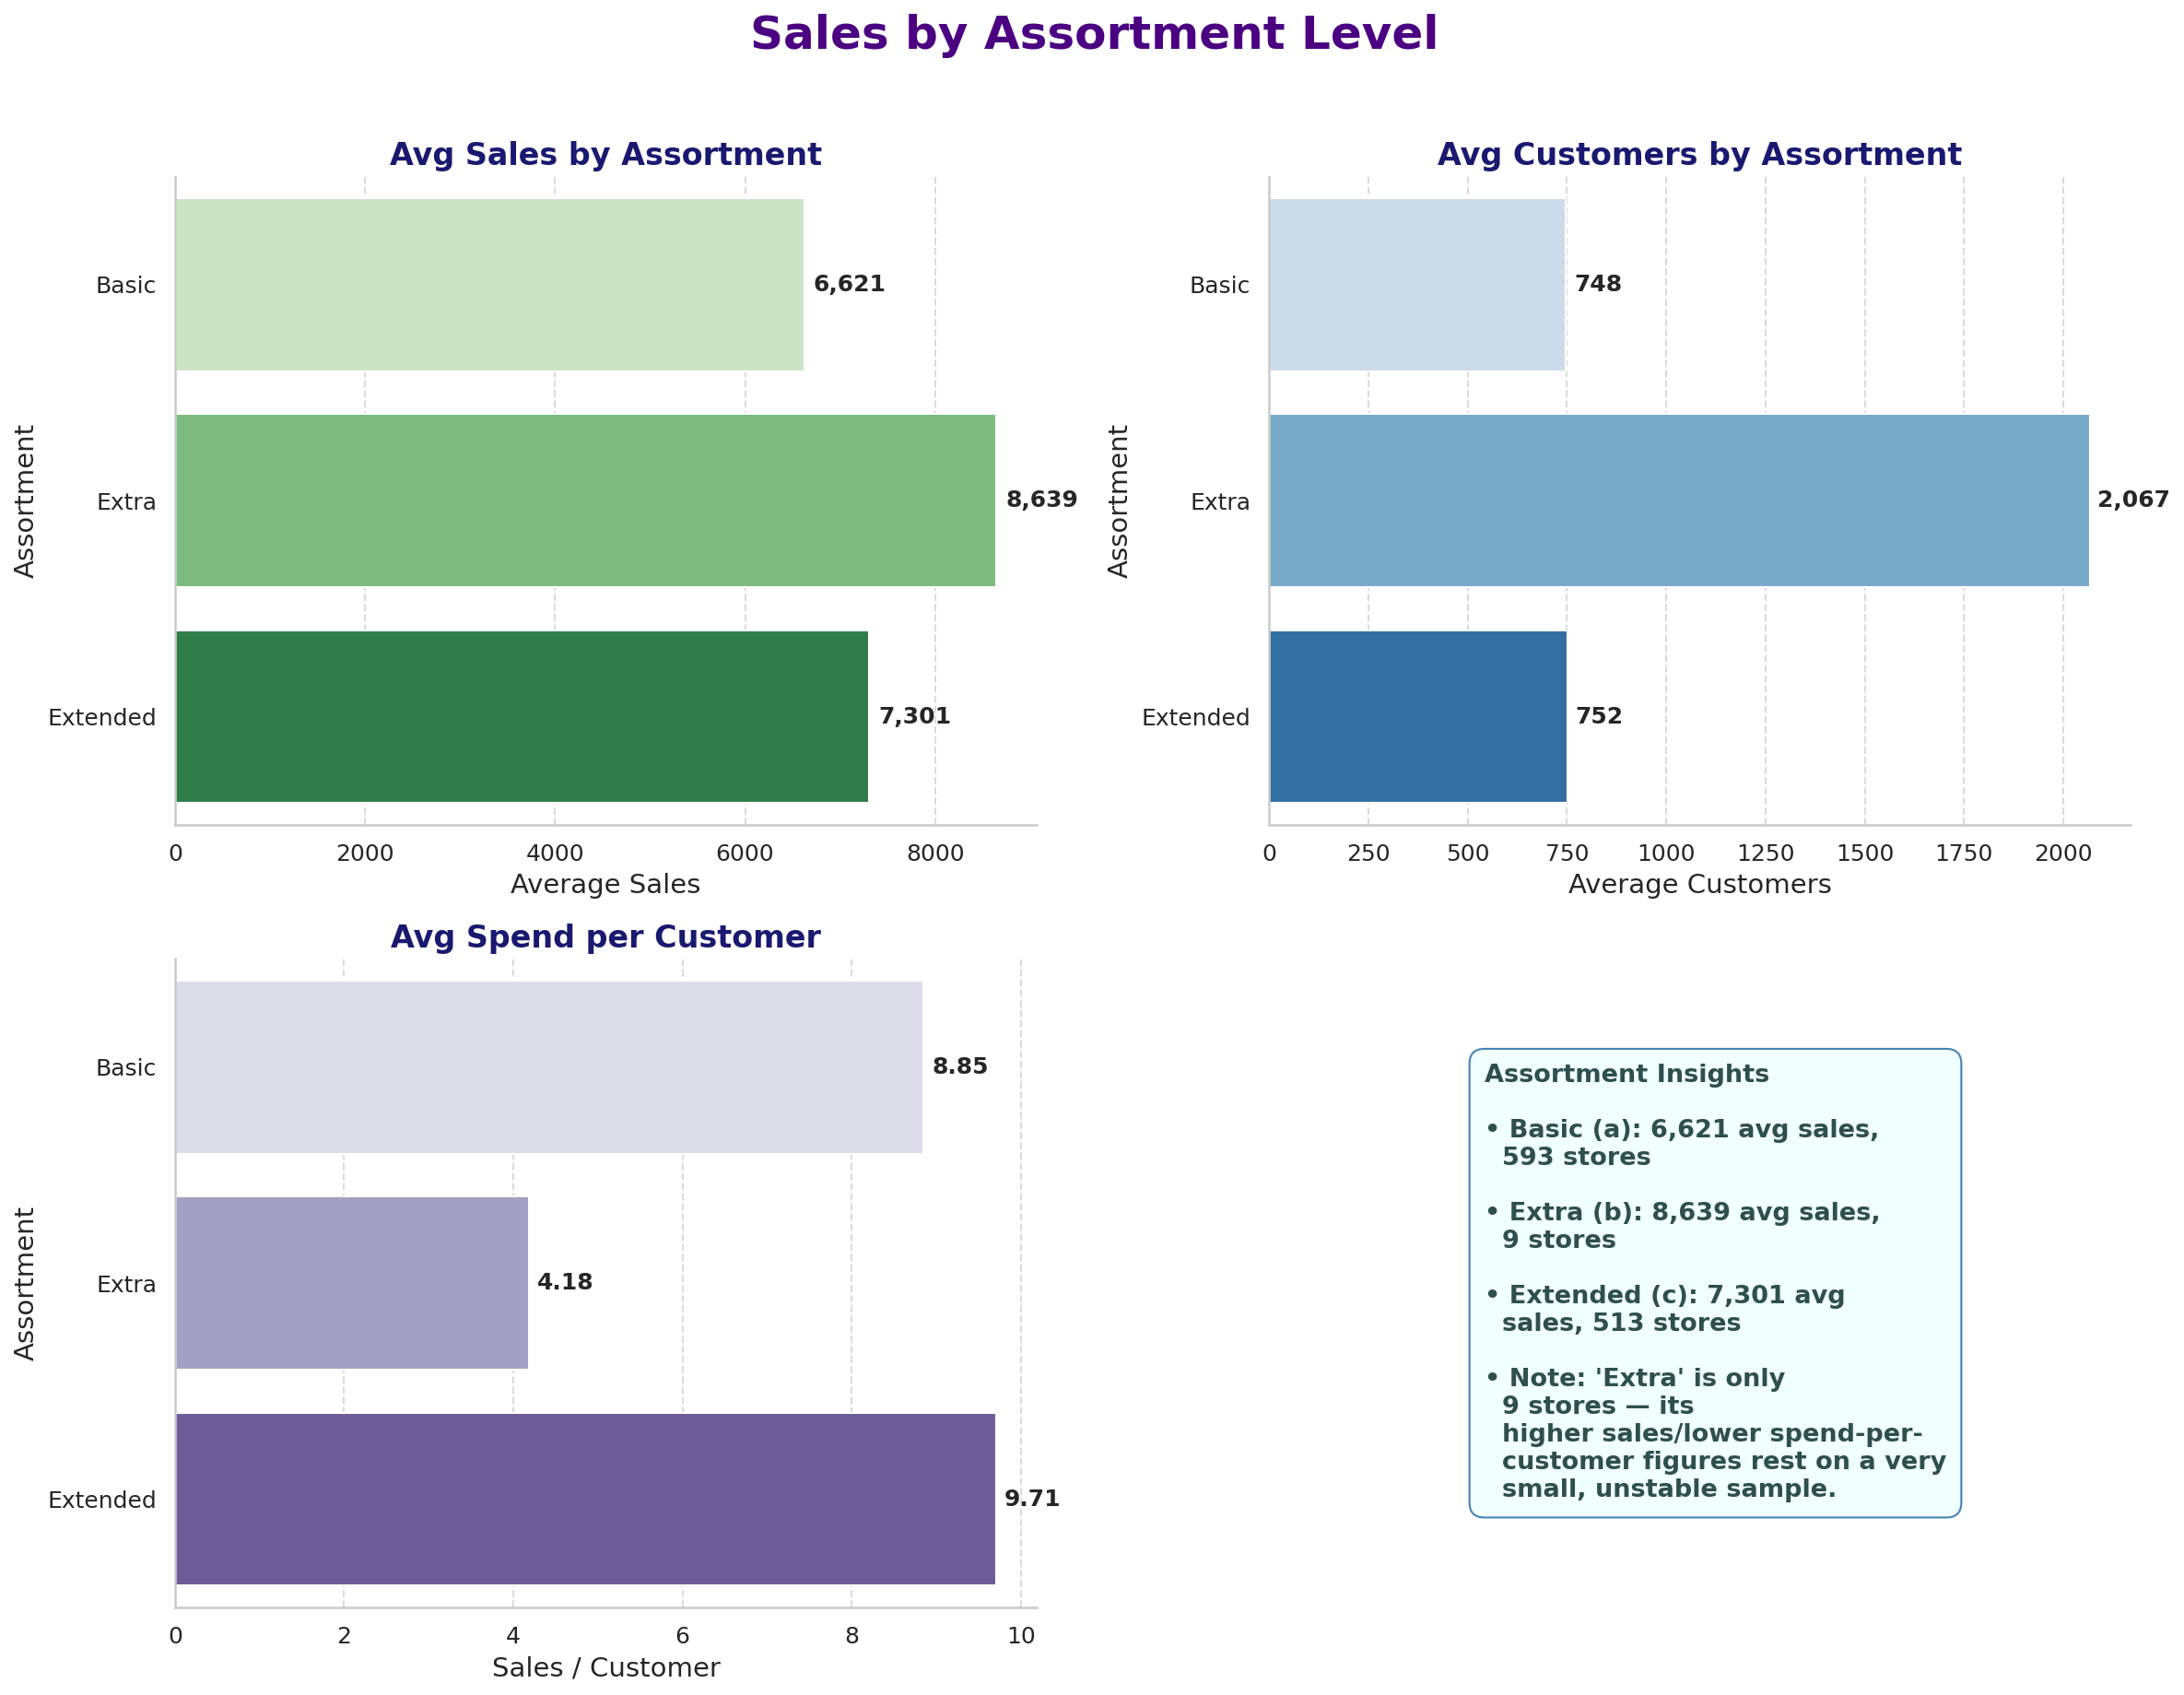

2026-09-08 17:17:03 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Sales/Customers/Spend-per-customer by Assortment_Label (Extra assortment n=9 stores, small-sample caution).


In [50]:
subsection_header("Bivariate — Assortment Impact")

open_train = store_train_refined[store_train_refined["Open"] == 1]

assortment_order = ["Basic", "Extra", "Extended"]
assortment_sales = open_train.groupby("Assortment_Label", observed=True)["Sales"].mean().reindex(assortment_order)
assortment_customers = open_train.groupby("Assortment_Label", observed=True)["Customers"].mean().reindex(assortment_order)
assortment_totals = open_train.groupby("Assortment_Label", observed=True)[["Sales", "Customers"]].sum()
assortment_spend_per_customer = (assortment_totals["Sales"] / assortment_totals["Customers"]).reindex(assortment_order)
assortment_store_counts = open_train.groupby("Assortment_Label", observed=True)["Store"].nunique().reindex(assortment_order)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales by Assortment Level', fontsize=24, color='indigo', fontweight='bold', y=1.02)
fig.subplots_adjust(wspace=0.35, hspace=0.4)

sns.barplot(x=assortment_sales.values, y=assortment_sales.index, ax=axes[0, 0], palette="Greens", hue=assortment_sales.index, legend=False, orient='h')
axes[0, 0].set_title("Avg Sales by Assortment", fontweight='bold', fontsize=16)
axes[0, 0].set_xlabel("Average Sales"); axes[0, 0].set_ylabel("Assortment")
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(assortment_sales.values):
    axes[0, 0].text(v + 100, i, f"{v:,.0f}", va='center', fontweight='bold')

sns.barplot(x=assortment_customers.values, y=assortment_customers.index, ax=axes[0, 1], palette="Blues", hue=assortment_customers.index, legend=False, orient='h')
axes[0, 1].set_title("Avg Customers by Assortment", fontweight='bold', fontsize=16)
axes[0, 1].set_xlabel("Average Customers"); axes[0, 1].set_ylabel("Assortment")
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(assortment_customers.values):
    axes[0, 1].text(v + 20, i, f"{v:,.0f}", va='center', fontweight='bold')

sns.barplot(x=assortment_spend_per_customer.values, y=assortment_spend_per_customer.index, ax=axes[1, 0], palette="Purples", hue=assortment_spend_per_customer.index, legend=False, orient='h')
axes[1, 0].set_title("Avg Spend per Customer", fontweight='bold', fontsize=16)
axes[1, 0].set_xlabel("Sales / Customer"); axes[1, 0].set_ylabel("Assortment")
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(assortment_spend_per_customer.values):
    axes[1, 0].text(v + 0.1, i, f"{v:.2f}", va='center', fontweight='bold')

axes[1, 1].axis('off')
insight_text = ("Assortment Insights\n\n"
                f"• Basic (a): {assortment_sales['Basic']:,.0f} avg sales,\n"
                f"  {assortment_store_counts['Basic']:,} stores\n\n"
                f"• Extra (b): {assortment_sales['Extra']:,.0f} avg sales,\n"
                f"  {assortment_store_counts['Extra']:,} stores\n\n"
                f"• Extended (c): {assortment_sales['Extended']:,.0f} avg\n"
                f"  sales, {assortment_store_counts['Extended']:,} stores\n\n"
                f"• Note: 'Extra' is only\n"
                f"  {assortment_store_counts['Extra']:,} stores — its\n"
                "  higher sales/lower spend-per-\n"
                "  customer figures rest on a very\n"
                "  small, unstable sample.")
axes[1, 1].text(0.25, 0.5, insight_text, transform=axes[1, 1].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_assortment_impact.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Bivariate analysis plotted: Sales/Customers/Spend-per-customer by Assortment_Label (Extra assortment n={assortment_store_counts['Extra']} stores, small-sample caution).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Assortment Impact:**

- Basic and Extended are the two well-represented levels (593 and 513 stores). Extended sees ~10% higher sales than Basic (7,301 vs. 6,621), and that gap comes almost entirely from spend per customer (9.71 vs. 8.85) rather than footfall (customer counts are nearly identical: 752 vs. 748).
- Extra assortment shows the highest raw average sales (8,639) and by far the most customers (2,067) — but this rests on just **9 stores**, an extremely small sample, likely smaller than any group examined so far in this notebook. Its unusually low spend-per-customer (4.18) is also a symptom of that instability, not a reliable pattern. This result should not be read as "Extra assortment drives more sales."
- Practical read: Assortment's genuine effect is best judged from Basic vs. Extended; Extra needs an explicit small-sample caveat (or exclusion) in any downstream modeling step that treats it as informative.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Competition Distance Impact

<div style="margin-left: 20px; max-width: 90%">

Does having a competitor next door hurt sales, or does it simply indicate a high-traffic commercial zone? While the overall linear correlation between competition distance and sales is notoriously weak, breaking the distances down into human-readable geographic brackets (0-1km, 1-3km, etc.) reveals the underlying non-linear relationship.

</div>

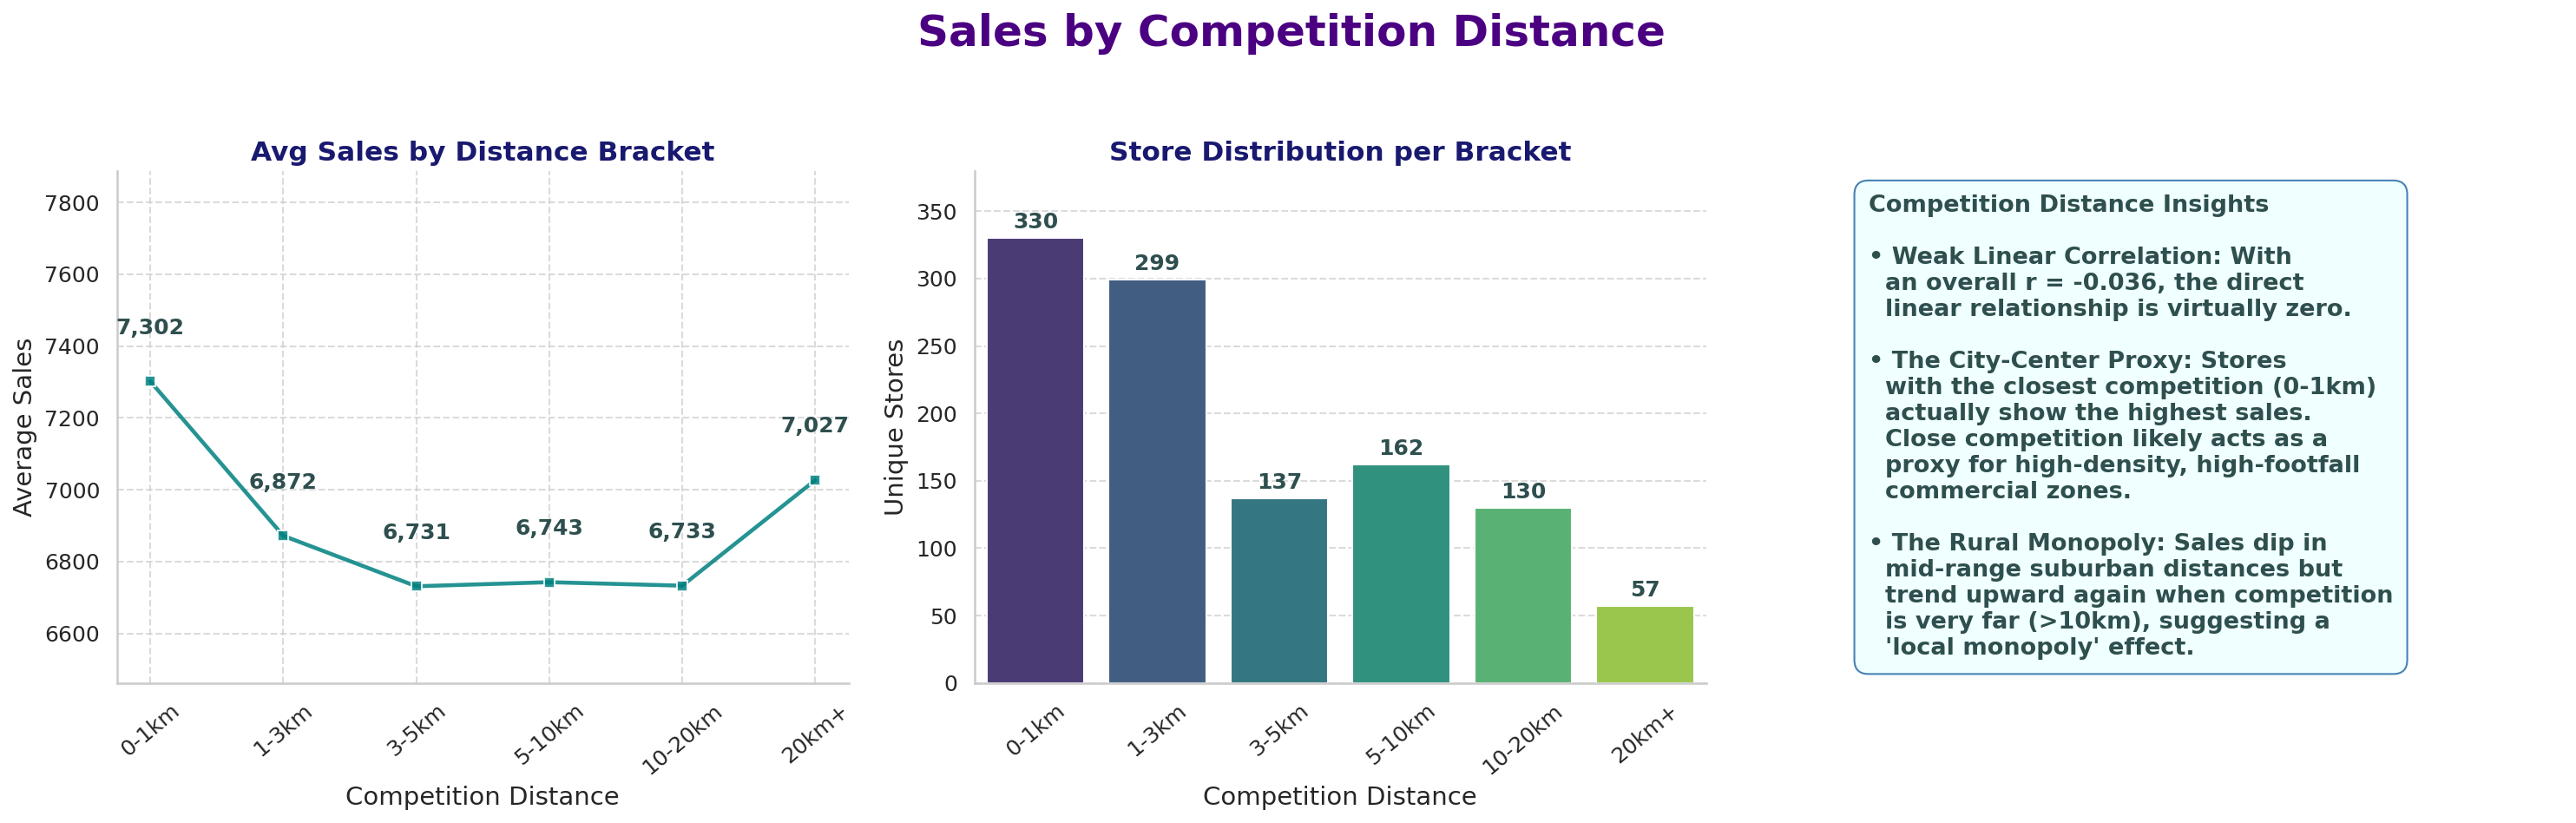

2026-09-08 17:17:05 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Sales by explicit geographic distance bracket (correlation r=-0.036).


In [51]:
subsection_header("Bivariate — Competition Distance Impact")

open_train = store_train_refined[store_train_refined["Open"] == 1]
open_train_dist = open_train.dropna(subset=["CompetitionDistance"]).copy()

# Fix: Replace qcut (quantiles) with cut (explicit, logical bins)
bins = [0, 1000, 3000, 5000, 10000, 20000, 100000]
bin_labels = ["0-1km", "1-3km", "3-5km", "5-10km", "10-20km", "20km+"]
open_train_dist["DistanceBin"] = pd.cut(open_train_dist["CompetitionDistance"], bins=bins, labels=bin_labels, include_lowest=True)

distance_sales = open_train_dist.groupby("DistanceBin", observed=True)["Sales"].mean().reindex(bin_labels)
distance_counts = open_train_dist.groupby("DistanceBin", observed=True)["Store"].nunique().reindex(bin_labels)
distance_corr = open_train_dist["CompetitionDistance"].corr(open_train_dist["Sales"])

# 1x3 Grid: 2 plots, 1 text box
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Sales by Competition Distance', fontsize=24, color='indigo', fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.35)

# Plot 1: Avg Sales by explicit bin
axes[0].plot(bin_labels, distance_sales.values, marker='s', color='teal', linewidth=2.2, alpha=0.85, markeredgecolor='white')
axes[0].set_title("Avg Sales by Distance Bracket", fontweight='bold', fontsize=15)
axes[0].set_ylabel("Average Sales") 
axes[0].set_xlabel("Competition Distance")
axes[0].tick_params(axis='x', rotation=40)
axes[0].grid(True, linestyle='--', alpha=0.7)
# Add data labels to the line plot
for i, val in enumerate(distance_sales.values):
    axes[0].text(i, val + 120, f'{val:,.0f}', ha='center', va='bottom', fontweight='bold', color='darkslategray')
axes[0].set_ylim(distance_sales.min() * 0.96, distance_sales.max() * 1.08)
# Plot 2: Store Count per bin to provide context for the averages
sns.barplot(
    x=bin_labels, 
    y=distance_counts.values, 
    ax=axes[1], 
    palette="viridis", 
    hue=bin_labels, 
    legend=False
)
axes[1].set_title("Store Distribution per Bracket", fontweight='bold', fontsize=15)
axes[1].set_ylabel("Unique Stores") 
axes[1].set_xlabel("Competition Distance")
axes[1].tick_params(axis='x', rotation=40)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
# Add data labels to the bar plot
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=3, fontweight='bold', color='darkslategray')
axes[1].set_ylim(0, distance_counts.max() * 1.15)
# Plot 3: Updated Insights
axes[2].axis('off')
insight_text = ("Competition Distance Insights\n\n"
                f"• Weak Linear Correlation: With\n"
                f"  an overall r = {distance_corr:.3f}, the direct\n"
                "  linear relationship is virtually zero.\n\n"
                "• The City-Center Proxy: Stores\n"
                "  with the closest competition (0-1km)\n"
                "  actually show the highest sales. \n"
                "  Close competition likely acts as a\n"
                "  proxy for high-density, high-footfall\n"
                "  commercial zones.\n\n"
                "• The Rural Monopoly: Sales dip in\n"
                "  mid-range suburban distances but\n"
                "  trend upward again when competition\n"
                "  is very far (>10km), suggesting a\n"
                "  'local monopoly' effect.")

axes[2].text(0.05, 0.5, insight_text, transform=axes[2].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_competition_distance_impact.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Bivariate analysis plotted: Sales by explicit geographic distance bracket (correlation r={distance_corr:.3f}).")

In [52]:
storetype_by_bracket = pd.crosstab(open_train_dist["DistanceBin"], open_train_dist["StoreType"])
centered_table(storetype_by_bracket.reset_index())

StoreType,DistanceBin,a,b,c,d
,0-1km,168621,8075,41720,32543
,1-3km,122849,6556,29845,65013
,3-5km,49912,932,23101,30703
,5-10km,42219,0,9989,69703
,10-20km,44226,0,4578,49215
,20km+,29250,0,3745,11597


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Competition Distance Impact:**

- The 0-1km bracket is both the largest segment of the network (330 stores) and the highest-selling (7,302 avg). Moving to 1-3km (299 stores) drops sales by nearly 6% (6,872). This is more consistent with close competition acting as a proxy for high-density, high-footfall commercial areas than with competition directly diluting revenue — but the dataset has no city/location field, so this explanation can't be confirmed directly and should be treated as a hypothesis, not a finding.
- The mid-range brackets (3-5km, 5-10km, 10-20km — 429 stores combined) show flat, lower sales (6,731-6,743). Framing these as "suburban/residential" is a plausible read but, again, isn't something the data can verify without a location field.
- Beyond 20km, sales recover to 7,027, though on a notably smaller sample (57 stores vs. 330 in the closest bracket). A "local monopoly" story is plausible, but the smaller n means this uptick deserves more caution than the two larger brackets.
- The overall linear correlation is misleadingly close to zero (r = -0.036) precisely because the true relationship is U-shaped, not linear — a useful modeling implication: linear models will likely miss this pattern entirely without geographic binning or a tree-based approach that can split non-linearly.
- **Checked**: StoreType composition shifts sharply across distance brackets, and it tracks the U-shape closely. StoreType a makes up 67.2% of the 0-1km bracket and 65.6% of the 20km+ bracket (the two highest-selling brackets), but only 34.6-47.7% of the mid-range brackets. StoreType d shows roughly the opposite pattern (50-57% in the low-selling mid-range brackets, 13-29% at the extremes). This doesn't prove distance has no effect, but it does mean StoreType is a real confound sitting underneath this U-shape, not just a hypothetical one — a StoreType-adjusted comparison would be needed before treating raw `CompetitionDistance` as a trustworthy standalone predictor.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — New/Reopened Competitor Impact

<div style="margin-left: 20px; max-width: 90%">

Unlike the previous section, which compared *different* stores at different competitor distances, this section tracks the *same* store across time, before and after its nearest competitor actually opens — using `CompetitionOpenSinceYear`/`CompetitionOpenSinceMonth` to identify stores whose competitor's entry falls inside the observed date range. Holding the store constant gives a cleaner read on whether a new competitor visibly affects sales than the cross-store distance comparison could, and directly answers the brief's question about opening/reopening effects.

</div>

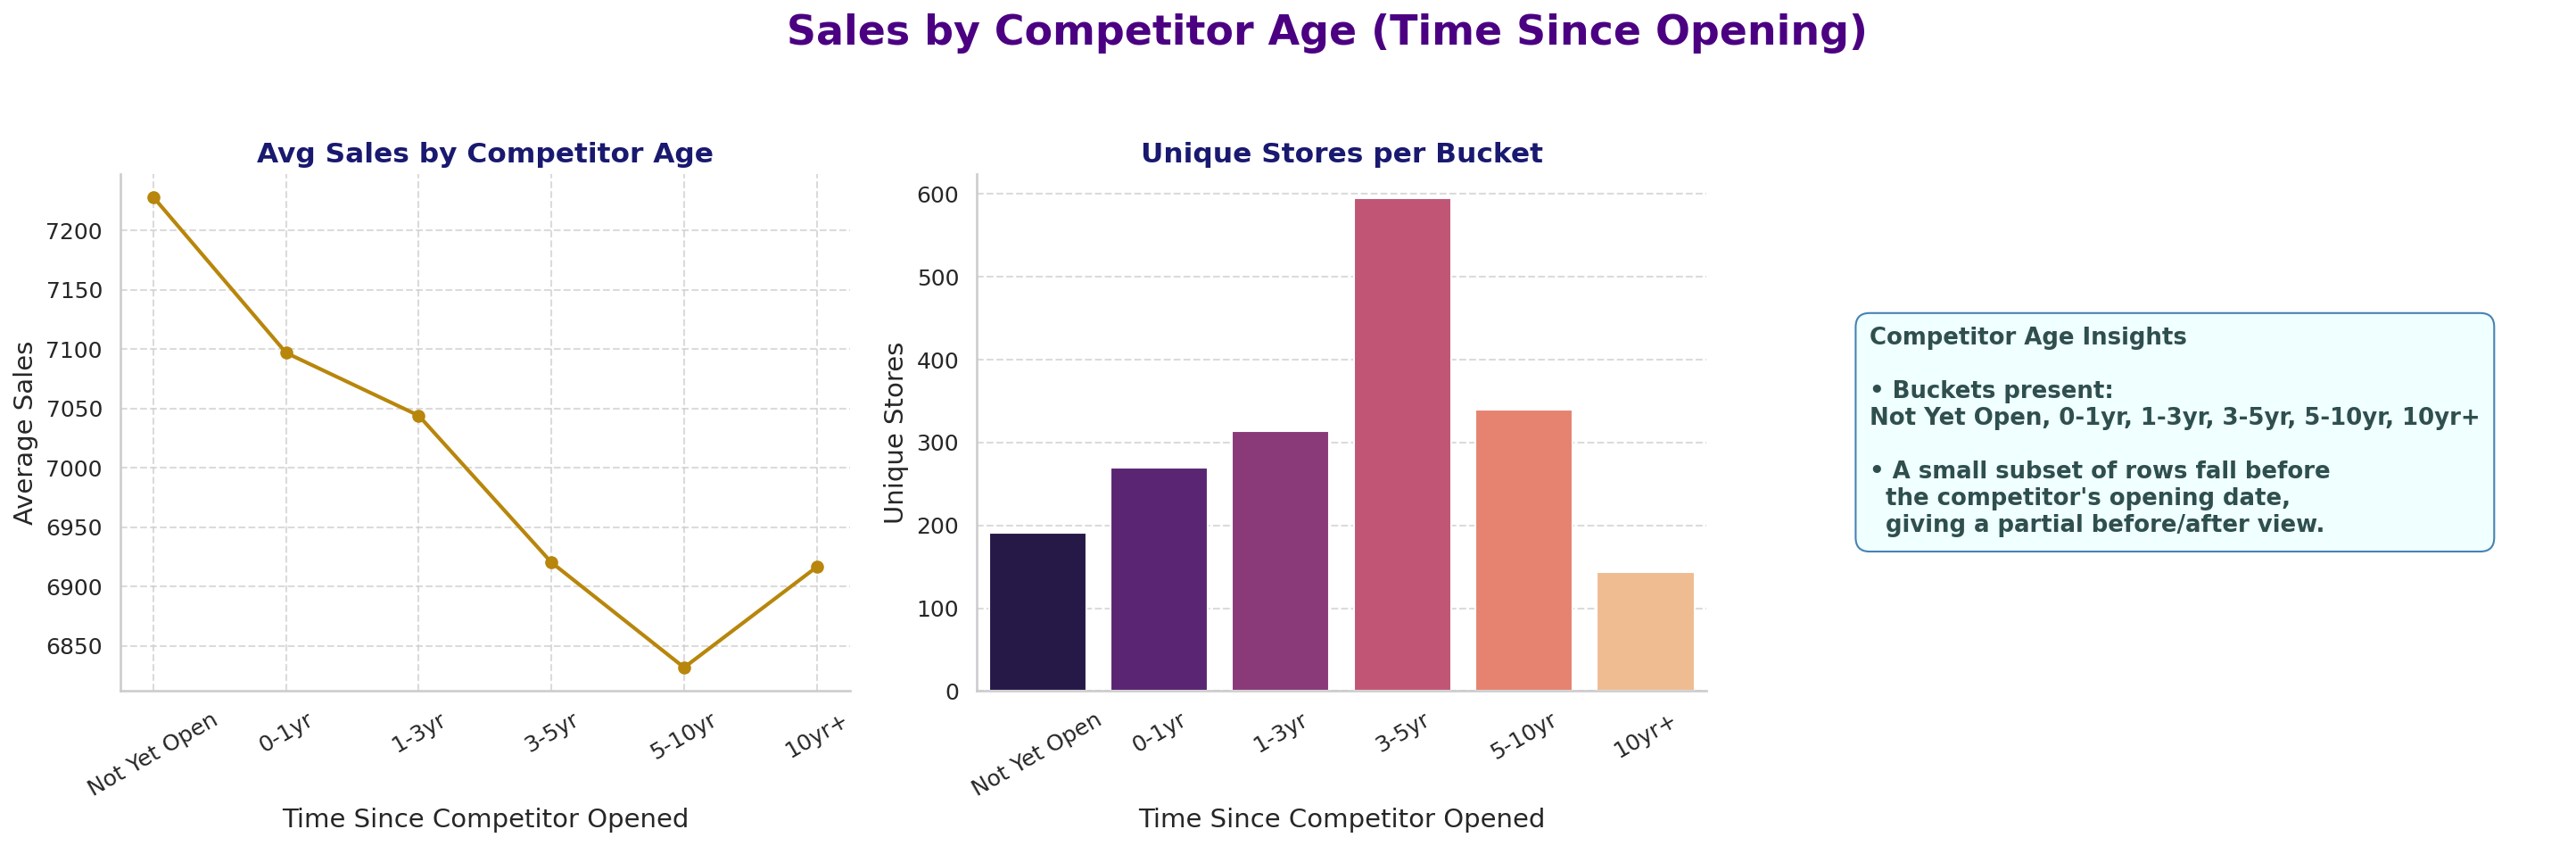

2026-09-08 17:17:06 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Sales by competitor age bucket (time since competitor opened).


In [53]:
subsection_header("Bivariate — New/Reopened Competitor Impact")

open_train = store_train_refined[store_train_refined["Open"] == 1].copy()
comp_known = open_train.dropna(subset=["CompetitionOpen_Duration_Months"]).copy()

bins = [-np.inf, 0, 12, 36, 60, 120, np.inf]
bin_labels = ["Not Yet Open", "0-1yr", "1-3yr", "3-5yr", "5-10yr", "10yr+"]
comp_known["CompetitorAgeBucket"] = pd.cut(
    comp_known["CompetitionOpen_Duration_Months"], bins=bins, labels=bin_labels
)

bucket_sales = comp_known.groupby("CompetitorAgeBucket", observed=True)["Sales"].mean().reindex(bin_labels)
bucket_counts = comp_known.groupby("CompetitorAgeBucket", observed=True)["Store"].nunique().reindex(bin_labels)

valid_buckets = bucket_counts[bucket_counts > 0].index
bucket_sales = bucket_sales.reindex(valid_buckets)
bucket_counts = bucket_counts.reindex(valid_buckets)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Sales by Competitor Age (Time Since Opening)', fontsize=22, color='indigo', fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.35)

axes[0].plot(bucket_sales.index, bucket_sales.values, marker='o', color='darkgoldenrod', linewidth=2)
axes[0].set_title("Avg Sales by Competitor Age", fontweight='bold', fontsize=15)
axes[0].set_ylabel("Average Sales"); axes[0].set_xlabel("Time Since Competitor Opened")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, linestyle='--', alpha=0.7)


sns.barplot(x=bucket_counts.index, y=bucket_counts.values, ax=axes[1],palette="magma", hue=bucket_counts.index, legend=False)
axes[1].set_title("Unique Stores per Bucket", fontweight='bold', fontsize=15)
axes[1].set_ylabel("Unique Stores"); axes[1].set_xlabel("Time Since Competitor Opened")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

axes[2].axis('off')
if "Not Yet Open" in valid_buckets:
    availability_note = ("A small subset of rows fall before\n"
                          "  the competitor's opening date,\n"
                          "  giving a partial before/after view.")
else:
    availability_note = ("No rows exist before the competitor\n"
                          "  opened (duration is floored at 0),\n"
                          "  so this compares stores by how\n"
                          "  long ago their competitor opened,\n"
                          "  not a strict before/after view.")
insight_text = ("Competitor Age Insights\n\n"
                f"• Buckets present: \n{', '.join(valid_buckets)}\n\n"
                f"• {availability_note}")
axes[2].text(0.05, 0.5, insight_text, transform=axes[2].transAxes, fontsize=12.5,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Bivariate_competitor_age_impact.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info("Bivariate analysis plotted: Sales by competitor age bucket (time since competitor opened).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — New/Reopened Competitor Impact:**

- Sales decline steadily as competitor age increases: from 7,225 (competitor not yet open, n=190 stores) down to a low of 6,830 at 5-10 years post-opening (n=340) — roughly a 5.5% drop. The loss compounds gradually over several years rather than happening as an immediate shock.
- Sales tick back up slightly at 10+ years (6,920, n=140), still ~4.2% below the pre-opening baseline — plausibly a demand-stabilization effect once the local market adjusts, though the smaller sample here (140 stores) warrants some caution versus the larger buckets.
- Unlike the Competition Distance analysis, this holds the store constant (same store, different points in time relative to its own competitor's opening) — a cleaner read of a genuine competitive effect than a cross-store comparison would give.
- Scope note: this answers the brief's main question (does a competitor opening affect stores) via a time-since-opening comparison, but doesn't address its related sub-question about stores whose `CompetitionDistance` was originally missing and later populated. That would need a "was-originally-missing" flag from the Data Cleaning stage — worth a quick check on whether that flag was kept before deciding if it's addable.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Holiday Anticipation Effect (Day-of-Week Controlled)

<div style="margin-left: 20px; max-width: 90%">

The earlier Before/During/After Holidays analysis found a noisy, non-monotonic sales pattern in the days leading up to a holiday, and flagged that `DaysToNextHoliday` isn't day-of-week-balanced — some of that noise likely reflects the already-known weekly cycle bleeding through rather than a genuine anticipation effect. This section isolates the anticipation effect specifically, by comparing each day's actual sales to its own day-of-week baseline rather than to the raw daily average.

</div>

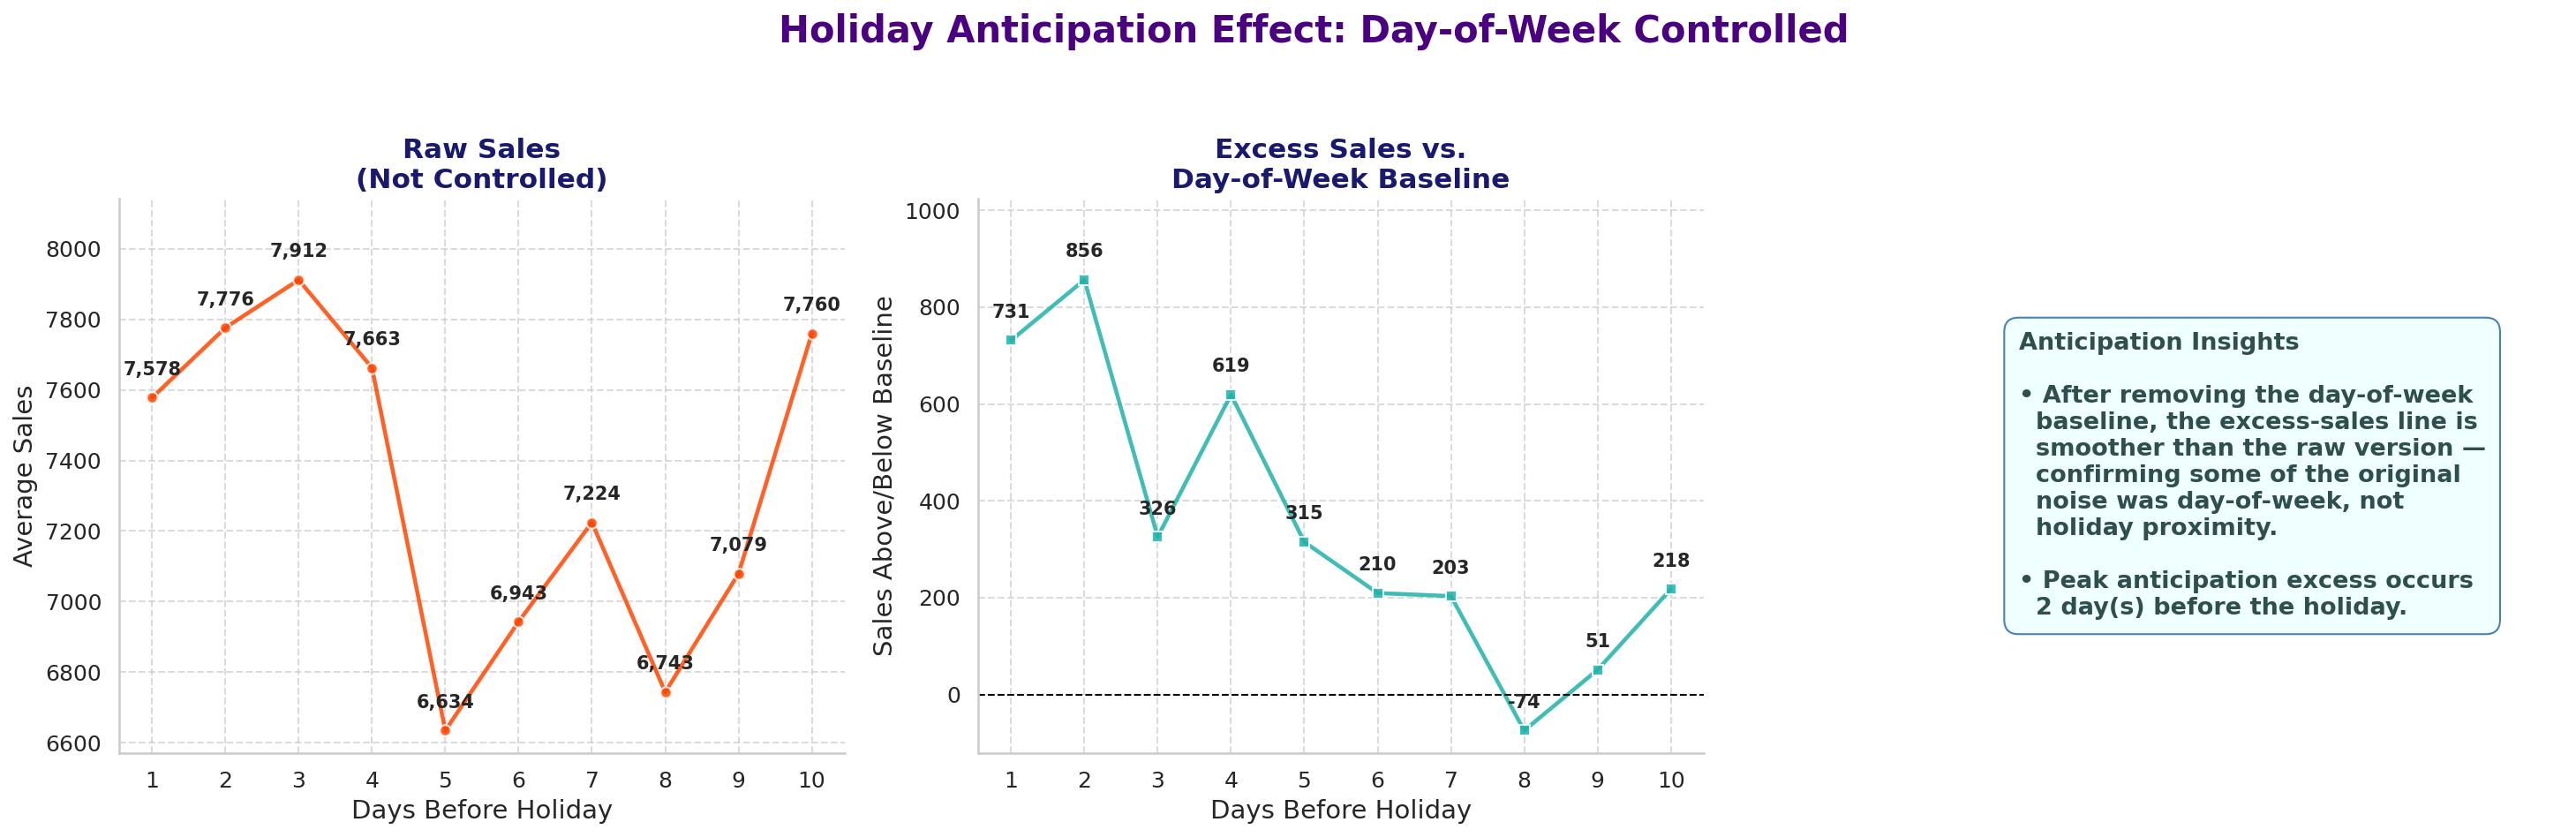

2026-09-08 17:17:08 - 01_salesfc_preprocessing - INFO - Beyond-Ask analysis plotted: Day-of-week-controlled holiday anticipation effect (peak excess at day 2).


In [54]:
subsection_header("Bivariate — Holiday Anticipation Effect (Day-of-Week Controlled)")

open_train = store_train_refined[store_train_refined["Open"] == 1].copy()

dow_baseline = open_train.groupby("DayOfWeek", observed=True)["Sales"].mean()

before_window = open_train[open_train["DaysToNextHoliday"].between(1, 10)].copy()
before_window["DoWBaseline"] = before_window["DayOfWeek"].map(dow_baseline).astype(float)
before_window["ExcessSales"] = before_window["Sales"] - before_window["DoWBaseline"]

anticipation_trend = before_window.groupby("DaysToNextHoliday", observed=True)["ExcessSales"].mean()
raw_trend = before_window.groupby("DaysToNextHoliday", observed=True)["Sales"].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Holiday Anticipation Effect: Day-of-Week Controlled', fontsize=20, color='indigo', fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.35)

axes[0].plot(raw_trend.index, raw_trend.values, marker='o', color='orangered', linewidth=2.2, alpha=0.85, markeredgecolor='white')
axes[0].set_title("Raw Sales\n(Not Controlled)", fontweight='bold', fontsize=15)
axes[0].set_ylabel("Average Sales"); axes[0].set_xlabel("Days Before Holiday")
axes[0].set_xticks(range(1, 11))
axes[0].grid(True, linestyle='--', alpha=0.7)
y_range0 = raw_trend.values.max() - raw_trend.values.min()
for x, y in zip(raw_trend.index, raw_trend.values):
    axes[0].text(x, y + y_range0 * 0.05, f"{y:,.0f}", ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylim(top=raw_trend.values.max() + y_range0 * 0.18)
    
axes[1].plot(anticipation_trend.index, anticipation_trend.values, marker='s', color='lightseagreen', linewidth=2.2, alpha=0.85, markeredgecolor='white')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Excess Sales vs.\nDay-of-Week Baseline", fontweight='bold', fontsize=15)
axes[1].set_ylabel("Sales Above/Below Baseline"); axes[1].set_xlabel("Days Before Holiday")
axes[1].set_xticks(range(1, 11))
axes[1].grid(True, linestyle='--', alpha=0.7)
y_range1 = anticipation_trend.values.max() - anticipation_trend.values.min()
for x, y in zip(anticipation_trend.index, anticipation_trend.values):
    axes[1].text(x, y + y_range1 * 0.05, f"{y:,.0f}", ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylim(top=anticipation_trend.values.max() + y_range1 * 0.18)

axes[2].axis('off')
peak_day = anticipation_trend.idxmax()
insight_text = ("Anticipation Insights\n\n"
                "• After removing the day-of-week\n"
                "  baseline, the excess-sales line is\n"
                "  smoother than the raw version —\n"
                "  confirming some of the original\n"
                "  noise was day-of-week, not\n"
                "  holiday proximity.\n\n"
                f"• Peak anticipation excess occurs\n"
                f"  {peak_day} day(s) before the holiday.")
axes[2].text(0.25, 0.5, insight_text, transform=axes[2].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Beyond_ask_holiday_anticipation.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Beyond-Ask analysis plotted: Day-of-week-controlled holiday anticipation effect (peak excess at day {peak_day}).")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Holiday Anticipation Effect (Day-of-Week Controlled):**

- Controlling for day-of-week meaningfully reduces noise: raw sales vary with a standard deviation of ~441 across the 10-day window, versus ~283 for excess sales — a ~36% reduction, confirming a real share of the original noise was the weekly cycle, not holiday proximity.
- Excess sales peak 2 days before the holiday (856 above baseline), and 1 day before is also elevated (731) — consistent with a genuine short-window anticipation effect concentrated right before the holiday, not spread evenly across the full 10 days.
- The pattern isn't a clean monotonic build-up, though: excess sales generally decline from day 2 through day 8 (which dips slightly negative, -74), but then rise again at days 9-10 (51, 218). This secondary uptick doesn't fit a single "anticipation grows as the holiday nears" story and is more likely a separate effect — possibly overlapping holiday clusters (e.g., a 10-day window catching the tail of a different nearby holiday) rather than anticipation for the same one.
- Practical takeaway: the anticipation effect is real and concentrated in the final 1-2 days, but the wider 10-day window mixes in at least one other pattern that would need its own investigation to separate out cleanly.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Bivariate Analysis — Beyond-Ask: StoreType-Level Sales Patterns

<div style="margin-left: 20px; max-width: 90%">

`StoreType` has come up as a confound in two earlier sections (the Sunday-closure Monday effect, and the Competition Distance U-shape) without ever being examined directly. This section closes that loop: a direct look at Sales, Customers, and Spend-per-Customer across the four store types, using the raw `a`/`b`/`c`/`d` codes since the source data defines no further meaning for them.

</div>

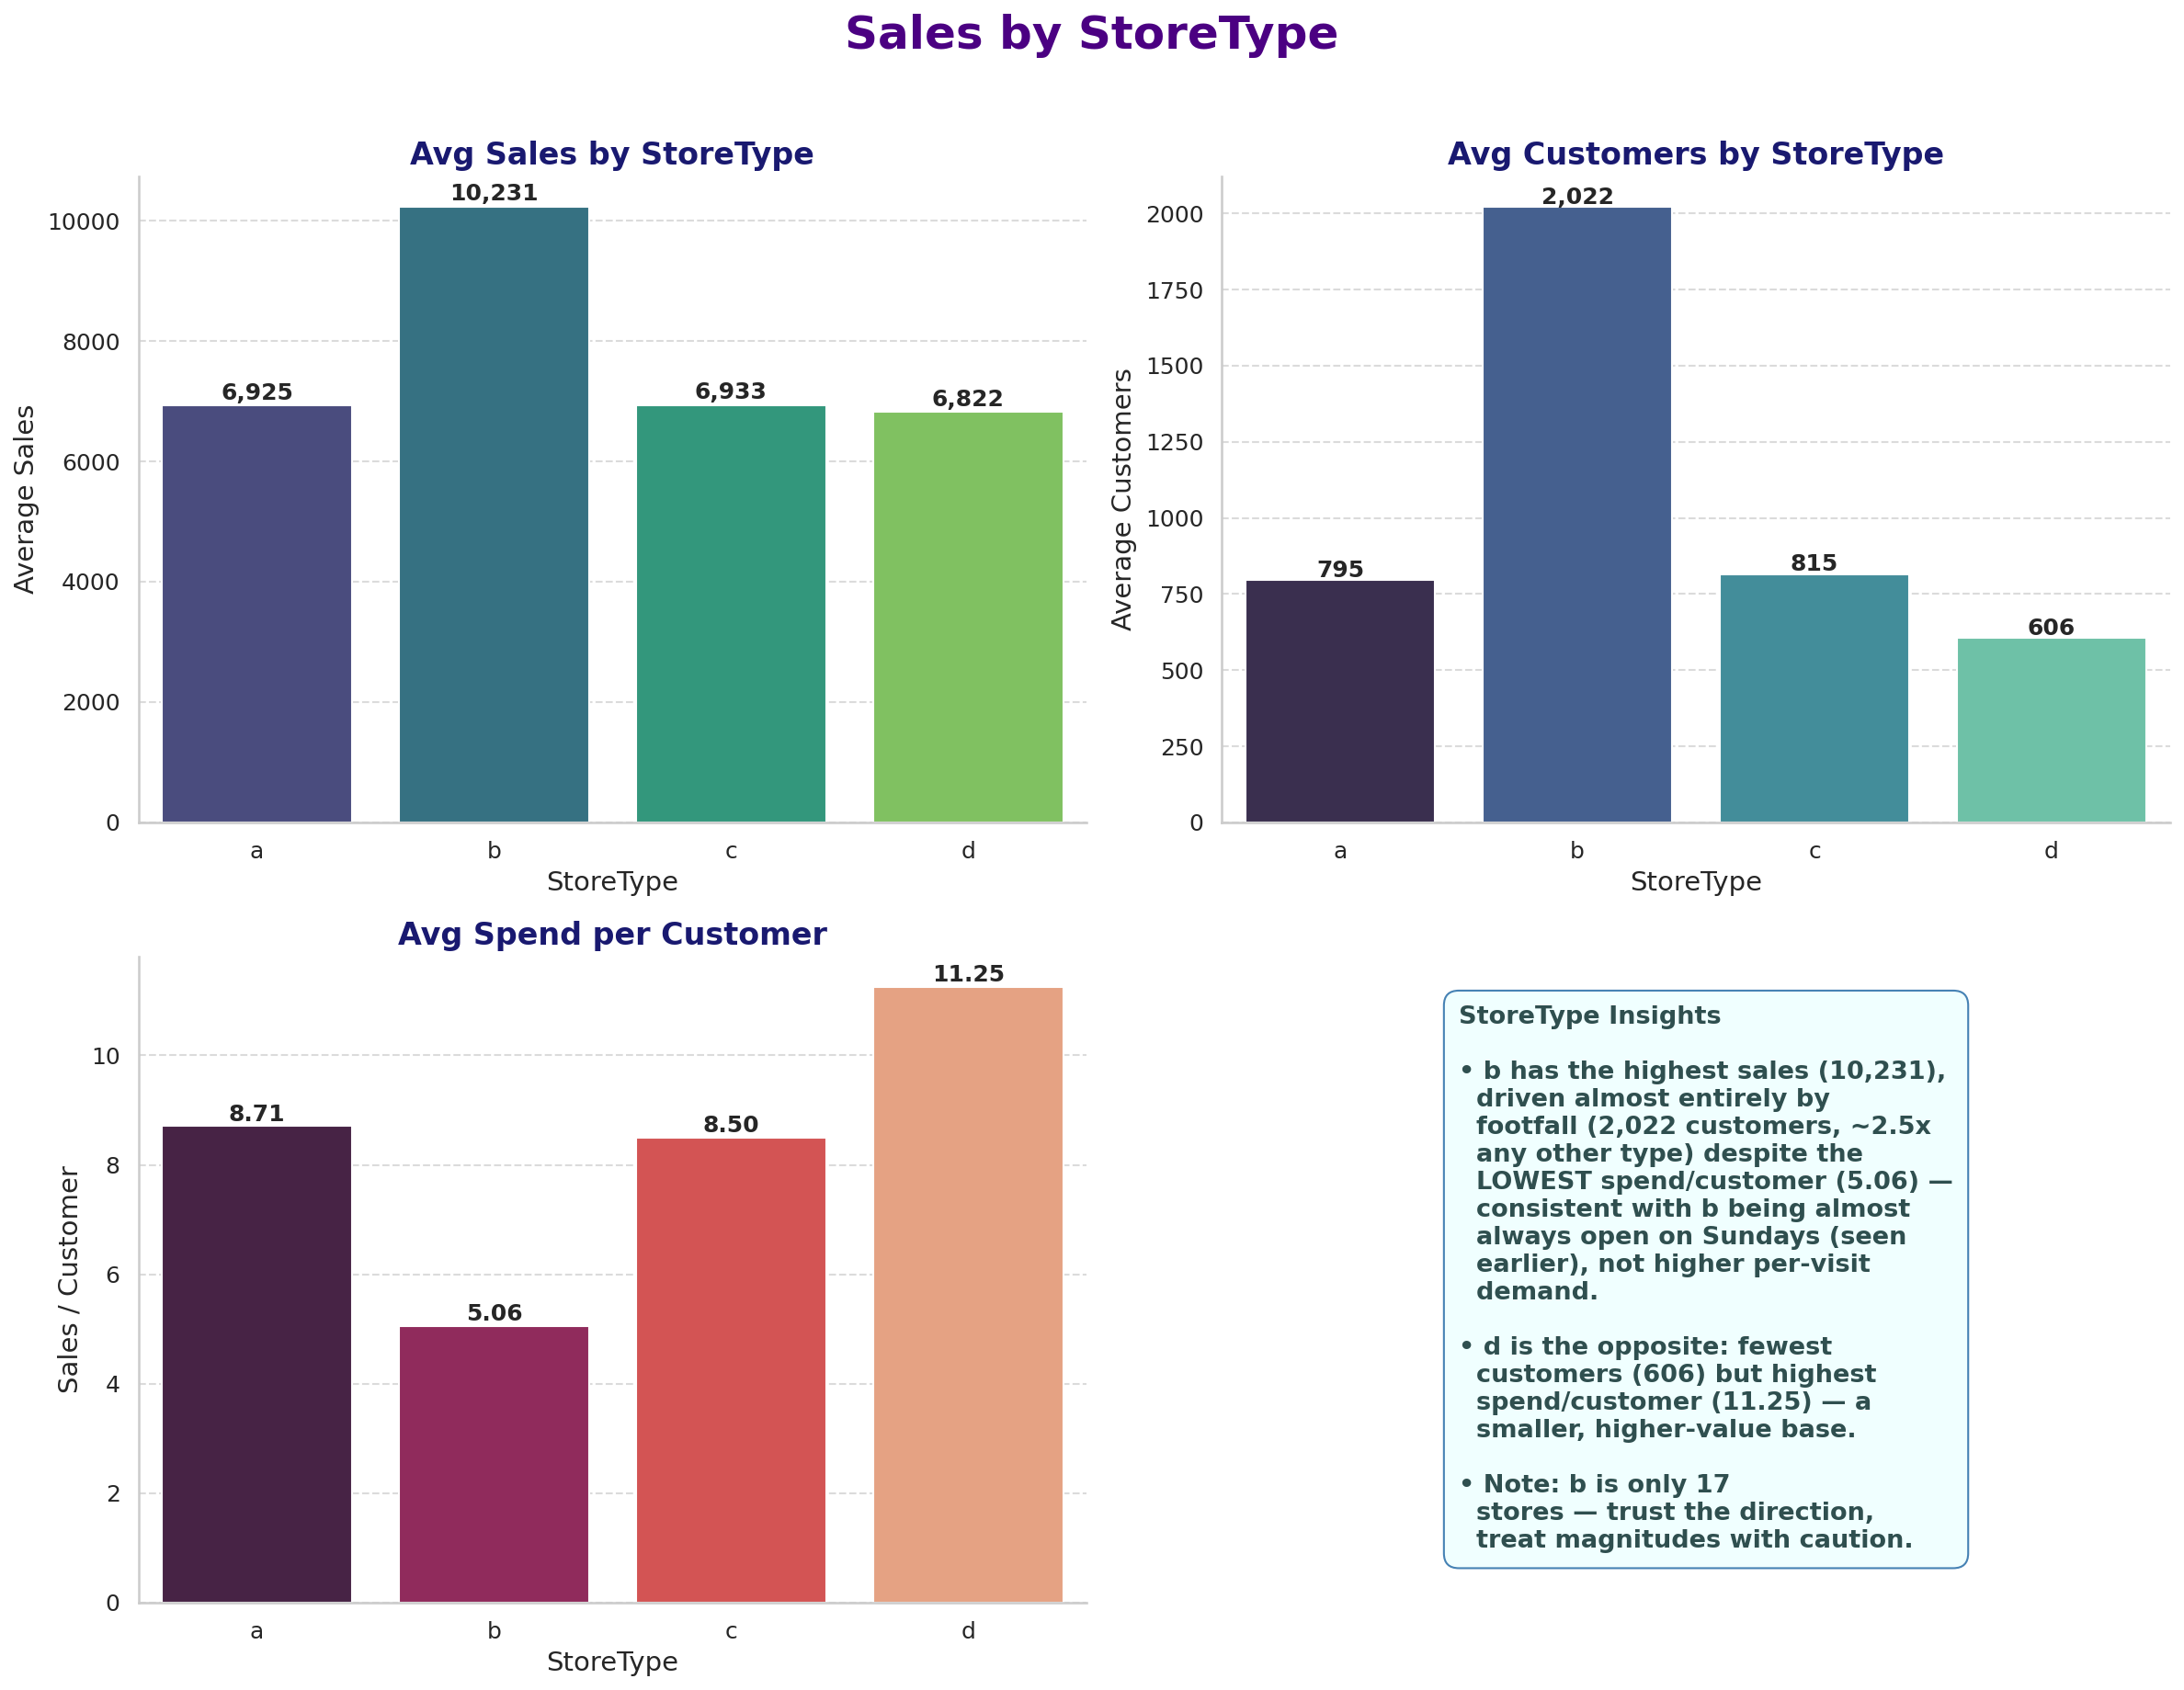

2026-09-08 17:17:10 - 01_salesfc_preprocessing - INFO - Bivariate analysis plotted: Sales/Customers/Spend-per-customer by StoreType.


In [55]:
subsection_header("Bivariate — StoreType-Level Sales Patterns")

open_train = store_train_refined[store_train_refined["Open"] == 1]

storetype_order = ["a", "b", "c", "d"]
storetype_sales = open_train.groupby("StoreType", observed=True)["Sales"].mean().reindex(storetype_order)
storetype_customers = open_train.groupby("StoreType", observed=True)["Customers"].mean().reindex(storetype_order)
storetype_totals = open_train.groupby("StoreType", observed=True)[["Sales", "Customers"]].sum()
storetype_spend_per_customer = (storetype_totals["Sales"] / storetype_totals["Customers"]).reindex(storetype_order)
storetype_counts = open_train.groupby("StoreType", observed=True)["Store"].nunique().reindex(storetype_order)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales by StoreType', fontsize=24, color='indigo', fontweight='bold', y=1.02)
fig.subplots_adjust(wspace=0.3, hspace=0.4)

sns.barplot(x=storetype_sales.index, y=storetype_sales.values, ax=axes[0, 0], palette="viridis", hue=storetype_sales.index, legend=False)
axes[0, 0].set_title("Avg Sales by StoreType", fontweight='bold', fontsize=16)
axes[0, 0].set_ylabel("Average Sales"); axes[0, 0].set_xlabel("StoreType")
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(storetype_sales.values):
    axes[0, 0].text(i, v + 100, f"{v:,.0f}", ha='center', fontweight='bold')

sns.barplot(x=storetype_customers.index, y=storetype_customers.values, ax=axes[0, 1], palette="mako", hue=storetype_customers.index, legend=False)
axes[0, 1].set_title("Avg Customers by StoreType", fontweight='bold', fontsize=16)
axes[0, 1].set_ylabel("Average Customers"); axes[0, 1].set_xlabel("StoreType")
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(storetype_customers.values):
    axes[0, 1].text(i, v + 10, f"{v:,.0f}", ha='center', fontweight='bold')

sns.barplot(x=storetype_spend_per_customer.index, y=storetype_spend_per_customer.values, ax=axes[1, 0], palette="rocket", hue=storetype_spend_per_customer.index, legend=False)
axes[1, 0].set_title("Avg Spend per Customer", fontweight='bold', fontsize=16)
axes[1, 0].set_ylabel("Sales / Customer"); axes[1, 0].set_xlabel("StoreType")
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(storetype_spend_per_customer.values):
    axes[1, 0].text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

axes[1, 1].axis('off')
insight_text = ("StoreType Insights\n\n"
                f"• b has the highest sales (10,231),\n"
                "  driven almost entirely by\n"
                "  footfall (2,022 customers, ~2.5x\n"
                "  any other type) despite the\n"
                "  LOWEST spend/customer (5.06) —\n"
                "  consistent with b being almost\n"
                "  always open on Sundays (seen\n"
                "  earlier), not higher per-visit\n"
                "  demand.\n\n"
                f"• d is the opposite: fewest\n"
                "  customers (606) but highest\n"
                "  spend/customer (11.25) — a\n"
                "  smaller, higher-value base.\n\n"
                f"• Note: b is only {storetype_counts['b']:,}\n"
                "  stores — trust the direction,\n"
                "  treat magnitudes with caution.")
axes[1, 1].text(0.25, 0.5, insight_text, transform=axes[1, 1].transAxes, fontsize=13,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Beyond_ask_storetype_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info("Bivariate analysis plotted: Sales/Customers/Spend-per-customer by StoreType.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — StoreType-Level Sales Patterns:**

- StoreType b has by far the highest average sales (10,231) — but this is a footfall story, not a basket-size story: it also has ~2.5x the average customers of any other type (2,022) while posting the *lowest* spend per customer (5.06). This lines up with an earlier finding: StoreType b was shown to be almost always open on Sundays, so part of its footfall advantage is simply more trading days, not necessarily higher per-visit demand.
- StoreType d is close to the opposite profile: the fewest customers (606) but the highest spend per customer (11.25) by a wide margin. Despite the premium basket size, its total sales (6,822) end up the lowest of the four types — footfall matters more than spend-per-visit at this scale.
- StoreType a and c are nearly identical to each other on every metric (~6,925-6,933 sales, ~795-815 customers, ~8.50-8.71 spend per customer) — the real variation in this dataset is concentrated at the b/d extremes, not spread evenly across all four types.
- Note: StoreType b's numbers rest on only 17 stores. The direction of the pattern (footfall-driven, low margin) is trustworthy, but exact magnitudes deserve the same caution as the earlier small-sample flags (Assortment "Extra", Sunday-open stores).

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Multivariate Analysis — Correlation Heatmap

<div style="margin-left: 20px; max-width: 90%">

A pairwise correlation matrix across the key numeric features, to surface any strong relationships — or near-redundancy — before moving into feature selection for modeling.

</div>

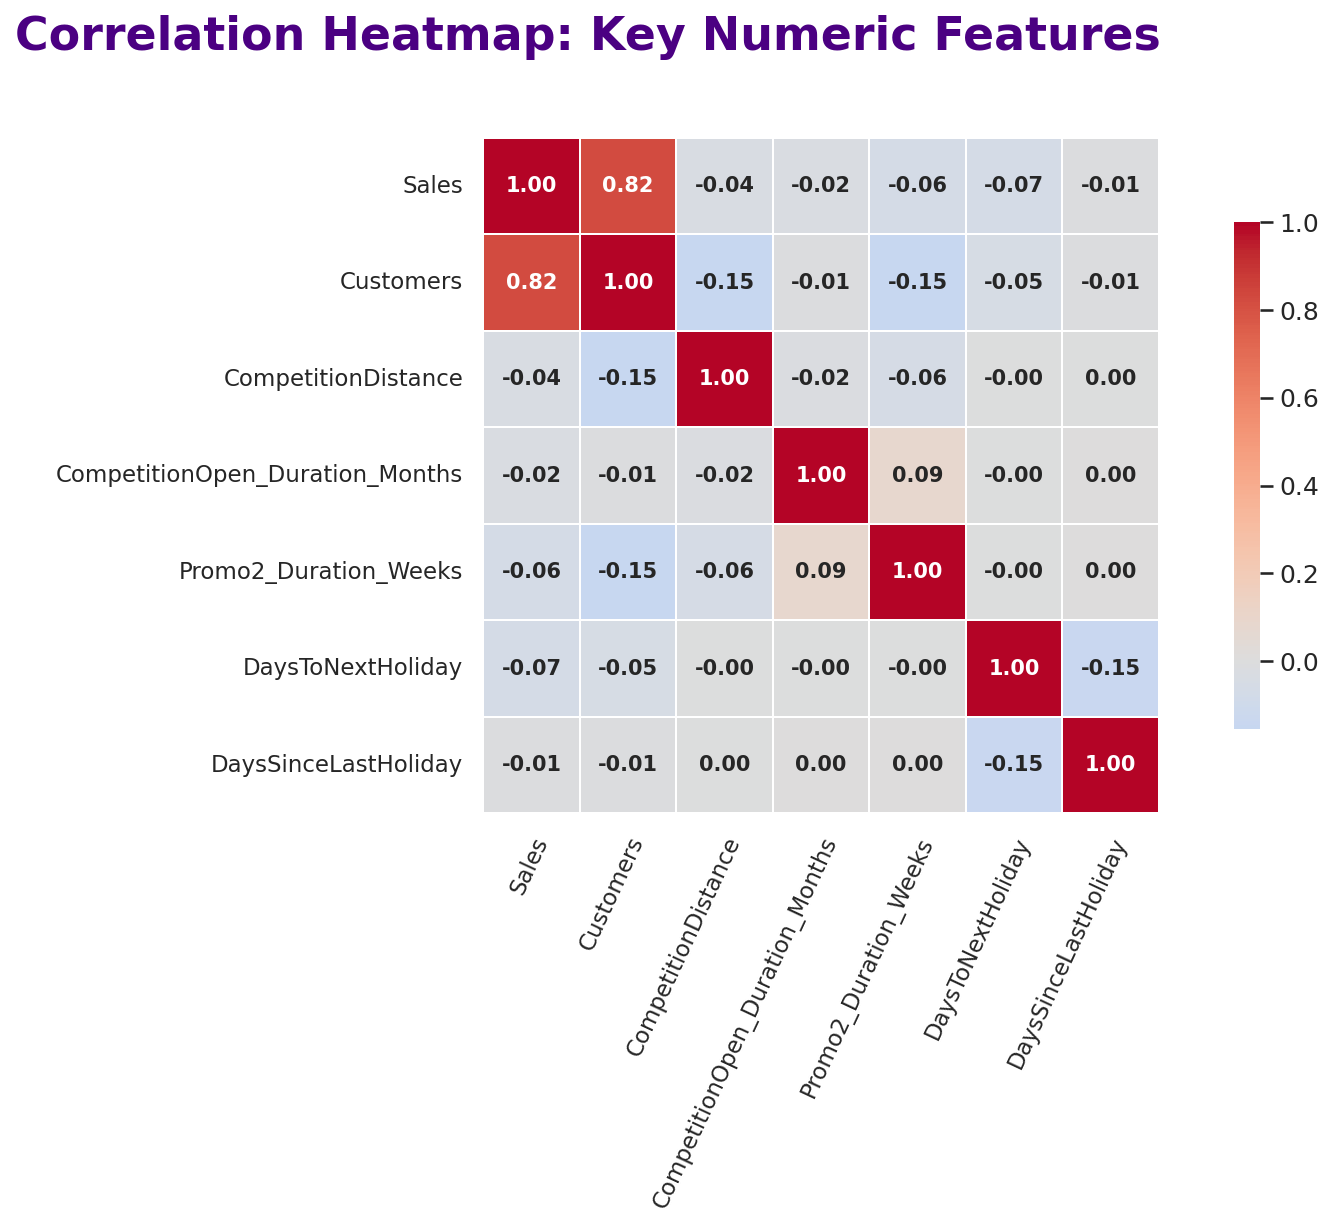

2026-09-08 17:17:11 - 01_salesfc_preprocessing - INFO - Multivariate analysis plotted: correlation heatmap across key numeric features.


In [56]:
subsection_header("Multivariate — Correlation Heatmap")

# Isolate open stores
open_train = store_train_refined[store_train_refined["Open"] == 1]

# Explicitly curate the continuous/business variables (dropping cyclical calendar noise)
key_numeric_cols = ["Sales", "Customers", "CompetitionDistance", "CompetitionOpen_Duration_Months","Promo2_Duration_Weeks", "DaysToNextHoliday", "DaysSinceLastHoliday"]

corr_matrix = open_train[key_numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle("Correlation Heatmap: Key Numeric Features", fontsize=22, color='indigo', fontweight='bold', y=1.02)

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0,
    square=True, 
    linewidths=0.8, 
    cbar_kws={"shrink": 0.75}, 
    ax=ax,annot_kws={"fontsize": 10, "weight": "bold"}
)

# Rotate 45 degrees and right-align so labels don't overlap the matrix
ax.tick_params(axis='x', rotation=65)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
plt.setp(ax.get_yticklabels(), rotation=0)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('Assets/Multivariate_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info("Multivariate analysis plotted: correlation heatmap across key numeric features.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Multivariate: Correlation Heatmap:**

- Sales-Customers remains the only strong correlation in the matrix (0.82), confirming what the earlier Bivariate section already established — no new signal here, but useful as a cross-check.
- Every other pairwise correlation is weak (|r| ≤ 0.15). Customers has the two largest secondary correlations: -0.15 with `CompetitionDistance` and -0.15 with `Promo2_Duration_Weeks`. The `CompetitionDistance` one is weakly consistent with the earlier "closer competition = higher footfall" U-shape finding, though at this magnitude it's a faint signal, not confirmation on its own.
- `DaysToNextHoliday` and `DaysSinceLastHoliday` show a small -0.10 correlation with each other, which makes structural sense (they're complementary measures of the same holiday calendar) rather than an independent finding.
- Important scope note: this heatmap only covers continuous numeric features. Several of the *strongest* patterns found in this notebook — the Promo effect, the StoreType b/d divergence, the Assortment gap — are all driven by categorical variables that a Pearson correlation matrix can't capture. This chart should be read as "no hidden linear relationships among the continuous features," not as "nothing else in the dataset matters."
- Practical read for modeling: low pairwise correlation among the continuous features is good news for multicollinearity in a linear model, but the categorical drivers already found throughout EDA remain the more important signals overall.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Multivariate Analysis — Promo Deployment Effectiveness

<div style="margin-left: 20px; max-width: 90%">

Earlier sections established that Promo has a strong overall sales lift, but that is a network-wide average — it doesn't answer the operational question: *"Which specific store types should promos be deployed in?"*

This section evaluates Promo effectiveness using a dual-axis multivariate approach. By analyzing StoreType, Promo Status, Absolute Sales, and Relative Lift simultaneously, we can identify which store formats yield the highest incremental ROI from marketing spend.

</div>

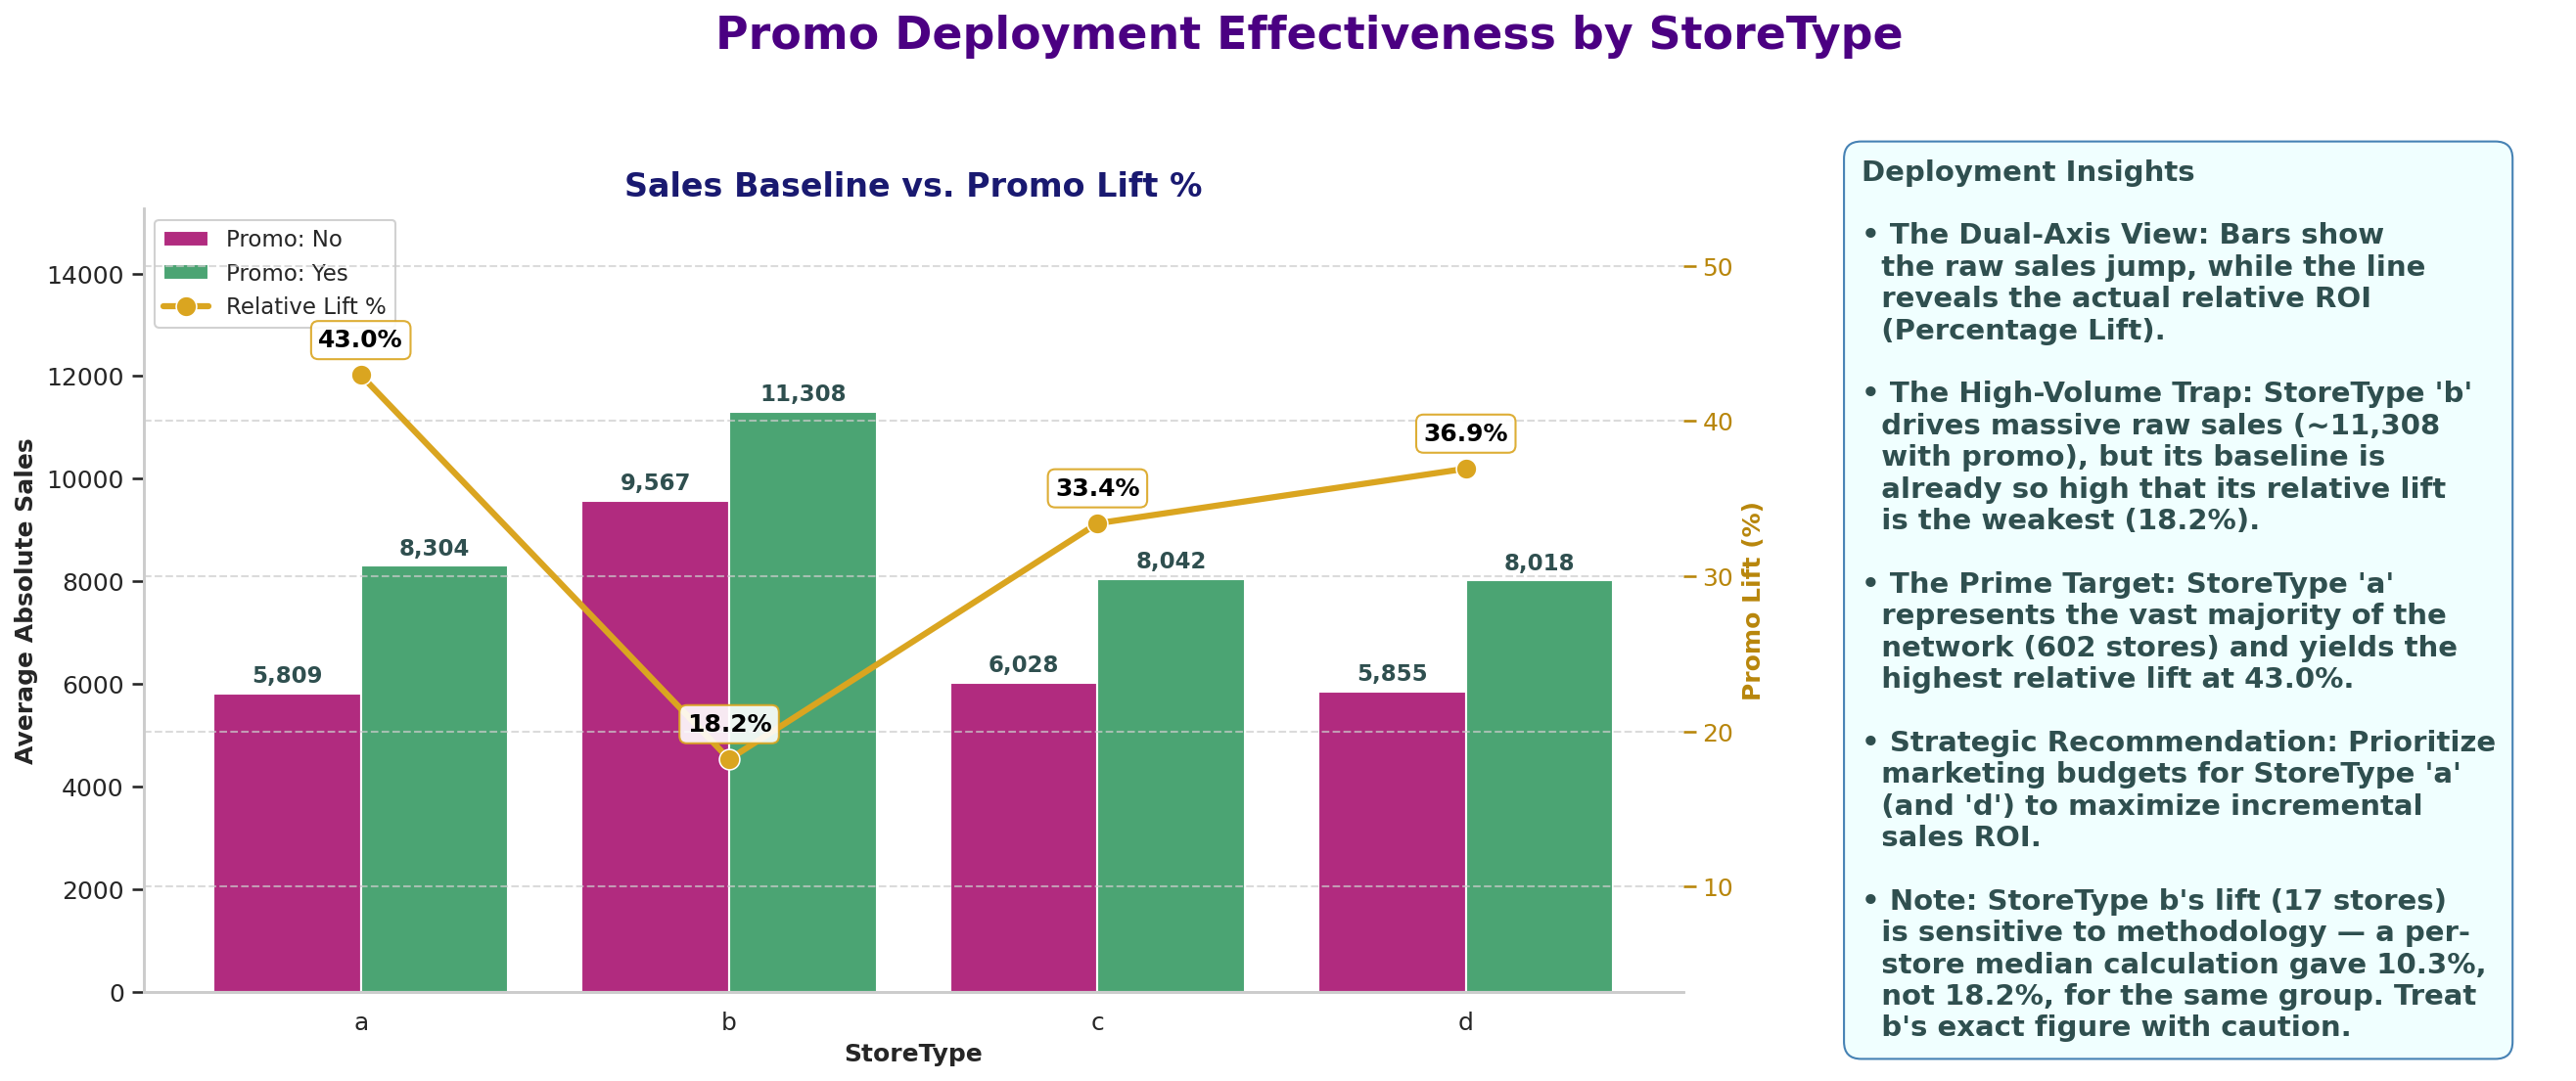

2026-09-08 17:17:12 - 01_salesfc_preprocessing - INFO - Multivariate analysis plotted: Combo chart of absolute sales and Promo lift % by StoreType.


In [57]:
subsection_header("Multivariate — Promo Deployment Effectiveness")

# Isolate open stores to avoid zero-sales days dragging down averages
open_train = store_train_refined[store_train_refined["Open"] == 1]

# Calculate aggregate sales by StoreType and Promo
promo_agg = open_train.groupby(["StoreType", "Promo_Label"], observed=True)["Sales"].mean().unstack()
promo_agg["LiftPct"] = (promo_agg["Yes"] / promo_agg["No"] - 1) * 100
promo_agg = promo_agg.reset_index()

# Get store counts for context
counts_by_type = open_train.groupby("StoreType", observed=True)["Store"].nunique()

# Melt for the bar chart
bar_data = promo_agg.melt(id_vars="StoreType", value_vars=["No", "Yes"], var_name="Promo_Label", value_name="Sales")

# 1x2 Grid with custom width ratios to give the combo chart more space
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Promo Deployment Effectiveness by StoreType', fontsize=22, color='indigo', fontweight='bold', y=1.05)
fig.subplots_adjust(wspace=0.1)

# Primary Axis: Absolute Sales (Bar)
ax1 = axes[0]
sns.barplot(data=bar_data, x="StoreType", y="Sales", hue="Promo_Label", palette=["mediumvioletred", "mediumseagreen"], ax=ax1)
ax1.set_ylabel("Average Absolute Sales", fontweight='bold', fontsize=12)
ax1.set_xlabel("StoreType", fontweight='bold', fontsize=12)
ax1.set_title("Sales Baseline vs. Promo Lift %", fontweight='bold', fontsize=16)
ax1.grid(False, axis='y')

# Add bar labels and increase Y-limit to push bars down away from the line
for container in ax1.containers:
    labels = [f'{v.get_height():,.0f}' for v in container]
    ax1.bar_label(container, labels=labels, padding=3, color='darkslategray', fontsize=11, fontweight='bold')
ax1.set_ylim(0, bar_data["Sales"].max() * 1.35) 

# Secondary Axis: Relative Lift % (Line)
ax2 = ax1.twinx()
sns.lineplot(data=promo_agg, x="StoreType", y="LiftPct", marker='o', markersize=10, color='goldenrod', linewidth=3, ax=ax2, label="Promo Lift %")
ax2.set_ylabel("Promo Lift (%)", fontweight='bold', color='darkgoldenrod', fontsize=12)
ax2.tick_params(axis='y', colors='darkgoldenrod')

# Shift the line plot up to avoid the bars
ax2.set_ylim(promo_agg["LiftPct"].min() - 15, promo_agg["LiftPct"].max() * 1.25)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add line labels with a white background box so they don't blend into the green bars
for i, val in enumerate(promo_agg["LiftPct"]):
    ax2.text(i, val + 1.5, f"{val:.1f}%", color='black', fontweight='bold', ha='center', va='bottom', fontsize=12, 
             bbox=dict(facecolor='white', edgecolor='goldenrod', alpha=0.9, boxstyle='round,pad=0.3'))

# Legend handling (combining both axes)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, ["Promo: No", "Promo: Yes", "Relative Lift %"], loc='upper left', framealpha=0.9, fontsize=11)
ax2.get_legend().remove()

# Plot 2: Dynamic Insight Box
axes[1].axis('off')

# Dynamically extract values for the insight box
best_type = promo_agg.loc[promo_agg["LiftPct"].idxmax(), "StoreType"]
best_lift = promo_agg["LiftPct"].max()
lift_b = promo_agg.loc[promo_agg["StoreType"] == 'b', "LiftPct"].values[0]
sales_yes_b = promo_agg.loc[promo_agg["StoreType"] == 'b', "Yes"].values[0]

insight_text = ("Deployment Insights\n\n"
                "• The Dual-Axis View: Bars show\n"
                "  the raw sales jump, while the line\n"
                "  reveals the actual relative ROI\n"
                "  (Percentage Lift).\n\n"
                "• The High-Volume Trap: StoreType 'b'\n"
                f"  drives massive raw sales (~{sales_yes_b:,.0f}\n"
                "  with promo), but its baseline is\n"
                "  already so high that its relative lift\n"
                f"  is the weakest ({lift_b:.1f}%).\n\n"
                f"• The Prime Target: StoreType '{best_type}' \n"
                "  represents the vast majority of the\n"
                f"  network ({counts_by_type[best_type]:,} stores) and yields the\n"
                f"  highest relative lift at {best_lift:.1f}%.\n\n"
                "• Strategic Recommendation: Prioritize\n"
                f"  marketing budgets for StoreType '{best_type}'\n"
                "  (and 'd') to maximize incremental\n"
                "  sales ROI.\n\n"
                "• Note: StoreType b's lift (17 stores)\n"
                "  is sensitive to methodology — a per-\n"
                "  store median calculation gave 10.3%,\n"
                "  not 18.2%, for the same group. Treat\n"
                "  b's exact figure with caution.")

axes[1].text(0.09, 0.5, insight_text, transform=axes[1].transAxes, fontsize=14,
             va='center', ha='left', color='darkslategray', weight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='azure', edgecolor='steelblue'))

plt.tight_layout()
plt.savefig('Assets/Multivariate_promo_deployment_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info(f"Multivariate analysis plotted: Combo chart of absolute sales and Promo lift % by StoreType.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Promo Deployment Effectiveness:**

- **The Baseline Context:** Analyzing relative lift without accounting for baseline sales is heavily misleading. StoreType `b` generates nearly 11,308 in average daily sales when a promo is active. However, its baseline sales on non-promo days are already massive (over 9,500). This results in the lowest relative lift by this measure (18.2%). These locations perform exceptionally well on their own and are slightly less sensitive to marketing stimuli.
- **The ROI Maximizer:** StoreType `a` generates lower raw sales (jumping from roughly 5,809 to 8,304), but this represents a massive relative lift of 43.0%. Because StoreType `a` encompasses the largest segment of the network (602 stores), it offers the highest sensitivity and scalability for promotional campaigns.
- **Methodology caution for StoreType b:** This aggregate group-level lift (18.2%) diverges meaningfully from the median of individual stores' own lift ratios computed earlier (10.3%) for the same StoreType. With only 17 stores in this group, a small number of high-volume stores can pull the aggregate ratio well away from what a typical store in the group actually experiences. StoreType b's *direction* (lowest relative lift) is consistent across both methods, but its *exact magnitude* shouldn't be treated as precisely as a/c/d's figures, which rest on much larger samples (602, 148, 348 stores).
- **Practical read:** If the business objective is to maximize the incremental Return on Investment (ROI) of marketing spend, promotions should be prioritized in StoreType `a` (and `d`, a healthy 36.9% lift across 348 stores) — both figures rest on solid sample sizes. StoreType `b` likely drives high revenue with less promo sensitivity, but the exact size of that gap is less certain than for the other three types.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 07. Final Verification, Summary & Export

<div style="margin-left: 20px; max-width: 90%">

With the Exploratory Data Analysis complete, this final section serves as the wrap-up for Notebook 1. Before handing the data over to the predictive modeling pipelines, we will:
1. **Clean** the datasets by dropping the temporary text labels used for plotting.
2. **Verify** the final structural integrity of the datasets (`.info()`, `.shape`, `.head()`).
3. **Summarize** the core business insights discovered during EDA.
4. **Export** to CSV, ensuring a strict numeric/categorical matrix is saved.

</div>

### 📌 Dropping Temporary EDA-Only Columns

<div style="margin-left: 20px; max-width: 90%">

Several columns exist only to make charts and groupbys readable during EDA — the `_Label` columns mapped for readability, plus two flags added mid-analysis (`PrevDayOpen`, `AlwaysWeekdayOpen`) that were discovery tools, not planned model features. Both `store_train_refined` and `store_test_refined` are cleaned here before the EDA & Feature Engineering Summary and final export.

</div>

In [58]:
section_header("Final Verification, Summary and Export")
subsection_header("Dropping Temporary EDA-Only Columns")

eda_only_columns = [
    "Assortment_Label", "StateHoliday_Label", "Open_Label",
    "Promo_Label", "Promo2_Label", "SchoolHoliday_Label",
    "PrevDayOpen", "AlwaysWeekdayOpen"
]

before_cols_train = store_train_refined.shape[1]
before_cols_test = store_test_refined.shape[1]

store_train_refined = store_train_refined.drop(columns=eda_only_columns, errors="ignore")
store_test_refined = store_test_refined.drop(columns=eda_only_columns, errors="ignore")

success_box(f"Dropped temporary EDA-only columns — store_train_refined: {before_cols_train} → {store_train_refined.shape[1]} columns; "
            f"store_test_refined: {before_cols_test} → {store_test_refined.shape[1]} columns.")

logger.info(f"Dropped EDA-only columns from store_train_refined ({before_cols_train}->{store_train_refined.shape[1]}) and store_test_refined ({before_cols_test}->{store_test_refined.shape[1]}).")

2026-09-08 17:17:12 - 01_salesfc_preprocessing - INFO - Dropped EDA-only columns from store_train_refined (34->26) and store_test_refined (31->25).


In [59]:
subsection_header("Technical Verification: Train Data — Final Shapes and Info")

print("="*50)
print("FINAL TRAIN SET INFO")
print("="*50)
store_train_refined.info()

info_box(f"Final Shapes confirmed — Train: <b>{store_train_refined.shape[0]:,}</b> rows, <b>{store_train_refined.shape[1]}</b> columns.")

centered_table(store_train_refined.head())

logger.info(f"Final Technical Verification complete. Train shape: {store_train_refined.shape}.")

FINAL TRAIN SET INFO
<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 1016095 to 1114
Data columns (total 26 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   Store                            1017209 non-null  category      
 1   DayOfWeek                        1017209 non-null  category      
 2   Date                             1017209 non-null  datetime64[ns]
 3   Sales                            1017209 non-null  int64         
 4   Customers                        1017209 non-null  int64         
 5   Open                             1017209 non-null  category      
 6   Promo                            1017209 non-null  category      
 7   StateHoliday                     1017209 non-null  category      
 8   SchoolHoliday                    1017209 non-null  category      
 9   StoreType                        1017209 non-null  category      
 10  Assortment 

Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Promo2_Duration_Weeks,CompetitionOpen_Duration_Months,CompetitionOpenDate_Known,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,MonthPosition,DaysToNextHoliday,DaysSinceLastHoliday,IsPromo2Month
1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.00,0,0,52,1,2013,1,1,1,1,0,Start,0,0,0
1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.00,0,0,52,1,2013,1,2,1,1,0,Start,4,1,0
1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.00,0,0,52,1,2013,1,3,1,1,0,Start,3,2,0
1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.00,0,0,52,1,2013,1,4,1,1,0,Start,2,3,0
1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.00,0,0,52,1,2013,1,5,1,1,1,Start,1,4,0


2026-09-08 17:17:12 - 01_salesfc_preprocessing - INFO - Final Technical Verification complete. Train shape: (1017209, 26).


In [60]:
subsection_header("Technical Verification : Test Data— Final Shapes and Info")
print("\n" + "="*50)
print("FINAL TEST SET INFO")
print("="*50)
store_test_refined.info()

info_box(f"Final Shapes confirmed — Test: <b>{store_test_refined.shape[0]:,}</b> rows, <b>{store_test_refined.shape[1]}</b> columns.")

centered_table(store_test_refined.head())

logger.info(f"Final Technical Verification complete. Test shape: {store_test_refined.shape}")


FINAL TEST SET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Id                               41088 non-null  int64         
 1   Store                            41088 non-null  category      
 2   DayOfWeek                        41088 non-null  category      
 3   Date                             41088 non-null  datetime64[ns]
 4   Open                             41088 non-null  category      
 5   Promo                            41088 non-null  category      
 6   StateHoliday                     41088 non-null  category      
 7   SchoolHoliday                    41088 non-null  category      
 8   StoreType                        41088 non-null  category      
 9   Assortment                       41088 non-null  category      
 10  CompetitionDistance              4108

Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Promo2_Duration_Weeks,CompetitionOpen_Duration_Months,CompetitionOpenDate_Known,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,MonthPosition,DaysToNextHoliday,DaysSinceLastHoliday,IsPromo2Month
1,1,4,2015-09-17,1.00,1,0,0,c,a,1270.00,0,0,84,1,2015,9,17,38,3,0,Mid,14.00,33,0
2,3,4,2015-09-17,1.00,1,0,0,a,a,14130.00,1,232,106,1,2015,9,17,38,3,0,Mid,14.00,33,0
3,7,4,2015-09-17,1.00,1,0,0,a,c,24000.00,0,0,30,1,2015,9,17,38,3,0,Mid,14.00,33,0
4,8,4,2015-09-17,1.00,1,0,0,a,a,7520.00,0,0,12,1,2015,9,17,38,3,0,Mid,14.00,33,0
5,9,4,2015-09-17,1.00,1,0,0,a,c,2030.00,0,0,182,1,2015,9,17,38,3,0,Mid,14.00,33,0


2026-09-08 17:17:12 - 01_salesfc_preprocessing - INFO - Final Technical Verification complete. Test shape: (41088, 25)


### 📌 Executive Summary: EDA & Feature Engineering

<div style="margin-left: 20px; max-width: 90%">

The preprocessing and exploratory phases have transformed the raw Rossmann data into a rich, leak-free asset. Key outcomes include:

* **Temporal Engineering:** Continuous duration features (`Promo2_Duration_Weeks`, `CompetitionOpen_Duration_Months`) and holiday proximity metrics successfully replaced non-linear calendar dates, avoiding multicollinearity.
* **Sales Drivers:** Footfall (Customers) is the overwhelming primary driver of daily revenue (Pearson r = 0.82). 
* **Promo ROI:** Promotions actively increase the average spend per customer. Deploying promos in StoreType `a` and `d` yields the highest relative sales lift (~37-43%), whereas StoreType `b` operates as a high-volume outlier less reliant on marketing.
* **Geographic Reality:** Distance to the nearest competitor shows a U-shaped relationship with sales, but a StoreType crosstab revealed this is substantially a StoreType composition effect (StoreType `a` dominates the highest-selling distance brackets) rather than a clean distance effect — `CompetitionDistance` should not be trusted as a standalone predictor without StoreType controls.

</div>

In [61]:
subsection_header("Export Datasets")

# Define exact export paths matching the project structure
train_export_path = 'Assets/store_train_data.csv'
test_export_path = 'Assets/store_test_data.csv'

# Export to CSV (unencoded, unscaled per project requirements)
store_train_refined.to_csv(train_export_path, index=False)
store_test_refined.to_csv(test_export_path, index=False)

success_box(f"Datasets successfully written to disk:<br>"
            f"📁 <b>{train_export_path}</b><br>"
            f"📁 <b>{test_export_path}</b>")

logger.info(f"Export complete. Train: {train_export_path}, Test: {test_export_path}")

2026-09-08 17:17:21 - 01_salesfc_preprocessing - INFO - Export complete. Train: Assets/store_train_data.csv, Test: Assets/store_test_data.csv


In [62]:
display(HTML(f"""
<div style="text-align:center;margin-top:40px;margin-bottom:30px;">
    <h3 style="color:#2E8B57;font-size:1.8em;"><b>✅ Checkpoint: End of Notebook 1 — Preprocessing & EDA</b></h3>
    <p style="font-style:italic;font-size:1.05em;opacity:0.85;max-width:75%;margin:15px auto;line-height:1.6;">
        Pristine, feature-engineered, leak-free datasets are exported and ready. 🚀<br>
        <b>Next: Notebook 2 — ML Modeling.</b> We'll load these CSVs, build a formal Scikit-Learn
        encoding/scaling pipeline, train baseline and tuned models, and evaluate performance.
    </p>
    <hr style="width:45%;">
</div>"""))